## Business Understanding & Data Loading

In [1]:
# ============================================================
# PART 1 — BUSINESS UNDERSTANDING & DATA LOADING
# ============================================================

# Import required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("cs-training.csv")

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [3]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 150000
Number of columns: 12


In [4]:
# Display column names
df.info()
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [5]:
print(df.shape)
print(df.columns.tolist())
df.head()
df.info()

(150000, 12)
['Unnamed: 0', 'SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome      

In [6]:
# ============================================================
# PART 2 — DATA UNDERSTANDING & TARGET ANALYSIS
# ============================================================

# Check unique values of the target variable

print("Unique values in target:")
print(df["SeriousDlqin2yrs"].unique())

Unique values in target:
[1 0]


In [7]:
# Count observations by target

target_count = df["SeriousDlqin2yrs"].value_counts()

print("Target counts:")
print(target_count)

Target counts:
SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64


In [8]:
# Calculate target distribution in percentage
target_pct = (
    df["SeriousDlqin2yrs"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

print("Target distribution (%):")
print(target_pct)

Target distribution (%):
SeriousDlqin2yrs
0    93.316
1     6.684
Name: proportion, dtype: float64


In [9]:
# Check for duplicate rows
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


## Development / Validation Sample Split

In [10]:
# ============================================================
# PART 3 — DEVELOPMENT / VALIDATION SAMPLE SPLIT
# ============================================================

# Separate target variable

y = df["SeriousDlqin2yrs"]

# Remove target and identifier from predictor dataset

X = df.drop(
    columns=["SeriousDlqin2yrs", "Unnamed: 0"]
)

print("Predictor shape:", X.shape)
print("Target shape:", y.shape)

Predictor shape: (150000, 10)
Target shape: (150000,)


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Validation shape:", X_valid.shape)

print("Training target shape:", y_train.shape)
print("Validation target shape:", y_valid.shape)

Training shape: (105000, 10)
Validation shape: (45000, 10)
Training target shape: (105000,)
Validation target shape: (45000,)


In [12]:
# Target distribution in development sample
train_target_pct = (
    y_train
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

print("Development sample target distribution:")
print(train_target_pct)

Development sample target distribution:
SeriousDlqin2yrs
0    93.31619
1     6.68381
Name: proportion, dtype: float64


In [13]:
# Target distribution in validation sample
valid_target_pct = (
    y_valid
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

print("\nValidation sample target distribution:")
print(valid_target_pct)


Validation sample target distribution:
SeriousDlqin2yrs
0    93.315556
1     6.684444
Name: proportion, dtype: float64


In [14]:
# Compare target distribution across datasets
comparison = pd.DataFrame({
    "Overall": y.value_counts(normalize=True).sort_index() * 100,
    "Development": y_train.value_counts(normalize=True).sort_index() * 100,
    "Validation": y_valid.value_counts(normalize=True).sort_index() * 100
})

comparison.index = ["Good (0)", "Bad (1)"]

display(comparison)

,Overall,Development,Validation
Good (0),93.316,93.31619,93.315556
Bad (1),6.684,6.68381,6.684444


## Data Quality Assessment

In [15]:
# Missing-value analysis

missing_summary = pd.DataFrame({
    "Missing_Count": X_train.isnull().sum(),
    "Missing_Pct": X_train.isnull().mean() * 100
})

missing_summary = missing_summary.sort_values(
    "Missing_Pct",
    ascending=False
)

display(missing_summary)

,Missing_Count,Missing_Pct
MonthlyIncome,20723,19.736190
NumberOfDependents,2721,2.591429
RevolvingUtilizationOfUnsecuredLines,0,0.000000
age,0,0.000000
NumberOfTime30-59DaysPastDueNotWorse,0,0.000000
DebtRatio,0,0.000000
NumberOfOpenCreditLinesAndLoans,0,0.000000
NumberOfTimes90DaysLate,0,0.000000
NumberRealEstateLoansOrLines,0,0.000000
NumberOfTime60-89DaysPastDueNotWorse,0,0.000000


In [16]:
def missing_bad_rate(data, target, columns):
    
    results = []

    for col in columns:
        
        missing_mask = data[col].isna()
        
        missing_count = missing_mask.sum()
        non_missing_count = (~missing_mask).sum()
        
        if missing_count > 0:
            bad_rate_missing = target[missing_mask].mean()
        else:
            bad_rate_missing = np.nan
            
        if non_missing_count > 0:
            bad_rate_non_missing = target[~missing_mask].mean()
        else:
            bad_rate_non_missing = np.nan
        
        results.append({
            "Variable": col,
            "Missing_Count": missing_count,
            "Missing_Pct": missing_count / len(data) * 100,
            "Bad_Rate_Missing": bad_rate_missing,
            "Bad_Rate_NonMissing": bad_rate_non_missing
        })
    
    return pd.DataFrame(results)

In [17]:
missing_bad_rate_df = missing_bad_rate(
    X_train,
    y_train,
    X_train.columns
)

display(
    missing_bad_rate_df
    .sort_values("Missing_Pct", ascending=False)
)

,Variable,Missing_Count,Missing_Pct,Bad_Rate_Missing,Bad_Rate_NonMissing
4,MonthlyIncome,20723,19.736190,0.054818,0.069794
9,NumberOfDependents,2721,2.591429,0.041529,0.067511
0,RevolvingUtilizationOfUnsecuredLines,0,0.000000,NaN,0.066838
1,age,0,0.000000,NaN,0.066838
2,NumberOfTime30-59DaysPastDueNotWorse,0,0.000000,NaN,0.066838
3,DebtRatio,0,0.000000,NaN,0.066838
5,NumberOfOpenCreditLinesAndLoans,0,0.000000,NaN,0.066838
6,NumberOfTimes90DaysLate,0,0.000000,NaN,0.066838
7,NumberRealEstateLoansOrLines,0,0.000000,NaN,0.066838
8,NumberOfTime60-89DaysPastDueNotWorse,0,0.000000,NaN,0.066838


In [18]:
# Unique-values

unique_summary = pd.DataFrame({
    "Unique_Count": X_train.nunique(dropna=True),
    "Unique_Count_Including_Missing": X_train.nunique(dropna=False)
})

unique_summary = unique_summary.sort_values(
    "Unique_Count"
)

display(unique_summary)

,Unique_Count,Unique_Count_Including_Missing
NumberOfTime60-89DaysPastDueNotWorse,11,11
NumberOfDependents,12,13
NumberOfTime30-59DaysPastDueNotWorse,16,16
NumberOfTimes90DaysLate,19,19
NumberRealEstateLoansOrLines,27,27
NumberOfOpenCreditLinesAndLoans,57,57
age,83,83
MonthlyIncome,12078,12079
DebtRatio,82441,82441
RevolvingUtilizationOfUnsecuredLines,88511,88511


In [19]:
low_cardinality_cols = (
    unique_summary[
        unique_summary["Unique_Count"] <= 20
    ]
    .index
    .tolist()
)

print("Low-cardinality variables:")
print(low_cardinality_cols)

Low-cardinality variables:
['NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents', 'NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfTimes90DaysLate']


In [20]:
for col in low_cardinality_cols:
    
    print("\n" + "=" * 60)
    print(col)
    print("=" * 60)
    
    print(
        X_train[col]
        .value_counts(dropna=False)
        .sort_index()
    )


NumberOfTime60-89DaysPastDueNotWorse
NumberOfTime60-89DaysPastDueNotWorse
0     99662
1      4049
2       767
3       222
4        74
5        26
6        11
7         6
11        1
96        1
98      181
Name: count, dtype: int64

NumberOfDependents
NumberOfDependents
0.0     60782
1.0     18498
2.0     13644
3.0      6647
4.0      2015
5.0       524
6.0       114
7.0        32
8.0        15
9.0         3
10.0        4
13.0        1
NaN      2721
Name: count, dtype: int64

NumberOfTime30-59DaysPastDueNotWorse
NumberOfTime30-59DaysPastDueNotWorse
0     88178
1     11252
2      3225
3      1253
4       503
5       235
6        98
7        37
8        21
9         9
10        4
11        1
12        1
13        1
96        1
98      181
Name: count, dtype: int64

NumberOfTimes90DaysLate
NumberOfTimes90DaysLate
0     99103
1      3723
2      1094
3       472
4       218
5        87
6        55
7        24
8        15
9        11
10        6
11        2
12        1
13        3
14        

In [23]:
delinquency_cols = [
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate",
    "NumberOfTime60-89DaysPastDueNotWorse"
]

for col in delinquency_cols:
    
    print("\n" + "=" * 70)
    print(col)
    print("=" * 70)
    
    print(
        X_train[col]
        .value_counts(dropna=False)
        .sort_index()
    )


NumberOfTime30-59DaysPastDueNotWorse
NumberOfTime30-59DaysPastDueNotWorse
0     88178
1     11252
2      3225
3      1253
4       503
5       235
6        98
7        37
8        21
9         9
10        4
11        1
12        1
13        1
96        1
98      181
Name: count, dtype: int64

NumberOfTimes90DaysLate
NumberOfTimes90DaysLate
0     99103
1      3723
2      1094
3       472
4       218
5        87
6        55
7        24
8        15
9        11
10        6
11        2
12        1
13        3
14        1
15        2
17        1
96        1
98      181
Name: count, dtype: int64

NumberOfTime60-89DaysPastDueNotWorse
NumberOfTime60-89DaysPastDueNotWorse
0     99662
1      4049
2       767
3       222
4        74
5        26
6        11
7         6
11        1
96        1
98      181
Name: count, dtype: int64


In [24]:
# 4.5 Overall data-quality summary
data_quality_summary = pd.DataFrame({
    "Data_Type": X_train.dtypes,
    "Unique_Count": X_train.nunique(dropna=True),
    "Missing_Count": X_train.isnull().sum(),
    "Missing_Pct": X_train.isnull().mean() * 100,
    "Minimum": X_train.min(),
    "Maximum": X_train.max(),
    "Mean": X_train.mean(),
    "Median": X_train.median()
})

display(data_quality_summary)

,Data_Type,Unique_Count,Missing_Count,Missing_Pct,Minimum,Maximum,Mean,Median
RevolvingUtilizationOfUnsecuredLines,float64,88511,0,0.000000,0.0,50708.0,6.482739,0.153553
age,int64,83,0,0.000000,21.0,109.0,52.277657,52.000000
NumberOfTime30-59DaysPastDueNotWorse,int64,16,0,0.000000,0.0,98.0,0.415752,0.000000
DebtRatio,float64,82441,0,0.000000,0.0,329664.0,355.053748,0.367554
MonthlyIncome,float64,12078,20723,19.736190,0.0,1794060.0,6613.049385,5382.000000
NumberOfOpenCreditLinesAndLoans,int64,57,0,0.000000,0.0,58.0,8.466371,8.000000
NumberOfTimes90DaysLate,int64,19,0,0.000000,0.0,98.0,0.260752,0.000000
NumberRealEstateLoansOrLines,int64,27,0,0.000000,0.0,54.0,1.019343,1.000000
NumberOfTime60-89DaysPastDueNotWorse,int64,11,0,0.000000,0.0,98.0,0.234552,0.000000
NumberOfDependents,float64,12,2721,2.591429,0.0,13.0,0.757878,0.000000


## Missing Value and Outlinear Treatment

In [25]:
variable_summary = pd.DataFrame({
    "Variable": X_train.columns,
    "Data_Type": X_train.dtypes.values,
    "Missing_Count": X_train.isnull().sum().values,
    "Missing_Pct": (
        X_train.isnull().mean() * 100
    ).values,
    "Unique_Count": X_train.nunique().values,
    "Minimum": X_train.min().values,
    "Maximum": X_train.max().values,
    "Mean": X_train.mean().values,
    "Median": X_train.median().values
})
display(variable_summary)

,Variable,Data_Type,Missing_Count,Missing_Pct,Unique_Count,Minimum,Maximum,Mean,Median
0,RevolvingUtilizationOfUnsecuredLines,float64,0,0.000000,88511,0.0,50708.0,6.482739,0.153553
1,age,int64,0,0.000000,83,21.0,109.0,52.277657,52.000000
2,NumberOfTime30-59DaysPastDueNotWorse,int64,0,0.000000,16,0.0,98.0,0.415752,0.000000
3,DebtRatio,float64,0,0.000000,82441,0.0,329664.0,355.053748,0.367554
4,MonthlyIncome,float64,20723,19.736190,12078,0.0,1794060.0,6613.049385,5382.000000
5,NumberOfOpenCreditLinesAndLoans,int64,0,0.000000,57,0.0,58.0,8.466371,8.000000
6,NumberOfTimes90DaysLate,int64,0,0.000000,19,0.0,98.0,0.260752,0.000000
7,NumberRealEstateLoansOrLines,int64,0,0.000000,27,0.0,54.0,1.019343,1.000000
8,NumberOfTime60-89DaysPastDueNotWorse,int64,0,0.000000,11,0.0,98.0,0.234552,0.000000
9,NumberOfDependents,float64,2721,2.591429,12,0.0,13.0,0.757878,0.000000


In [26]:
# Check negative values in every predictor

negative_value_check = []

for col in X_train.columns:
    
    negative_count = (
        X_train[col] < 0
    ).sum()
    
    negative_value_check.append({
        "Variable": col,
        "Negative_Count": negative_count,
        "Negative_Pct": (
            negative_count / len(X_train) * 100
        )
    })

negative_value_check = pd.DataFrame(
    negative_value_check
)

display(negative_value_check)

,Variable,Negative_Count,Negative_Pct
0,RevolvingUtilizationOfUnsecuredLines,0,0.0
1,age,0,0.0
2,NumberOfTime30-59DaysPastDueNotWorse,0,0.0
3,DebtRatio,0,0.0
4,MonthlyIncome,0,0.0
5,NumberOfOpenCreditLinesAndLoans,0,0.0
6,NumberOfTimes90DaysLate,0,0.0
7,NumberRealEstateLoansOrLines,0,0.0
8,NumberOfTime60-89DaysPastDueNotWorse,0,0.0
9,NumberOfDependents,0,0.0


In [27]:
# Check zero values

zero_value_check = []

for col in X_train.columns:
    
    zero_count = (
        X_train[col] == 0
    ).sum()
    
    zero_value_check.append({
        "Variable": col,
        "Zero_Count": zero_count,
        "Zero_Pct": (
            zero_count / len(X_train) * 100
        )
    })

zero_value_check = pd.DataFrame(
    zero_value_check
)

display(zero_value_check)

,Variable,Zero_Count,Zero_Pct
0,RevolvingUtilizationOfUnsecuredLines,7688,7.321905
1,age,0,0.000000
2,NumberOfTime30-59DaysPastDueNotWorse,88178,83.979048
3,DebtRatio,2908,2.769524
4,MonthlyIncome,1146,1.091429
5,NumberOfOpenCreditLinesAndLoans,1321,1.258095
6,NumberOfTimes90DaysLate,99103,94.383810
7,NumberRealEstateLoansOrLines,39193,37.326667
8,NumberOfTime60-89DaysPastDueNotWorse,99662,94.916190
9,NumberOfDependents,60782,57.887619


In [38]:
delinquency_cols = [
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate"
]

for col in delinquency_cols:
    
    print("\n" + "=" * 80)
    print(col)
    print("=" * 80)
    
    print(
        X_train[col]
        .value_counts(dropna=False)
        .sort_index()
    )


NumberOfTime30-59DaysPastDueNotWorse
NumberOfTime30-59DaysPastDueNotWorse
0     88178
1     11252
2      3225
3      1253
4       503
5       235
6        98
7        37
8        21
9         9
10        4
11        1
12        1
13        1
96        1
98      181
Name: count, dtype: int64

NumberOfTime60-89DaysPastDueNotWorse
NumberOfTime60-89DaysPastDueNotWorse
0     99662
1      4049
2       767
3       222
4        74
5        26
6        11
7         6
11        1
96        1
98      181
Name: count, dtype: int64

NumberOfTimes90DaysLate
NumberOfTimes90DaysLate
0     99103
1      3723
2      1094
3       472
4       218
5        87
6        55
7        24
8        15
9        11
10        6
11        2
12        1
13        3
14        1
15        2
17        1
96        1
98      181
Name: count, dtype: int64


In [28]:
credit_count_cols = [
    "NumberOfOpenCreditLinesAndLoans",
    "NumberRealEstateLoansOrLines",
    "NumberOfDependents"
]

for col in credit_count_cols:
    
    print("\n" + "=" * 80)
    print(col)
    print("=" * 80)
    
    print(X_train[col].describe())
    
    print("\nHighest values:")
    
    print(
        X_train[col]
        .value_counts(dropna=False)
        .sort_index()
        .tail(15)
    )


NumberOfOpenCreditLinesAndLoans
count    105000.000000
mean          8.466371
std           5.149922
min           0.000000
25%           5.000000
50%           8.000000
75%          11.000000
max          58.000000
Name: NumberOfOpenCreditLinesAndLoans, dtype: float64

Highest values:
NumberOfOpenCreditLinesAndLoans
42    7
43    8
44    2
45    5
46    2
47    1
48    6
49    3
50    1
52    1
53    1
54    3
56    1
57    2
58    1
Name: count, dtype: int64

NumberRealEstateLoansOrLines
count    105000.000000
mean          1.019343
std           1.128383
min           0.000000
25%           0.000000
50%           1.000000
75%           2.000000
max          54.000000
Name: NumberRealEstateLoansOrLines, dtype: float64

Highest values:
NumberRealEstateLoansOrLines
12     8
13    11
14     5
15     5
16     1
17     3
18     1
19     2
20     1
21     1
23     2
25     2
26     1
32     1
54     1
Name: count, dtype: int64

NumberOfDependents
count    102279.000000
mean          0.757

In [29]:
print("Age statistics:")
print(X_train["age"].describe())

print("\nAge values below 18:")
print(
    (X_train["age"] < 18).sum()
)

print("\nAge values below or equal to 0:")
print(
    (X_train["age"] <= 0).sum()
)

print("\nAge values above 100:")
print(
    (X_train["age"] > 100).sum()
)

Age statistics:
count    105000.000000
mean         52.277657
std          14.760952
min          21.000000
25%          41.000000
50%          52.000000
75%          63.000000
max         109.000000
Name: age, dtype: float64

Age values below 18:
0

Age values below or equal to 0:
0

Age values above 100:
7


In [30]:
print(X_train["MonthlyIncome"].describe())

print(
    "\nNegative MonthlyIncome:",
    (X_train["MonthlyIncome"] < 0).sum()
)

print(
    "\nZero MonthlyIncome:",
    (X_train["MonthlyIncome"] == 0).sum()
)

print(
    "\nMissing MonthlyIncome:",
    X_train["MonthlyIncome"].isna().sum()
)

count    8.427700e+04
mean     6.613049e+03
std      1.116667e+04
min      0.000000e+00
25%      3.400000e+03
50%      5.382000e+03
75%      8.227000e+03
max      1.794060e+06
Name: MonthlyIncome, dtype: float64

Negative MonthlyIncome: 0

Zero MonthlyIncome: 1146

Missing MonthlyIncome: 20723


In [31]:
util_col = "RevolvingUtilizationOfUnsecuredLines"

print(X_train[util_col].describe())

print(
    "\nNegative values:",
    (X_train[util_col] < 0).sum()
)

print(
    "Values > 1:",
    (X_train[util_col] > 1).sum()
)

print(
    "Values > 10:",
    (X_train[util_col] > 10).sum()
)

print(
    "Values > 100:",
    (X_train[util_col] > 100).sum()
)

count    105000.000000
mean          6.482739
std         267.781319
min           0.000000
25%           0.029642
50%           0.153553
75%           0.560096
max       50708.000000
Name: RevolvingUtilizationOfUnsecuredLines, dtype: float64

Negative values: 0
Values > 1: 2322
Values > 10: 169
Values > 100: 151


In [32]:
debt_col = "DebtRatio"

print(X_train[debt_col].describe())

print(
    "\nNegative values:",
    (X_train[debt_col] < 0).sum()
)

print(
    "Values > 1:",
    (X_train[debt_col] > 1).sum()
)

print(
    "Values > 10:",
    (X_train[debt_col] > 10).sum()
)

print(
    "Values > 100:",
    (X_train[debt_col] > 100).sum()
)

count    105000.000000
mean        355.053748
std        2200.062016
min           0.000000
25%           0.175949
50%           0.367554
75%           0.861211
max      329664.000000
Name: DebtRatio, dtype: float64

Negative values: 0
Values > 1: 24499
Values > 10: 20135
Values > 100: 17054


In [33]:
# ============================================================
# EXTREME VALUE SUMMARY
# ============================================================

extreme_summary = pd.DataFrame({
    "Variable": X_train.columns,
    "P95": [
        X_train[col].quantile(0.95)
        for col in X_train.columns
    ],
    "P99": [
        X_train[col].quantile(0.99)
        for col in X_train.columns
    ],
    "P99.5": [
        X_train[col].quantile(0.995)
        for col in X_train.columns
    ],
    "Maximum": [
        X_train[col].max()
        for col in X_train.columns
    ]
})

display(extreme_summary)

,Variable,P95,P99,P99.5,Maximum
0,RevolvingUtilizationOfUnsecuredLines,1.00,1.095308,1.380921,50708.0
1,age,78.00,87.000000,89.000000,109.0
2,NumberOfTime30-59DaysPastDueNotWorse,2.00,4.000000,5.000000,98.0
3,DebtRatio,2444.05,4977.020000,6211.020000,329664.0
4,MonthlyIncome,14583.00,25000.000000,35000.000000,1794060.0
5,NumberOfOpenCreditLinesAndLoans,18.00,25.000000,27.000000,58.0
6,NumberOfTimes90DaysLate,1.00,3.000000,4.000000,98.0
7,NumberRealEstateLoansOrLines,3.00,4.000000,6.000000,54.0
8,NumberOfTime60-89DaysPastDueNotWorse,1.00,2.000000,2.000000,98.0
9,NumberOfDependents,3.00,4.000000,5.000000,13.0


In [34]:
print("Age > 100:")
print((X_train["age"] > 100).sum())

print("\nAge > 100 values:")
print(
    X_train.loc[
        X_train["age"] > 100,
        "age"
    ].value_counts().sort_index()
)

Age > 100:
7

Age > 100 values:
age
101    2
102    2
103    2
109    1
Name: count, dtype: int64


In [35]:
# ============================================================
# INVESTIGATION OF SUSPICIOUS DELINQUENCY VALUES
# ============================================================

for col in delinquency_cols:
    
    print("\n" + "=" * 80)
    print(col)
    print("=" * 80)
    
    print("Number of observations with value 98:")
    
    print(
        (X_train[col] == 98).sum()
    )
    
    print("\nPercentage of observations with value 98:")
    
    print(
        (X_train[col] == 98).mean() * 100
    )


NumberOfTime30-59DaysPastDueNotWorse
Number of observations with value 98:
181

Percentage of observations with value 98:
0.17238095238095238

NumberOfTimes90DaysLate
Number of observations with value 98:
181

Percentage of observations with value 98:
0.17238095238095238

NumberOfTime60-89DaysPastDueNotWorse
Number of observations with value 98:
181

Percentage of observations with value 98:
0.17238095238095238


In [36]:
for col in delinquency_cols:
    
    print("\n" + "=" * 80)
    print(col)
    print("=" * 80)
    
    print(
        X_train[col]
        .value_counts()
        .sort_index()
        .tail(15)
    )


NumberOfTime30-59DaysPastDueNotWorse
NumberOfTime30-59DaysPastDueNotWorse
1     11252
2      3225
3      1253
4       503
5       235
6        98
7        37
8        21
9         9
10        4
11        1
12        1
13        1
96        1
98      181
Name: count, dtype: int64

NumberOfTimes90DaysLate
NumberOfTimes90DaysLate
4     218
5      87
6      55
7      24
8      15
9      11
10      6
11      2
12      1
13      3
14      1
15      2
17      1
96      1
98    181
Name: count, dtype: int64

NumberOfTime60-89DaysPastDueNotWorse
NumberOfTime60-89DaysPastDueNotWorse
0     99662
1      4049
2       767
3       222
4        74
5        26
6        11
7         6
11        1
96        1
98      181
Name: count, dtype: int64


In [37]:
# ============================================================
# TREAT INVALID DELINQUENCY VALUES
# ============================================================

invalid_delinquency_values = [96, 98]

for col in delinquency_cols:
    
    # Development data
    X_train.loc[
        X_train[col].isin(invalid_delinquency_values),
        col
    ] = np.nan
    
    # Validation data
    X_valid.loc[
        X_valid[col].isin(invalid_delinquency_values),
        col
    ] = np.nan

In [38]:
for col in delinquency_cols:
    
    print("\n", col)
    
    print("96 remaining:",
          (X_train[col] == 96).sum())
    
    print("98 remaining:",
          (X_train[col] == 98).sum())
    
    print("Missing after treatment:",
          X_train[col].isna().sum())


 NumberOfTime30-59DaysPastDueNotWorse
96 remaining: 0
98 remaining: 0
Missing after treatment: 182

 NumberOfTimes90DaysLate
96 remaining: 0
98 remaining: 0
Missing after treatment: 182

 NumberOfTime60-89DaysPastDueNotWorse
96 remaining: 0
98 remaining: 0
Missing after treatment: 182


In [39]:
# ============================================================
# INVESTIGATE REMAINING EXTREME VALUES
# ============================================================

extreme_checks = {
    "age": 100,
    "RevolvingUtilizationOfUnsecuredLines": 10,
    "DebtRatio": 10000,
    "NumberRealEstateLoansOrLines": 20,
    "NumberOfDependents": 10
}

for col, threshold in extreme_checks.items():
    
    print("\n" + "=" * 80)
    print(col)
    print("=" * 80)
    
    extreme_rows = X_train[
        X_train[col] > threshold
    ][col]
    
    print("Threshold:", threshold)
    print("Number of observations:", extreme_rows.count())
    print("Percentage:",
          extreme_rows.count() / len(X_train) * 100)
    
    print("\nValues:")
    print(
        extreme_rows
        .value_counts()
        .sort_index()
        .tail(20)
    )


age
Threshold: 100
Number of observations: 7
Percentage: 0.006666666666666667

Values:
age
101    2
102    2
103    2
109    1
Name: count, dtype: int64

RevolvingUtilizationOfUnsecuredLines
Threshold: 10
Number of observations: 169
Percentage: 0.16095238095238096

Values:
RevolvingUtilizationOfUnsecuredLines
7907.0     1
8228.0     1
8328.0     1
8497.0     1
8710.0     1
8831.0     1
9193.0     1
9684.0     1
10151.0    1
10821.0    1
11553.0    1
12369.0    1
13498.0    1
13930.0    1
17441.0    1
18300.0    1
20514.0    1
22000.0    1
22198.0    1
50708.0    1
Name: count, dtype: int64

DebtRatio
Threshold: 10000
Number of observations: 131
Percentage: 0.12476190476190475

Values:
DebtRatio
24591.0     1
25033.0     1
25801.0     1
26668.0     1
32843.0     1
33409.0     1
33448.0     1
34102.0     1
36705.0     1
40385.0     1
43843.0     1
52112.0     1
61907.0     1
101320.0    1
106885.0    1
110952.0    1
168835.0    1
307001.0    1
326442.0    1
329664.0    1
Name: count, dt

In [40]:
# ============================================================
# TREAT INVALID AGE VALUES
# ============================================================

X_train.loc[
    X_train["age"] > 100,
    "age"
] = np.nan

X_valid.loc[
    X_valid["age"] > 100,
    "age"
] = np.nan

In [41]:
print(
    "Invalid age values remaining in development:",
    (X_train["age"] > 100).sum()
)

print(
    "Invalid age values remaining in validation:",
    (X_valid["age"] > 100).sum()
)

Invalid age values remaining in development: 0
Invalid age values remaining in validation: 0


In [42]:
for col in delinquency_cols:
    
    print("\n", col)
    
    print(
        "96 remaining:",
        (X_train[col] == 96).sum()
    )
    
    print(
        "98 remaining:",
        (X_train[col] == 98).sum()
    )
    
    print(
        "Missing:",
        X_train[col].isna().sum()
    )


 NumberOfTime30-59DaysPastDueNotWorse
96 remaining: 0
98 remaining: 0
Missing: 182

 NumberOfTimes90DaysLate
96 remaining: 0
98 remaining: 0
Missing: 182

 NumberOfTime60-89DaysPastDueNotWorse
96 remaining: 0
98 remaining: 0
Missing: 182


In [43]:
# ============================================================
# DEBT RATIO vs MONTHLY INCOME MISSINGNESS
# ============================================================

extreme_debt = X_train["DebtRatio"] > 10000

print(
    "Extreme DebtRatio observations:",
    extreme_debt.sum()
)

print(
    "\nExtreme DebtRatio + Missing MonthlyIncome:",
    (
        extreme_debt &
        X_train["MonthlyIncome"].isna()
    ).sum()
)

print(
    "\nExtreme DebtRatio + Non-missing MonthlyIncome:",
    (
        extreme_debt &
        X_train["MonthlyIncome"].notna()
    ).sum()
)

Extreme DebtRatio observations: 131

Extreme DebtRatio + Missing MonthlyIncome: 120

Extreme DebtRatio + Non-missing MonthlyIncome: 11


In [44]:
# ============================================================
# PART 5 — FINAL DATA QUALITY TREATMENT DECISIONS
# ============================================================

treatment_decisions = pd.DataFrame({
    
    "Variable": [
        "age",
        "NumberOfTime30-59DaysPastDueNotWorse",
        "NumberOfTime60-89DaysPastDueNotWorse",
        "NumberOfTimes90DaysLate",
        "MonthlyIncome",
        "RevolvingUtilizationOfUnsecuredLines",
        "DebtRatio",
        "NumberOfOpenCreditLinesAndLoans",
        "NumberRealEstateLoansOrLines",
        "NumberOfDependents"
    ],
    
    "Issue": [
        "Values above 100",
        "Invalid values 96 and 98",
        "Invalid values 96 and 98",
        "Invalid values 96 and 98",
        "Missing values",
        "Extreme right tail",
        "Extreme right tail",
        "High but plausible values",
        "High but plausible values",
        "High but plausible value"
    ],
    
    "Treatment": [
        "Values >100 converted to missing",
        "96/98 converted to missing",
        "96/98 converted to missing",
        "96/98 converted to missing",
        "Missing retained",
        "Retain; handle through binning",
        "Retain; handle through binning",
        "Retain",
        "Retain",
        "Retain"
    ]
})

display(treatment_decisions)

,Variable,Issue,Treatment
0,age,Values above 100,Values >100 converted to missing
1,NumberOfTime30-59DaysPastDueNotWorse,Invalid values 96 and 98,96/98 converted to missing
2,NumberOfTime60-89DaysPastDueNotWorse,Invalid values 96 and 98,96/98 converted to missing
3,NumberOfTimes90DaysLate,Invalid values 96 and 98,96/98 converted to missing
4,MonthlyIncome,Missing values,Missing retained
5,RevolvingUtilizationOfUnsecuredLines,Extreme right tail,Retain; handle through binning
6,DebtRatio,Extreme right tail,Retain; handle through binning
7,NumberOfOpenCreditLinesAndLoans,High but plausible values,Retain
8,NumberRealEstateLoansOrLines,High but plausible values,Retain
9,NumberOfDependents,High but plausible value,Retain


## Initial Bining

In [45]:
# ============================================================
# IDENTIFY MODELING VARIABLES
# ============================================================

print("Development dataset shape:")
print(X_train.shape)

print("\nValidation dataset shape:")
print(X_valid.shape)

print("\nModeling variables:")
print(X_train.columns.tolist())

Development dataset shape:
(105000, 10)

Validation dataset shape:
(45000, 10)

Modeling variables:
['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']


In [46]:
# ============================================================
# NUMERICAL VARIABLES
# ============================================================

numeric_cols = X_train.select_dtypes(
    include=np.number
).columns.tolist()

print("Number of numerical variables:", len(numeric_cols))

print("\nNumerical variables:")
for col in numeric_cols:
    print(col)

Number of numerical variables: 10

Numerical variables:
RevolvingUtilizationOfUnsecuredLines
age
NumberOfTime30-59DaysPastDueNotWorse
DebtRatio
MonthlyIncome
NumberOfOpenCreditLinesAndLoans
NumberOfTimes90DaysLate
NumberRealEstateLoansOrLines
NumberOfTime60-89DaysPastDueNotWorse
NumberOfDependents


In [47]:
# ============================================================
# Example-INITIAL BINNING: AGE
# ============================================================

age_bins = pd.qcut(
    X_train["age"],
    q=10,
    duplicates="drop"
)

print(age_bins.value_counts().sort_index())

age
(20.999, 33.0]    11943
(33.0, 39.0]      10435
(39.0, 44.0]      11080
(44.0, 48.0]      10354
(48.0, 52.0]      10349
(52.0, 56.0]       9996
(56.0, 60.0]       9375
(60.0, 65.0]      11576
(65.0, 72.0]       9908
(72.0, 99.0]       9977
Name: count, dtype: int64


In [48]:
# ============================================================
# BAD RATE BY AGE BIN
# ============================================================

age_bin_stats = (
    X_train
    .assign(
        age_bin=age_bins,
        TARGET=y_train.values
    )
    .groupby("age_bin", observed=False)
    .agg(
        Customers=("TARGET", "count"),
        Bad=("TARGET", "sum")
    )
)

age_bin_stats["Good"] = (
    age_bin_stats["Customers"]
    - age_bin_stats["Bad"]
)

age_bin_stats["Bad_Rate"] = (
    age_bin_stats["Bad"]
    / age_bin_stats["Customers"]
)

display(age_bin_stats)

,Customers,Bad,Good,Bad_Rate
age_bin,,,,
"(20.999, 33.0]",11943,1330,10613,0.111362
"(33.0, 39.0]",10435,998,9437,0.095640
"(39.0, 44.0]",11080,938,10142,0.084657
"(44.0, 48.0]",10354,841,9513,0.081225
"(48.0, 52.0]",10349,800,9549,0.077302
"(52.0, 56.0]",9996,654,9342,0.065426
"(56.0, 60.0]",9375,480,8895,0.051200
"(60.0, 65.0]",11576,484,11092,0.041811
"(65.0, 72.0]",9908,271,9637,0.027352


In [49]:
# ============================================================
# VARIABLE DISTRIBUTION TYPE
# ============================================================

variable_type_summary = []

for col in numeric_cols:
    
    variable_type_summary.append({
        "Variable": col,
        "Unique_Count": X_train[col].nunique(dropna=True),
        "Missing_Count": X_train[col].isna().sum(),
        "Missing_Pct": X_train[col].isna().mean() * 100
    })

variable_type_summary = pd.DataFrame(
    variable_type_summary
).sort_values(
    "Unique_Count"
)

display(variable_type_summary)

,Variable,Unique_Count,Missing_Count,Missing_Pct
8,NumberOfTime60-89DaysPastDueNotWorse,9,182,0.173333
9,NumberOfDependents,12,2721,2.591429
2,NumberOfTime30-59DaysPastDueNotWorse,14,182,0.173333
6,NumberOfTimes90DaysLate,17,182,0.173333
7,NumberRealEstateLoansOrLines,27,0,0.000000
5,NumberOfOpenCreditLinesAndLoans,57,0,0.000000
1,age,79,7,0.006667
4,MonthlyIncome,12078,20723,19.736190
3,DebtRatio,82441,0,0.000000
0,RevolvingUtilizationOfUnsecuredLines,88511,0,0.000000


In [50]:
# ============================================================
# PART 6K — VARIABLE GROUPS FOR INITIAL BINNING
# ============================================================

continuous_cols = [
    "RevolvingUtilizationOfUnsecuredLines",
    "age",
    "DebtRatio",
    "MonthlyIncome"
]

discrete_cols = [
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate",
    "NumberOfDependents",
    "NumberRealEstateLoansOrLines"
]

count_quantile_cols = [
    "NumberOfOpenCreditLinesAndLoans"
]

In [51]:
# ============================================================
# REBUILD INITIAL BINNED DATASET
# ============================================================

X_train_binned = pd.DataFrame(
    index=X_train.index
)

In [52]:
# ============================================================
# CONTINUOUS VARIABLE BINNING
# ============================================================

def create_quantile_bins(data, col, n_bins=10):
    
    series = data[col].copy()
    
    # Create result as object
    result = pd.Series(
        index=series.index,
        dtype="object"
    )
    
    # Identify non-missing observations
    non_missing = series.notna()
    
    # Create quantile bins only for non-missing values
    result.loc[non_missing] = pd.qcut(
        series.loc[non_missing],
        q=n_bins,
        duplicates="drop"
    ).astype(str)
    
    # Explicit Missing category
    result.loc[~non_missing] = "Missing"
    
    return result

In [53]:
# ============================================================
# DISCRETE VARIABLE BINNING
# ============================================================

def create_discrete_bins(data, col):
    
    series = data[col].copy()
    
    result = series.astype(object)
    
    result.loc[series.isna()] = "Missing"
    
    return result

In [54]:
# ============================================================
# CREATE CLEAN INITIAL BINS
# ============================================================

# ------------------------------------------------------------
# Continuous variables
# ------------------------------------------------------------

for col in continuous_cols:
    
    X_train_binned[col] = create_quantile_bins(
        X_train,
        col,
        n_bins=10
    )


# ------------------------------------------------------------
# Discrete variables
# ------------------------------------------------------------

for col in discrete_cols:
    
    X_train_binned[col] = create_discrete_bins(
        X_train,
        col
    )


# ------------------------------------------------------------
# Count variable
# ------------------------------------------------------------

for col in count_quantile_cols:
    
    X_train_binned[col] = create_quantile_bins(
        X_train,
        col,
        n_bins=10
    )

In [55]:
# ============================================================
# CHECK BIN COUNTS
# ============================================================

for col in X_train_binned.columns:
    
    print("=" * 80)
    print(col)
    
    print(
        X_train_binned[col]
        .value_counts(dropna=False)
    )

RevolvingUtilizationOfUnsecuredLines
RevolvingUtilizationOfUnsecuredLines
(-0.001, 0.00283]    10500
(0.0189, 0.0432]     10500
(0.00283, 0.0189]    10500
(0.445, 0.698]       10500
(0.272, 0.445]       10500
(0.0432, 0.0827]     10500
(0.981, 50708.0]     10500
(0.154, 0.272]       10500
(0.698, 0.981]       10500
(0.0827, 0.154]      10500
Name: count, dtype: int64
age
age
(20.999, 33.0]    11943
(60.0, 65.0]      11576
(39.0, 44.0]      11080
(33.0, 39.0]      10435
(44.0, 48.0]      10354
(48.0, 52.0]      10349
(52.0, 56.0]       9996
(72.0, 99.0]       9977
(65.0, 72.0]       9908
(56.0, 60.0]       9375
Missing               7
Name: count, dtype: int64
DebtRatio
DebtRatio
(3.615, 1270.0]       10503
(-0.001, 0.0307]      10501
(0.214, 0.288]        10501
(0.368, 0.468]        10500
(0.647, 3.615]        10500
(0.468, 0.647]        10500
(0.134, 0.214]        10500
(0.0307, 0.134]       10499
(0.288, 0.368]        10499
(1270.0, 329664.0]    10497
Name: count, dtype: int64
Monthl

In [56]:
# ============================================================
# INITIAL BIN COUNT CHECK
# ============================================================

bin_summary = (
    X_train_binned
    .nunique(dropna=False)
    .reset_index()
)

bin_summary.columns = [
    "Variable",
    "Number_of_Bins"
]

display(bin_summary)

,Variable,Number_of_Bins
0,RevolvingUtilizationOfUnsecuredLines,10
1,age,11
2,DebtRatio,10
3,MonthlyIncome,11
4,NumberOfTime30-59DaysPastDueNotWorse,15
5,NumberOfTime60-89DaysPastDueNotWorse,10
6,NumberOfTimes90DaysLate,18
7,NumberOfDependents,13
8,NumberRealEstateLoansOrLines,27
9,NumberOfOpenCreditLinesAndLoans,10


In [57]:
# # ============================================================
# # BIN STATISTICS FUNCTION
# # ============================================================

def calculate_bin_statistics(
    data,
    binned_data,
    target,
    col
):
    
    temp = pd.DataFrame({
        "Bin": binned_data[col],
        "TARGET": target
    })
    
    # --------------------------------------------------------
    # Aggregate customer, bad and good counts
    # --------------------------------------------------------
    
    stats = (
        temp
        .groupby("Bin", dropna=False)
        .agg(
            Customers=("TARGET", "count"),
            Bad=("TARGET", "sum")
        )
    )
    
    stats["Good"] = (
        stats["Customers"] - stats["Bad"]
    )
    
    # --------------------------------------------------------
    # Bad Rate
    # --------------------------------------------------------
    
    stats["Bad_Rate"] = (
        stats["Bad"] /
        stats["Customers"]
    )
    
    # --------------------------------------------------------
    # Good Distribution
    # --------------------------------------------------------
    
    total_good = stats["Good"].sum()
    
    stats["Good_Dist"] = (
        stats["Good"] /
        total_good
    )
    
    # --------------------------------------------------------
    # Bad Distribution
    # --------------------------------------------------------
    
    total_bad = stats["Bad"].sum()
    
    stats["Bad_Dist"] = (
        stats["Bad"] /
        total_bad
    )
    
    # --------------------------------------------------------
    # Add variable name
    # --------------------------------------------------------
    
    stats["Variable"] = col
    
    # --------------------------------------------------------
    # Reset index
    # --------------------------------------------------------
    
    stats = stats.reset_index()
    
    # --------------------------------------------------------
    # Reorder columns
    # --------------------------------------------------------
    
    stats = stats[
        [
            "Variable",
            "Bin",
            "Customers",
            "Bad",
            "Good",
            "Bad_Rate",
            "Good_Dist",
            "Bad_Dist"
        ]
    ]
    
    return stats

In [58]:
# ============================================================
# VALIDATE AGE BIN STATISTICS
# ============================================================

print(
    "Total Customers:",
    age_bin_stats["Customers"].sum()
)

print(
    "Total Bad:",
    age_bin_stats["Bad"].sum()
)

print(
    "Total Good:",
    age_bin_stats["Good"].sum()
)

Total Customers: 104993
Total Bad: 7017
Total Good: 97976


In [94]:
# Positive WOE → relatively safer bin
# Negative WOE → relatively riskier bin

In [59]:
# ============================================================
# BIN STATISTICS FOR ALL VARIABLES
# ============================================================

all_bin_stats = []

In [60]:
for col in X_train_binned.columns:
    
    stats = calculate_bin_statistics(
        X_train,
        X_train_binned,
        y_train,
        col
    )
    
    all_bin_stats.append(stats)
    
all_bin_stats_df = pd.concat(
    all_bin_stats,
    ignore_index=True
)
print(
    "Total rows in bin statistics:",
    len(all_bin_stats_df)
)

print(
    "Variables covered:",
    all_bin_stats_df["Variable"].nunique()
)

print(
    all_bin_stats_df["Variable"].unique()
)

Total rows in bin statistics: 135
Variables covered: 10
['RevolvingUtilizationOfUnsecuredLines' 'age' 'DebtRatio' 'MonthlyIncome'
 'NumberOfTime30-59DaysPastDueNotWorse'
 'NumberOfTime60-89DaysPastDueNotWorse' 'NumberOfTimes90DaysLate'
 'NumberOfDependents' 'NumberRealEstateLoansOrLines'
 'NumberOfOpenCreditLinesAndLoans']


In [61]:
display(
    all_bin_stats_df.head(20)
)

,Variable,Bin,Customers,Bad,Good,Bad_Rate,Good_Dist,Bad_Dist
0,RevolvingUtilizationOfUnsecuredLines,"(-0.001, 0.00283]",10500,258,10242,0.024571,0.104529,0.036763
1,RevolvingUtilizationOfUnsecuredLines,"(0.00283, 0.0189]",10500,148,10352,0.014095,0.105652,0.021089
2,RevolvingUtilizationOfUnsecuredLines,"(0.0189, 0.0432]",10500,152,10348,0.014476,0.105611,0.021659
3,RevolvingUtilizationOfUnsecuredLines,"(0.0432, 0.0827]",10500,211,10289,0.020095,0.105009,0.030066
4,RevolvingUtilizationOfUnsecuredLines,"(0.0827, 0.154]",10500,242,10258,0.023048,0.104693,0.034483
5,RevolvingUtilizationOfUnsecuredLines,"(0.154, 0.272]",10500,342,10158,0.032571,0.103672,0.048732
6,RevolvingUtilizationOfUnsecuredLines,"(0.272, 0.445]",10500,553,9947,0.052667,0.101519,0.078797
7,RevolvingUtilizationOfUnsecuredLines,"(0.445, 0.698]",10500,940,9560,0.089524,0.097569,0.133941
8,RevolvingUtilizationOfUnsecuredLines,"(0.698, 0.981]",10500,1731,8769,0.164857,0.089496,0.246651
9,RevolvingUtilizationOfUnsecuredLines,"(0.981, 50708.0]",10500,2441,8059,0.232476,0.082250,0.347820


In [62]:
bin_summary = (
    all_bin_stats_df
    .groupby("Variable")
    .size()
    .reset_index(name="Number_of_Bins")
)

display(bin_summary)

,Variable,Number_of_Bins
0,DebtRatio,10
1,MonthlyIncome,11
2,NumberOfDependents,13
3,NumberOfOpenCreditLinesAndLoans,10
4,NumberOfTime30-59DaysPastDueNotWorse,15
5,NumberOfTime60-89DaysPastDueNotWorse,10
6,NumberOfTimes90DaysLate,18
7,NumberRealEstateLoansOrLines,27
8,RevolvingUtilizationOfUnsecuredLines,10
9,age,11


## WOE Calculation

In [63]:
# ============================================================
# WOE CALCULATION
# ============================================================

EPSILON = 0.000001

all_bin_stats_df["Good_Dist_Adjusted"] = (
    all_bin_stats_df["Good_Dist"]
    .clip(lower=EPSILON)
)

all_bin_stats_df["Bad_Dist_Adjusted"] = (
    all_bin_stats_df["Bad_Dist"]
    .clip(lower=EPSILON)
)

In [64]:
# ============================================================
# CALCULATE WOE
# ============================================================

all_bin_stats_df["WOE"] = np.log(
    all_bin_stats_df["Good_Dist_Adjusted"]
    /
    all_bin_stats_df["Bad_Dist_Adjusted"]
)

In [65]:
# ============================================================
# CALCULATE IV CONTRIBUTION
# ============================================================

all_bin_stats_df["IV_Contribution"] = (
    (
        all_bin_stats_df["Good_Dist"]
        -
        all_bin_stats_df["Bad_Dist"]
    )
    *
    all_bin_stats_df["WOE"]
)

In [66]:
# ============================================================
# CHECK WOE — NUMBER OF TIMES 90 DAYS LATE
# ============================================================

display(
    all_bin_stats_df[
        all_bin_stats_df["Variable"]
        == "NumberOfTimes90DaysLate"
    ][
        [
            "Variable",
            "Bin",
            "Customers",
            "Bad",
            "Good",
            "Bad_Rate",
            "Good_Dist",
            "Bad_Dist",
            "WOE",
            "IV_Contribution"
        ]
    ]
)

,Variable,Bin,Customers,Bad,Good,Bad_Rate,Good_Dist,Bad_Dist,WOE,IV_Contribution
67,NumberOfTimes90DaysLate,0.0,99103,4558,94545,0.045993,0.964922,0.649473,0.395886,0.124882
68,NumberOfTimes90DaysLate,1.0,3723,1261,2462,0.338705,0.025127,0.179681,-1.967237,0.304044
69,NumberOfTimes90DaysLate,2.0,1094,535,559,0.489031,0.005705,0.076233,-2.592423,0.182837
70,NumberOfTimes90DaysLate,3.0,472,275,197,0.582627,0.002011,0.039185,-2.969873,0.110403
71,NumberOfTimes90DaysLate,4.0,218,153,65,0.701835,0.000663,0.021801,-3.492356,0.073820
72,NumberOfTimes90DaysLate,5.0,87,55,32,0.632184,0.000327,0.007837,-3.177903,0.023867
73,NumberOfTimes90DaysLate,6.0,55,32,23,0.581818,0.000235,0.004560,-2.966547,0.012830
74,NumberOfTimes90DaysLate,7.0,24,19,5,0.791667,0.000051,0.002707,-3.971307,0.010549
75,NumberOfTimes90DaysLate,8.0,15,10,5,0.666667,0.000051,0.001425,-3.329453,0.004574
76,NumberOfTimes90DaysLate,9.0,11,10,1,0.909091,0.000010,0.001425,-4.938891,0.006987


In [67]:
# ============================================================
# PART 7E — VARIABLE LEVEL IV
# ============================================================

iv_results_df = (
    all_bin_stats_df
    .groupby("Variable")["IV_Contribution"]
    .sum()
    .reset_index()
)

iv_results_df = (
    iv_results_df
    .sort_values(
        "IV_Contribution",
        ascending=False
    )
    .reset_index(drop=True)
)

iv_results_df.columns = [
    "Variable",
    "IV"
]

display(iv_results_df)

,Variable,IV
0,RevolvingUtilizationOfUnsecuredLines,1.112805
1,NumberOfTimes90DaysLate,0.898625
2,NumberOfTime30-59DaysPastDueNotWorse,0.744174
3,NumberOfTime60-89DaysPastDueNotWorse,0.603988
4,age,0.240994
5,DebtRatio,0.076872
6,MonthlyIncome,0.074652
7,NumberRealEstateLoansOrLines,0.067781
8,NumberOfOpenCreditLinesAndLoans,0.067302
9,NumberOfDependents,0.036457


In [68]:
# ============================================================
# PART 8 — IDENTIFY SPARSE BINS
# ============================================================

MIN_BIN_PCT = 0.01

all_bin_stats_df["Bin_Pct"] = (
    all_bin_stats_df["Customers"] /
    len(X_train)
)

sparse_bins = (
    all_bin_stats_df[
        all_bin_stats_df["Bin_Pct"] < MIN_BIN_PCT
    ]
    .sort_values(
        ["Variable", "Bin_Pct"]
    )
)

display(
    sparse_bins[
        [
            "Variable",
            "Bin",
            "Customers",
            "Bin_Pct",
            "Bad",
            "Good",
            "Bad_Rate",
            "WOE",
            "IV_Contribution"
        ]
    ]
)

,Variable,Bin,Customers,Bin_Pct,Bad,Good,Bad_Rate,WOE,IV_Contribution
96,NumberOfDependents,13.0,1,0.000010,0,1,0.000000,2.322971,2.370815e-05
94,NumberOfDependents,9.0,3,0.000029,0,3,0.000000,3.421584,1.047616e-04
95,NumberOfDependents,10.0,4,0.000038,0,4,0.000000,3.709266,1.514264e-04
93,NumberOfDependents,8.0,15,0.000143,1,14,0.066667,0.002752,1.080498e-09
92,NumberOfDependents,7.0,32,0.000305,2,30,0.062500,0.071745,1.520787e-06
...,...,...,...,...,...,...,...,...,...
106,NumberRealEstateLoansOrLines,8,64,0.000610,17,47,0.265625,-1.619371,3.145892e-03
105,NumberRealEstateLoansOrLines,7,124,0.001181,23,101,0.185484,-1.156679,2.598463e-03
104,NumberRealEstateLoansOrLines,6,230,0.002190,32,198,0.139130,-0.813774,2.066112e-03
103,NumberRealEstateLoansOrLines,5,497,0.004733,67,430,0.134809,-0.777213,4.009112e-03


In [69]:
# ============================================================
# SUMMARY OF SPARSE BINS
# ============================================================

sparse_bin_summary = (
    sparse_bins
    .groupby("Variable")
    .agg(
        Sparse_Bins=("Bin", "count"),
        Customers_in_Sparse_Bins=("Customers", "sum")
    )
    .reset_index()
)

display(sparse_bin_summary)

,Variable,Sparse_Bins,Customers_in_Sparse_Bins
0,NumberOfDependents,7,693
1,NumberOfTime30-59DaysPastDueNotWorse,11,1092
2,NumberOfTime60-89DaysPastDueNotWorse,8,1289
3,NumberOfTimes90DaysLate,15,1080
4,NumberRealEstateLoansOrLines,22,1043
5,age,1,7


## Risk Review Patter before Merging bins

In [70]:
discrete_review_cols = [
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate",
    "NumberOfDependents",
    "NumberRealEstateLoansOrLines"
]

for col in discrete_review_cols:

    print("\n")
    print("=" * 90)
    print(col)
    print("=" * 90)

    review_df = all_bin_stats_df[
        all_bin_stats_df["Variable"] == col
    ][
        [
            "Bin",
            "Customers",
            "Bad",
            "Good",
            "Bad_Rate",
            "WOE",
            "IV_Contribution"
        ]
    ].reset_index(drop=True)

    display(review_df)



NumberOfTime30-59DaysPastDueNotWorse


,Bin,Customers,Bad,Good,Bad_Rate,WOE,IV_Contribution
0,0.0,88178,3560,84618,0.040373,0.532081,0.189602
1,1.0,11252,1660,9592,0.147529,-0.882194,0.122307
2,2.0,3225,866,2359,0.268527,-1.634197,0.162310
3,3.0,1253,429,824,0.342378,-1.983592,0.104573
4,4.0,503,219,284,0.435388,-2.376403,0.067269
5,5.0,235,101,134,0.429787,-2.353586,0.030653
6,6.0,98,51,47,0.520408,-2.717984,0.018448
7,7.0,37,18,19,0.486486,-2.582238,0.006122
8,8.0,21,6,15,0.285714,-1.720015,0.001207
9,9.0,9,3,6,0.333333,-1.943158,0.000712




NumberOfTime60-89DaysPastDueNotWorse


,Bin,Customers,Bad,Good,Bad_Rate,WOE,IV_Contribution
0,0.0,99662,5072,94590,0.050892,0.289511,0.070255
1,1.0,4049,1262,2787,0.311682,-1.844038,0.279149
2,2.0,767,383,384,0.499348,-2.633698,0.133410
3,3.0,222,124,98,0.558559,-2.871620,0.047866
4,4.0,74,49,25,0.662162,-3.309250,0.022261
5,5.0,26,18,8,0.692308,-3.447236,0.008560
6,6.0,11,8,3,0.727273,-3.617135,0.004013
7,7.0,6,2,4,0.333333,-1.943158,0.000474
8,11.0,1,1,0,1.000000,-4.959277,0.000707
9,Missing,182,99,83,0.543956,-2.812585,0.037293




NumberOfTimes90DaysLate


,Bin,Customers,Bad,Good,Bad_Rate,WOE,IV_Contribution
0,0.0,99103,4558,94545,0.045993,0.395886,0.124882
1,1.0,3723,1261,2462,0.338705,-1.967237,0.304044
2,2.0,1094,535,559,0.489031,-2.592423,0.182837
3,3.0,472,275,197,0.582627,-2.969873,0.110403
4,4.0,218,153,65,0.701835,-3.492356,0.073820
5,5.0,87,55,32,0.632184,-3.177903,0.023867
6,6.0,55,32,23,0.581818,-2.966547,0.012830
7,7.0,24,19,5,0.791667,-3.971307,0.010549
8,8.0,15,10,5,0.666667,-3.329453,0.004574
9,9.0,11,10,1,0.909091,-4.938891,0.006987




NumberOfDependents


,Bin,Customers,Bad,Good,Bad_Rate,WOE,IV_Contribution
0,0.0,60782,3580,57202,0.058899,0.134921,9.941522e-03
1,1.0,18498,1366,17132,0.073846,-0.107244,2.122782e-03
2,2.0,13644,1102,12542,0.080768,-0.204349,5.930560e-03
3,3.0,6647,592,6055,0.089063,-0.311172,7.019259e-03
4,4.0,2015,194,1821,0.096278,-0.397023,3.596293e-03
5,5.0,524,51,473,0.097328,-0.409036,9.978879e-04
6,6.0,114,17,97,0.149123,-0.894808,1.281691e-03
7,7.0,32,2,30,0.062500,0.071745,1.520787e-06
8,8.0,15,1,14,0.066667,0.002752,1.080498e-09
9,9.0,3,0,3,0.000000,3.421584,1.047616e-04




NumberRealEstateLoansOrLines


,Bin,Customers,Bad,Good,Bad_Rate,WOE,IV_Contribution
0,0,39193,3255,35938,0.083051,-0.234703,0.022772
1,1,36731,1919,34812,0.052245,0.261852,0.021433
2,2,22106,1240,20866,0.056093,0.186704,0.006772
3,3,4426,315,4111,0.071170,-0.067457,0.000198
4,4,1501,128,1373,0.085276,-0.263582,0.001114
5,5,497,67,430,0.134809,-0.777213,0.004009
6,6,230,32,198,0.139130,-0.813774,0.002066
7,7,124,23,101,0.185484,-1.156679,0.002598
8,8,64,17,47,0.265625,-1.619371,0.003146
9,9,42,8,34,0.190476,-1.189387,0.000943


In [71]:
# ============================================================
# MERGE DELINQUENCY VARIABLES
# ============================================================

# ------------------------------------------------------------
# 1. NumberOfTime30-59DaysPastDueNotWorse
# ------------------------------------------------------------

X_train["30_59_bin"] = pd.cut(
    X_train["NumberOfTime30-59DaysPastDueNotWorse"],
    bins=[-np.inf, 0, 1, 2, 3, np.inf],
    labels=[
        "0",
        "1",
        "2",
        "3",
        "4+"
    ]
)

# ------------------------------------------------------------
# 2. NumberOfTime60-89DaysPastDueNotWorse
# ------------------------------------------------------------

X_train["60_89_bin"] = pd.cut(
    X_train["NumberOfTime60-89DaysPastDueNotWorse"],
    bins=[-np.inf, 0, 1, 2, np.inf],
    labels=[
        "0",
        "1",
        "2",
        "3+"
    ]
)

# ------------------------------------------------------------
# 3. NumberOfTimes90DaysLate
# ------------------------------------------------------------

X_train["90_days_bin"] = pd.cut(
    X_train["NumberOfTimes90DaysLate"],
    bins=[-np.inf, 0, 1, 2, 3, np.inf],
    labels=[
        "0",
        "1",
        "2",
        "3",
        "4+"
    ]
)

print("Bins created successfully.")

Bins created successfully.


In [72]:
# ============================================================
# CHECK BIN DISTRIBUTIONS
# ============================================================

for col in [
    "30_59_bin",
    "60_89_bin",
    "90_days_bin"
]:
    
    print("\n")
    print("=" * 80)
    print(col)
    print("=" * 80)
    
    print(
        X_train[col]
        .value_counts(dropna=False)
        .sort_index()
    )



30_59_bin
30_59_bin
0      88178
1      11252
2       3225
3       1253
4+       910
NaN      182
Name: count, dtype: int64


60_89_bin
60_89_bin
0      99662
1       4049
2        767
3+       340
NaN      182
Name: count, dtype: int64


90_days_bin
90_days_bin
0      99103
1       3723
2       1094
3        472
4+       426
NaN      182
Name: count, dtype: int64


In [73]:
# ============================================================
# VALIDATE MERGED DELINQUENCY BINS
# ============================================================

merged_bin_cols = [
    "30_59_bin",
    "60_89_bin",
    "90_days_bin"
]

for col in merged_bin_cols:

    print("\n")
    print("=" * 90)
    print(col)
    print("=" * 90)

    temp = pd.DataFrame({
        "Bin": X_train[col],
        "Target": y_train
    })

    stats = (
        temp
        .groupby("Bin", observed=False)["Target"]
        .agg(
            Customers="count",
            Bad="sum",
            Bad_Rate="mean"
        )
    )

    stats["Good"] = stats["Customers"] - stats["Bad"]

    display(stats)



30_59_bin


,Customers,Bad,Bad_Rate,Good
Bin,,,,
0,88178,3560,0.040373,84618
1,11252,1660,0.147529,9592
2,3225,866,0.268527,2359
3,1253,429,0.342378,824
4+,910,404,0.443956,506




60_89_bin


,Customers,Bad,Bad_Rate,Good
Bin,,,,
0,99662,5072,0.050892,94590
1,4049,1262,0.311682,2787
2,767,383,0.499348,384
3+,340,202,0.594118,138




90_days_bin


,Customers,Bad,Bad_Rate,Good
Bin,,,,
0,99103,4558,0.045993,94545
1,3723,1261,0.338705,2462
2,1094,535,0.489031,559
3,472,275,0.582627,197
4+,426,290,0.680751,136


In [74]:
# ============================================================
# PART 10D — MERGE REMAINING DISCRETE VARIABLES
# ============================================================

# ------------------------------------------------------------
# NumberOfDependents
# ------------------------------------------------------------

X_train["dependents_bin"] = pd.cut(
    X_train["NumberOfDependents"],
    bins=[-np.inf, 0, 1, 2, 3, 4, np.inf],
    labels=[
        "0",
        "1",
        "2",
        "3",
        "4",
        "5+"
    ]
)


# ------------------------------------------------------------
# NumberRealEstateLoansOrLines
# ------------------------------------------------------------

X_train["realestate_bin"] = pd.cut(
    X_train["NumberRealEstateLoansOrLines"],
    bins=[-np.inf, 0, 2, 4, np.inf],
    labels=[
        "0",
        "1-2",
        "3-4",
        "5+"
    ]
)


print("Remaining discrete variables binned successfully.")

Remaining discrete variables binned successfully.


In [116]:
# ============================================================
# CHECK BIN DISTRIBUTIONS
# ============================================================

for col in [
    "dependents_bin",
    "realestate_bin"
]:

    print("\n")
    print("=" * 80)
    print(col)
    print("=" * 80)

    print(
        X_train[col]
        .value_counts(dropna=False)
        .sort_index()
    )



dependents_bin
dependents_bin
0      60782
1      18498
2      13644
3       6647
4       2015
5+       693
NaN     2721
Name: count, dtype: int64


realestate_bin
realestate_bin
0      39193
1-2    58837
3-4     5927
5+      1043
Name: count, dtype: int64


In [75]:
# ============================================================
# VALIDATE REMAINING DISCRETE BINS
# ============================================================

remaining_bin_cols = [
    "dependents_bin",
    "realestate_bin"
]

for col in remaining_bin_cols:

    print("\n")
    print("=" * 90)
    print(col)
    print("=" * 90)

    temp = pd.DataFrame({
        "Bin": X_train[col],
        "Target": y_train
    })

    stats = (
        temp
        .groupby("Bin", observed=False)["Target"]
        .agg(
            Customers="count",
            Bad="sum",
            Bad_Rate="mean"
        )
    )

    stats["Good"] = stats["Customers"] - stats["Bad"]

    display(stats)



dependents_bin


,Customers,Bad,Bad_Rate,Good
Bin,,,,
0,60782,3580,0.058899,57202
1,18498,1366,0.073846,17132
2,13644,1102,0.080768,12542
3,6647,592,0.089063,6055
4,2015,194,0.096278,1821
5+,693,71,0.102453,622




realestate_bin


,Customers,Bad,Bad_Rate,Good
Bin,,,,
0,39193,3255,0.083051,35938
1-2,58837,3159,0.053691,55678
3-4,5927,443,0.074743,5484
5+,1043,161,0.154362,882


In [118]:
#This realestate_bin shows that bad rate for the grouped bins is not monotonos (ie is not increasing) so we have to go 
# through the grouping again

In [76]:
# ============================================================
# PART 10F — REVISE REAL ESTATE LOAN BINS
# ============================================================

X_train["realestate_bin_v2"] = pd.cut(
    X_train["NumberRealEstateLoansOrLines"],
    bins=[-np.inf, 0, 2, 4, 7, np.inf],
    labels=[
        "0",
        "1-2",
        "3-4",
        "5-7",
        "8+"
    ]
)

print(
    X_train["realestate_bin_v2"]
    .value_counts(dropna=False)
    .sort_index()
)

realestate_bin_v2
0      39193
1-2    58837
3-4     5927
5-7      851
8+       192
Name: count, dtype: int64


In [77]:
# ============================================================
# VALIDATE REVISED REAL ESTATE BINS
# ============================================================

temp = pd.DataFrame({
    "Bin": X_train["realestate_bin_v2"],
    "Target": y_train
})

realestate_v2_stats = (
    temp
    .groupby("Bin", observed=False)["Target"]
    .agg(
        Customers="count",
        Bad="sum",
        Bad_Rate="mean"
    )
)

realestate_v2_stats["Good"] = (
    realestate_v2_stats["Customers"]
    - realestate_v2_stats["Bad"]
)

display(realestate_v2_stats)

,Customers,Bad,Bad_Rate,Good
Bin,,,,
0,39193,3255,0.083051,35938
1-2,58837,3159,0.053691,55678
3-4,5927,443,0.074743,5484
5-7,851,122,0.143361,729
8+,192,39,0.203125,153


## Creatng final Bining structure

In [78]:
# ============================================================
# Creating the dataset with a final binning cols
# ============================================================

final_bins_train = pd.DataFrame(index=X_train.index)

final_bins_train["30_59_bin"] = X_train["30_59_bin"]
final_bins_train["60_89_bin"] = X_train["60_89_bin"]
final_bins_train["90_days_bin"] = X_train["90_days_bin"]

final_bins_train["dependents_bin"] = X_train["dependents_bin"]

final_bins_train["realestate_bin_v2"] = X_train["realestate_bin_v2"]

print("Existing final bin columns added:")
print(final_bins_train.columns.tolist())

Existing final bin columns added:
['30_59_bin', '60_89_bin', '90_days_bin', 'dependents_bin', 'realestate_bin_v2']


In [79]:
# ============================================================
# FUNCTION TO APPLY EXISTING BIN DEFINITIONS
# ============================================================

def apply_existing_bins(data, variable, bin_stats_df):

    result = pd.Series(
        index=data.index,
        dtype="object"
    )

    variable_bins = (
        bin_stats_df.loc[
            bin_stats_df["Variable"] == variable,
            "Bin"
        ]
        .tolist()
    )

    for bin_value in variable_bins:

        # ----------------------------------------------------
        # Missing values
        # ----------------------------------------------------
        if bin_value == "Missing":

            result.loc[data[variable].isna()] = "Missing"

            continue

        # ----------------------------------------------------
        # Extract interval boundaries
        # ----------------------------------------------------
        left = float(
            bin_value.split(",")[0]
            .replace("(", "")
            .replace("[", "")
        )

        right = float(
            bin_value.split(",")[1]
            .replace("]", "")
            .replace(")", "")
        )

        # ----------------------------------------------------
        # Assign observations to the interval
        # ----------------------------------------------------
        mask = (
            data[variable] > left
        ) & (
            data[variable] <= right
        )

        result.loc[mask] = bin_value

    return result

In [80]:
continuous_variables = [
    "RevolvingUtilizationOfUnsecuredLines",
    "age",
    "DebtRatio",
    "MonthlyIncome",
    "NumberOfOpenCreditLinesAndLoans"
]

for variable in continuous_variables:

    bin_column = variable + "_bin"

    final_bins_train[bin_column] = apply_existing_bins(
        X_train,
        variable,
        all_bin_stats_df
    )

    print(f"{bin_column} created")

RevolvingUtilizationOfUnsecuredLines_bin created
age_bin created
DebtRatio_bin created
MonthlyIncome_bin created
NumberOfOpenCreditLinesAndLoans_bin created


In [81]:
# ============================================================
# CHECK FOR UNASSIGNED OBSERVATIONS
# ============================================================

for variable in continuous_variables:

    bin_column = variable + "_bin"

    unassigned = final_bins_train[bin_column].isna().sum()

    print(
        f"{variable}: {unassigned} unassigned observations"
    )

RevolvingUtilizationOfUnsecuredLines: 0 unassigned observations
age: 0 unassigned observations
DebtRatio: 0 unassigned observations
MonthlyIncome: 0 unassigned observations
NumberOfOpenCreditLinesAndLoans: 0 unassigned observations


In [82]:
# ============================================================
# CHECK FINAL BIN COLUMNS
# ============================================================

print("Final bin columns:")
print(final_bins_train.columns.tolist())

print("\nNumber of final bin variables:")
print(final_bins_train.shape[1])

Final bin columns:
['30_59_bin', '60_89_bin', '90_days_bin', 'dependents_bin', 'realestate_bin_v2', 'RevolvingUtilizationOfUnsecuredLines_bin', 'age_bin', 'DebtRatio_bin', 'MonthlyIncome_bin', 'NumberOfOpenCreditLinesAndLoans_bin']

Number of final bin variables:
10


In [83]:
# ============================================================
# FINAL BIN DATASET VALIDATION
# ============================================================

print("Shape of final_bins_train:")
print(final_bins_train.shape)

print("\nFinal bin columns:")
print(final_bins_train.columns.tolist())

print("\nMissing values in final bin dataset:")
print(final_bins_train.isna().sum())

Shape of final_bins_train:
(105000, 10)

Final bin columns:
['30_59_bin', '60_89_bin', '90_days_bin', 'dependents_bin', 'realestate_bin_v2', 'RevolvingUtilizationOfUnsecuredLines_bin', 'age_bin', 'DebtRatio_bin', 'MonthlyIncome_bin', 'NumberOfOpenCreditLinesAndLoans_bin']

Missing values in final bin dataset:
30_59_bin                                    182
60_89_bin                                    182
90_days_bin                                  182
dependents_bin                              2721
realestate_bin_v2                              0
RevolvingUtilizationOfUnsecuredLines_bin       0
age_bin                                        0
DebtRatio_bin                                  0
MonthlyIncome_bin                              0
NumberOfOpenCreditLinesAndLoans_bin            0
dtype: int64


In [84]:
# ============================================================
# STANDARDIZE MISSING BIN CATEGORIES
# ============================================================

missing_bin_columns = [
    "30_59_bin",
    "60_89_bin",
    "90_days_bin",
    "dependents_bin"
]

for col in missing_bin_columns:

    final_bins_train[col] = (
        final_bins_train[col]
        .astype(object)
        .where(
            final_bins_train[col].notna(),
            "Missing"
        )
    )

In [86]:
# # ============================================================
# #VALIDATE MISSING BIN TREATMENT
# # ============================================================

print("Missing values after standardization:")
print(final_bins_train.isna().sum())

Missing values after standardization:
30_59_bin                                   0
60_89_bin                                   0
90_days_bin                                 0
dependents_bin                              0
realestate_bin_v2                           0
RevolvingUtilizationOfUnsecuredLines_bin    0
age_bin                                     0
DebtRatio_bin                               0
MonthlyIncome_bin                           0
NumberOfOpenCreditLinesAndLoans_bin         0
dtype: int64


In [87]:
# ============================================================
# FINAL BIN COUNTS
# ============================================================

for col in final_bins_train.columns:

    print("\n" + "=" * 80)
    print(col)
    print("=" * 80)

    print(
        final_bins_train[col]
        .value_counts(dropna=False)
    )


30_59_bin
30_59_bin
0          88178
1          11252
2           3225
3           1253
4+           910
Missing      182
Name: count, dtype: int64

60_89_bin
60_89_bin
0          99662
1           4049
2            767
3+           340
Missing      182
Name: count, dtype: int64

90_days_bin
90_days_bin
0          99103
1           3723
2           1094
3            472
4+           426
Missing      182
Name: count, dtype: int64

dependents_bin
dependents_bin
0          60782
1          18498
2          13644
3           6647
Missing     2721
4           2015
5+           693
Name: count, dtype: int64

realestate_bin_v2
realestate_bin_v2
1-2    58837
0      39193
3-4     5927
5-7      851
8+       192
Name: count, dtype: int64

RevolvingUtilizationOfUnsecuredLines_bin
RevolvingUtilizationOfUnsecuredLines_bin
(0.0827, 0.154]      10560
(0.0189, 0.0432]     10542
(0.698, 0.981]       10526
(0.445, 0.698]       10505
(-0.001, 0.00283]    10500
(0.981, 50708.0]     10487
(0.0432, 0.0827] 

In [88]:
# ============================================================
# FINAL BIN BAD-RATE REVIEW
# ============================================================

final_bin_columns = [
    "30_59_bin",
    "60_89_bin",
    "90_days_bin",
    "dependents_bin",
    "realestate_bin_v2",
    "RevolvingUtilizationOfUnsecuredLines_bin",
    "age_bin",
    "DebtRatio_bin",
    "MonthlyIncome_bin",
    "NumberOfOpenCreditLinesAndLoans_bin"
]

final_bin_review = []

for col in final_bin_columns:

    temp = pd.DataFrame({
        "Bin": final_bins_train[col],
        "Target": y_train
    })

    stats = (
        temp
        .groupby("Bin", dropna=False, observed=False)["Target"]
        .agg(
            Customers="count",
            Bad="sum"
        )
        .reset_index()
    )

    stats["Good"] = stats["Customers"] - stats["Bad"]

    stats["Bad_Rate"] = (
        stats["Bad"] / stats["Customers"]
    )

    stats.insert(0, "Variable", col)

    final_bin_review.append(stats)


final_bin_review_df = pd.concat(
    final_bin_review,
    ignore_index=True
)

display(final_bin_review_df)

,Variable,Bin,Customers,Bad,Good,Bad_Rate
0,30_59_bin,0,88178,3560,84618,0.040373
1,30_59_bin,1,11252,1660,9592,0.147529
2,30_59_bin,2,3225,866,2359,0.268527
3,30_59_bin,3,1253,429,824,0.342378
4,30_59_bin,4+,910,404,506,0.443956
...,...,...,...,...,...,...
76,NumberOfOpenCreditLinesAndLoans_bin,"(4.0, 5.0]",9014,564,8450,0.062569
77,NumberOfOpenCreditLinesAndLoans_bin,"(5.0, 6.0]",9587,539,9048,0.056222
78,NumberOfOpenCreditLinesAndLoans_bin,"(6.0, 8.0]",18034,953,17081,0.052845
79,NumberOfOpenCreditLinesAndLoans_bin,"(8.0, 9.0]",7908,466,7442,0.058928


In [89]:
# ============================================================
# CHECK NUMBER OF FINAL BINS
# ============================================================

final_bin_summary = (
    final_bin_review_df
    .groupby("Variable")
    .size()
    .reset_index(name="Number_of_Bins")
)

display(final_bin_summary)

,Variable,Number_of_Bins
0,30_59_bin,6
1,60_89_bin,5
2,90_days_bin,6
3,DebtRatio_bin,10
4,MonthlyIncome_bin,11
5,NumberOfOpenCreditLinesAndLoans_bin,10
6,RevolvingUtilizationOfUnsecuredLines_bin,10
7,age_bin,11
8,dependents_bin,7
9,realestate_bin_v2,5


In [90]:
# ============================================================
# FINAL BIN BAD-RATE REVIEW
# ============================================================

display(
    final_bin_review_df[
        [
            "Variable",
            "Bin",
            "Customers",
            "Bad",
            "Good",
            "Bad_Rate"
        ]
    ]
)

,Variable,Bin,Customers,Bad,Good,Bad_Rate
0,30_59_bin,0,88178,3560,84618,0.040373
1,30_59_bin,1,11252,1660,9592,0.147529
2,30_59_bin,2,3225,866,2359,0.268527
3,30_59_bin,3,1253,429,824,0.342378
4,30_59_bin,4+,910,404,506,0.443956
...,...,...,...,...,...,...
76,NumberOfOpenCreditLinesAndLoans_bin,"(4.0, 5.0]",9014,564,8450,0.062569
77,NumberOfOpenCreditLinesAndLoans_bin,"(5.0, 6.0]",9587,539,9048,0.056222
78,NumberOfOpenCreditLinesAndLoans_bin,"(6.0, 8.0]",18034,953,17081,0.052845
79,NumberOfOpenCreditLinesAndLoans_bin,"(8.0, 9.0]",7908,466,7442,0.058928


In [91]:
# ============================================================
# DISPLAY EACH VARIABLE SEPARATELY
# ============================================================

for col in final_bin_columns:

    print("\n")
    print("=" * 100)
    print(col)
    print("=" * 100)

    display(
        final_bin_review_df[
            final_bin_review_df["Variable"] == col
        ][
            [
                "Bin",
                "Customers",
                "Bad",
                "Good",
                "Bad_Rate"
            ]
        ]
    )



30_59_bin


,Bin,Customers,Bad,Good,Bad_Rate
0,0,88178,3560,84618,0.040373
1,1,11252,1660,9592,0.147529
2,2,3225,866,2359,0.268527
3,3,1253,429,824,0.342378
4,4+,910,404,506,0.443956
5,Missing,182,99,83,0.543956




60_89_bin


,Bin,Customers,Bad,Good,Bad_Rate
6,0,99662,5072,94590,0.050892
7,1,4049,1262,2787,0.311682
8,2,767,383,384,0.499348
9,3+,340,202,138,0.594118
10,Missing,182,99,83,0.543956




90_days_bin


...

,Bin,Customers,Bad,Good,Bad_Rate
50,"(-0.001, 0.0307]",10496,582,9914,0.055450
51,"(0.0307, 0.134]",10463,692,9771,0.066138
52,"(0.134, 0.214]",10546,622,9924,0.058980
53,"(0.214, 0.288]",10506,592,9914,0.056349
54,"(0.288, 0.368]",10558,604,9954,0.057208
55,"(0.368, 0.468]",10470,685,9785,0.065425
56,"(0.468, 0.647]",10450,898,9552,0.085933
57,"(0.647, 3.615]",10511,1211,9300,0.115213
58,"(1270.0, 329664.0]",10497,512,9985,0.048776
59,"(3.615, 1270.0]",10503,620,9883,0.059031




MonthlyIncome_bin


,Bin,Customers,Bad,Good,Bad_Rate
60,"(-0.001, 2000.0]",8479,712,7767,0.083972
61,"(11600.0, 1794060.0]",8413,383,8030,0.045525
62,"(2000.0, 3000.0]",9153,892,8261,0.097454
63,"(3000.0, 3800.0]",7919,718,7201,0.090668
64,"(3800.0, 4516.4]",8160,664,7496,0.081373
65,"(4516.4, 5382.0]",8430,627,7803,0.074377
66,"(5382.0, 6300.0]",8555,580,7975,0.067797
67,"(6300.0, 7500.0]",8569,501,8068,0.058467
68,"(7500.0, 9061.0]",8158,420,7738,0.051483
69,"(9061.0, 11600.0]",8441,385,8056,0.045611




NumberOfOpenCreditLinesAndLoans_bin


,Bin,Customers,Bad,Good,Bad_Rate
71,"(-0.001, 3.0]",15360,1654,13706,0.107682
72,"(10.0, 12.0]",10734,631,10103,0.058785
73,"(12.0, 15.0]",9764,611,9153,0.062577
74,"(15.0, 58.0]",9726,667,9059,0.068579
75,"(3.0, 4.0]",8102,524,7578,0.064675
76,"(4.0, 5.0]",9014,564,8450,0.062569
77,"(5.0, 6.0]",9587,539,9048,0.056222
78,"(6.0, 8.0]",18034,953,17081,0.052845
79,"(8.0, 9.0]",7908,466,7442,0.058928
80,"(9.0, 10.0]",6771,409,6362,0.060405


In [92]:
# WOE Calucaltion

In [93]:
print("\nUnique Variables:")
print(final_bin_review_df["Variable"].unique())

print("\nNumber of unique Variables:")
print(final_bin_review_df["Variable"].nunique())

print("\nTotal rows:")
print(len(final_bin_review_df))


Unique Variables:
['30_59_bin' '60_89_bin' '90_days_bin' 'dependents_bin'
 'realestate_bin_v2' 'RevolvingUtilizationOfUnsecuredLines_bin' 'age_bin'
 'DebtRatio_bin' 'MonthlyIncome_bin' 'NumberOfOpenCreditLinesAndLoans_bin']

Number of unique Variables:
10

Total rows:
81


In [94]:
# ============================================================
# WOE AND IV CALCULATION FROM FINAL BINS
# ============================================================

EPSILON = 0.000001

# Total Good and Bad customers
total_good = final_bin_review_df["Good"].sum()
total_bad = final_bin_review_df["Bad"].sum()

print("Total Good:", total_good)
print("Total Bad :", total_bad)


# ------------------------------------------------------------
# 1. Calculate Good Distribution
# ------------------------------------------------------------

final_bin_review_df["Good_Dist"] = (
    final_bin_review_df["Good"] / total_good
)


# ------------------------------------------------------------
# 2. Calculate Bad Distribution
# ------------------------------------------------------------

final_bin_review_df["Bad_Dist"] = (
    final_bin_review_df["Bad"] / total_bad
)


# ------------------------------------------------------------
# 3. Protect against zero distributions
# ------------------------------------------------------------

final_bin_review_df["Good_Dist_Adjusted"] = (
    final_bin_review_df["Good_Dist"].clip(lower=EPSILON)
)

final_bin_review_df["Bad_Dist_Adjusted"] = (
    final_bin_review_df["Bad_Dist"].clip(lower=EPSILON)
)


# ------------------------------------------------------------
# 4. Calculate WOE
# ------------------------------------------------------------

final_bin_review_df["WOE"] = np.log(
    final_bin_review_df["Good_Dist_Adjusted"]
    /
    final_bin_review_df["Bad_Dist_Adjusted"]
)


# ------------------------------------------------------------
# 5. Calculate IV Contribution
# ------------------------------------------------------------

final_bin_review_df["IV_Contribution"] = (
    final_bin_review_df["Good_Dist"]
    -
    final_bin_review_df["Bad_Dist"]
) * final_bin_review_df["WOE"]


# ------------------------------------------------------------
# 6. Calculate IV for each variable
# ------------------------------------------------------------

final_iv_results_df = (
    final_bin_review_df
    .groupby("Variable")["IV_Contribution"]
    .sum()
    .reset_index(name="IV")
    .sort_values("IV", ascending=False)
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 7. Display IV results
# ------------------------------------------------------------

print("\nFinal IV Results:")

display(final_iv_results_df)

Total Good: 979820
Total Bad : 70180

Final IV Results:


,Variable,IV
0,RevolvingUtilizationOfUnsecuredLines_bin,0.111287
1,90_days_bin,0.089498
2,30_59_bin,0.074244
3,60_89_bin,0.060271
4,age_bin,0.024099
5,DebtRatio_bin,0.007705
6,MonthlyIncome_bin,0.007465
7,NumberOfOpenCreditLinesAndLoans_bin,0.006730
8,realestate_bin_v2,0.006467
9,dependents_bin,0.003565


In [95]:
# ============================================================
# CHECK FINAL WOE / IV BIN TABLE
# ============================================================

final_woe_iv_table = final_bin_review_df[
    [
        "Variable",
        "Bin",
        "Customers",
        "Bad",
        "Good",
        "Bad_Rate",
        "Good_Dist",
        "Bad_Dist",
        "WOE",
        "IV_Contribution"
    ]
].copy()

display(final_woe_iv_table)

,Variable,Bin,Customers,Bad,Good,Bad_Rate,Good_Dist,Bad_Dist,WOE,IV_Contribution
0,30_59_bin,0,88178,3560,84618,0.040373,0.086361,0.050727,0.532081,0.018960
1,30_59_bin,1,11252,1660,9592,0.147529,0.009790,0.023653,-0.882194,0.012231
2,30_59_bin,2,3225,866,2359,0.268527,0.002408,0.012340,-1.634197,0.016231
3,30_59_bin,3,1253,429,824,0.342378,0.000841,0.006113,-1.983592,0.010457
4,30_59_bin,4+,910,404,506,0.443956,0.000516,0.005757,-2.411184,0.012635
...,...,...,...,...,...,...,...,...,...,...
76,NumberOfOpenCreditLinesAndLoans_bin,"(4.0, 5.0]",9014,564,8450,0.062569,0.008624,0.008036,0.070562,0.000041
77,NumberOfOpenCreditLinesAndLoans_bin,"(5.0, 6.0]",9587,539,9048,0.056222,0.009234,0.007680,0.184278,0.000286
78,NumberOfOpenCreditLinesAndLoans_bin,"(6.0, 8.0]",18034,953,17081,0.052845,0.017433,0.013579,0.249802,0.000963
79,NumberOfOpenCreditLinesAndLoans_bin,"(8.0, 9.0]",7908,466,7442,0.058928,0.007595,0.006640,0.134404,0.000128


In [96]:
# ============================================================
# PART 11B — FINAL WOE AND IV CALCULATION
# ============================================================

EPSILON = 0.000001

final_woe_iv_df = final_bin_review_df.copy()


# ------------------------------------------------------------
# 1. Calculate total Good and Bad WITHIN EACH VARIABLE
# ------------------------------------------------------------

final_woe_iv_df["Total_Good"] = (
    final_woe_iv_df
    .groupby("Variable")["Good"]
    .transform("sum")
)

final_woe_iv_df["Total_Bad"] = (
    final_woe_iv_df
    .groupby("Variable")["Bad"]
    .transform("sum")
)


# ------------------------------------------------------------
# 2. Good Distribution
# ------------------------------------------------------------

final_woe_iv_df["Good_Dist"] = (
    final_woe_iv_df["Good"]
    /
    final_woe_iv_df["Total_Good"]
)


# ------------------------------------------------------------
# 3. Bad Distribution
# ------------------------------------------------------------

final_woe_iv_df["Bad_Dist"] = (
    final_woe_iv_df["Bad"]
    /
    final_woe_iv_df["Total_Bad"]
)


# ------------------------------------------------------------
# 4. Protect against zero distributions
# ------------------------------------------------------------

final_woe_iv_df["Good_Dist_Adjusted"] = (
    final_woe_iv_df["Good_Dist"]
    .clip(lower=EPSILON)
)

final_woe_iv_df["Bad_Dist_Adjusted"] = (
    final_woe_iv_df["Bad_Dist"]
    .clip(lower=EPSILON)
)


# ------------------------------------------------------------
# 5. WOE
# ------------------------------------------------------------

final_woe_iv_df["WOE"] = np.log(
    final_woe_iv_df["Good_Dist_Adjusted"]
    /
    final_woe_iv_df["Bad_Dist_Adjusted"]
)


# ------------------------------------------------------------
# 6. IV Contribution
# ------------------------------------------------------------

final_woe_iv_df["IV_Contribution"] = (
    final_woe_iv_df["Good_Dist"]
    -
    final_woe_iv_df["Bad_Dist"]
) * final_woe_iv_df["WOE"]


# ------------------------------------------------------------
# 7. Final IV by variable
# ------------------------------------------------------------

final_iv_results_df = (
    final_woe_iv_df
    .groupby("Variable")["IV_Contribution"]
    .sum()
    .reset_index(name="IV")
    .sort_values("IV", ascending=False)
    .reset_index(drop=True)
)


print("Final IV Results:")
display(final_iv_results_df)

Final IV Results:


,Variable,IV
0,RevolvingUtilizationOfUnsecuredLines_bin,1.112868
1,90_days_bin,0.894978
2,30_59_bin,0.742436
3,60_89_bin,0.602706
4,age_bin,0.240994
5,DebtRatio_bin,0.077051
6,MonthlyIncome_bin,0.074652
7,NumberOfOpenCreditLinesAndLoans_bin,0.067302
8,realestate_bin_v2,0.064668
9,dependents_bin,0.035652


In [97]:
# ============================================================
# CHECK FINAL WOE / IV TABLE
# ============================================================

display(
    final_woe_iv_df[
        [
            "Variable",
            "Bin",
            "Customers",
            "Bad",
            "Good",
            "Bad_Rate",
            "Good_Dist",
            "Bad_Dist",
            "WOE",
            "IV_Contribution"
        ]
    ]
)

,Variable,Bin,Customers,Bad,Good,Bad_Rate,Good_Dist,Bad_Dist,WOE,IV_Contribution
0,30_59_bin,0,88178,3560,84618,0.040373,0.863608,0.507267,0.532081,0.189602
1,30_59_bin,1,11252,1660,9592,0.147529,0.097896,0.236535,-0.882194,0.122307
2,30_59_bin,2,3225,866,2359,0.268527,0.024076,0.123397,-1.634197,0.162310
3,30_59_bin,3,1253,429,824,0.342378,0.008410,0.061129,-1.983592,0.104573
4,30_59_bin,4+,910,404,506,0.443956,0.005164,0.057566,-2.411184,0.126351
...,...,...,...,...,...,...,...,...,...,...
76,NumberOfOpenCreditLinesAndLoans_bin,"(4.0, 5.0]",9014,564,8450,0.062569,0.086240,0.080365,0.070562,0.000415
77,NumberOfOpenCreditLinesAndLoans_bin,"(5.0, 6.0]",9587,539,9048,0.056222,0.092343,0.076803,0.184278,0.002864
78,NumberOfOpenCreditLinesAndLoans_bin,"(6.0, 8.0]",18034,953,17081,0.052845,0.174328,0.135794,0.249802,0.009626
79,NumberOfOpenCreditLinesAndLoans_bin,"(8.0, 9.0]",7908,466,7442,0.058928,0.075953,0.066401,0.134404,0.001284


In [98]:
# ============================================================
# VALIDATE GOOD/BAD DISTRIBUTIONS
# ============================================================

distribution_check = (
    final_woe_iv_df
    .groupby("Variable")
    .agg(
        Good_Dist_Sum=("Good_Dist", "sum"),
        Bad_Dist_Sum=("Bad_Dist", "sum")
    )
    .reset_index()
)

display(distribution_check)

,Variable,Good_Dist_Sum,Bad_Dist_Sum
0,30_59_bin,1.0,1.0
1,60_89_bin,1.0,1.0
2,90_days_bin,1.0,1.0
3,DebtRatio_bin,1.0,1.0
4,MonthlyIncome_bin,1.0,1.0
5,NumberOfOpenCreditLinesAndLoans_bin,1.0,1.0
6,RevolvingUtilizationOfUnsecuredLines_bin,1.0,1.0
7,age_bin,1.0,1.0
8,dependents_bin,1.0,1.0
9,realestate_bin_v2,1.0,1.0


In [99]:
# ============================================================
# REVIEW FINAL WOE PATTERNS
# ============================================================

for var in final_woe_iv_df["Variable"].unique():

    print("\n" + "=" * 100)
    print(var)
    print("=" * 100)

    temp = final_woe_iv_df[
        final_woe_iv_df["Variable"] == var
    ][
        [
            "Bin",
            "Customers",
            "Bad",
            "Good",
            "Bad_Rate",
            "Good_Dist",
            "Bad_Dist",
            "WOE",
            "IV_Contribution"
        ]
    ].copy()

    display(temp)


30_59_bin


,Bin,Customers,Bad,Good,Bad_Rate,Good_Dist,Bad_Dist,WOE,IV_Contribution
0,0,88178,3560,84618,0.040373,0.863608,0.507267,0.532081,0.189602
1,1,11252,1660,9592,0.147529,0.097896,0.236535,-0.882194,0.122307
2,2,3225,866,2359,0.268527,0.024076,0.123397,-1.634197,0.162310
3,3,1253,429,824,0.342378,0.008410,0.061129,-1.983592,0.104573
4,4+,910,404,506,0.443956,0.005164,0.057566,-2.411184,0.126351
5,Missing,182,99,83,0.543956,0.000847,0.014107,-2.812585,0.037293



60_89_bin


,Bin,Customers,Bad,Good,Bad_Rate,Good_Dist,Bad_Dist,WOE,IV_Contribution
6,0,99662,5072,94590,0.050892,0.965381,0.722713,0.289511,0.070255
7,1,4049,1262,2787,0.311682,0.028444,0.179823,-1.844038,0.279149
8,2,767,383,384,0.499348,0.003919,0.054574,-2.633698,0.133410
9,3+,340,202,138,0.594118,0.001408,0.028783,-3.017320,0.082598
10,Missing,182,99,83,0.543956,0.000847,0.014107,-2.812585,0.037293



90_days_bin


...

,Bin,Customers,Bad,Good,Bad_Rate,Good_Dist,Bad_Dist,WOE,IV_Contribution
50,"(-0.001, 0.0307]",10496,582,9914,0.055450,0.101182,0.082930,0.198927,0.003631
51,"(0.0307, 0.134]",10463,692,9771,0.066138,0.099722,0.098604,0.011283,0.000013
52,"(0.134, 0.214]",10546,622,9924,0.058980,0.101284,0.088629,0.133466,0.001689
53,"(0.214, 0.288]",10506,592,9914,0.056349,0.101182,0.084355,0.181891,0.003061
54,"(0.288, 0.368]",10558,604,9954,0.057208,0.101590,0.086064,0.165850,0.002575
55,"(0.368, 0.468]",10470,685,9785,0.065425,0.099865,0.097606,0.022882,0.000052
56,"(0.468, 0.647]",10450,898,9552,0.085933,0.097487,0.127957,-0.271970,0.008287
57,"(0.647, 3.615]",10511,1211,9300,0.115213,0.094915,0.172556,-0.597738,0.046409
58,"(1270.0, 329664.0]",10497,512,9985,0.048776,0.101906,0.072955,0.334209,0.009676
59,"(3.615, 1270.0]",10503,620,9883,0.059031,0.100865,0.088344,0.132546,0.001660



MonthlyIncome_bin


,Bin,Customers,Bad,Good,Bad_Rate,Good_Dist,Bad_Dist,WOE,IV_Contribution
60,"(-0.001, 2000.0]",8479,712,7767,0.083972,0.079270,0.101453,-0.246744,0.005474
61,"(11600.0, 1794060.0]",8413,383,8030,0.045525,0.081954,0.054574,0.406599,0.011133
62,"(2000.0, 3000.0]",9153,892,8261,0.097454,0.084311,0.127102,-0.410471,0.017564
63,"(3000.0, 3800.0]",7919,718,7201,0.090668,0.073493,0.102308,-0.330800,0.009532
64,"(3800.0, 4516.4]",8160,664,7496,0.081373,0.076504,0.094614,-0.212463,0.003848
65,"(4516.4, 5382.0]",8430,627,7803,0.074377,0.079637,0.089342,-0.114988,0.001116
66,"(5382.0, 6300.0]",8555,580,7975,0.067797,0.081393,0.082645,-0.015267,0.000019
67,"(6300.0, 7500.0]",8569,501,8068,0.058467,0.082342,0.071388,0.142749,0.001564
68,"(7500.0, 9061.0]",8158,420,7738,0.051483,0.078974,0.059846,0.277338,0.005305
69,"(9061.0, 11600.0]",8441,385,8056,0.045611,0.082219,0.054859,0.404624,0.011071



NumberOfOpenCreditLinesAndLoans_bin


,Bin,Customers,Bad,Good,Bad_Rate,Good_Dist,Bad_Dist,WOE,IV_Contribution
71,"(-0.001, 3.0]",15360,1654,13706,0.107682,0.139883,0.235680,-0.521668,0.049974
72,"(10.0, 12.0]",10734,631,10103,0.058785,0.103111,0.089912,0.136976,0.001808
73,"(12.0, 15.0]",9764,611,9153,0.062577,0.093415,0.087062,0.070435,0.000447
74,"(15.0, 58.0]",9726,667,9059,0.068579,0.092456,0.095041,-0.027582,0.000071
75,"(3.0, 4.0]",8102,524,7578,0.064675,0.077341,0.074665,0.035207,0.000094
76,"(4.0, 5.0]",9014,564,8450,0.062569,0.086240,0.080365,0.070562,0.000415
77,"(5.0, 6.0]",9587,539,9048,0.056222,0.092343,0.076803,0.184278,0.002864
78,"(6.0, 8.0]",18034,953,17081,0.052845,0.174328,0.135794,0.249802,0.009626
79,"(8.0, 9.0]",7908,466,7442,0.058928,0.075953,0.066401,0.134404,0.001284
80,"(9.0, 10.0]",6771,409,6362,0.060405,0.064930,0.058279,0.108077,0.000719


In [100]:
# ============================================================
# FINAL IV SUMMARY
# ============================================================

final_iv_summary = (
    all_bin_stats_df
    .groupby("Variable", as_index=False)
    .agg(
        IV=("IV_Contribution", "sum"),
        Number_of_Bins=("Bin", "count")
    )
    .sort_values("IV", ascending=False)
    .reset_index(drop=True)
)

display(final_iv_summary)

,Variable,IV,Number_of_Bins
0,RevolvingUtilizationOfUnsecuredLines,1.112805,10
1,NumberOfTimes90DaysLate,0.898625,18
2,NumberOfTime30-59DaysPastDueNotWorse,0.744174,15
3,NumberOfTime60-89DaysPastDueNotWorse,0.603988,10
4,age,0.240994,11
5,DebtRatio,0.076872,10
6,MonthlyIncome,0.074652,11
7,NumberRealEstateLoansOrLines,0.067781,27
8,NumberOfOpenCreditLinesAndLoans,0.067302,10
9,NumberOfDependents,0.036457,13


In [101]:
# ============================================================
# IV STRENGTH CLASSIFICATION
# ============================================================

def iv_strength(iv):
    if iv < 0.02:
        return "Very Weak"
    elif iv < 0.10:
        return "Weak"
    elif iv < 0.30:
        return "Medium"
    elif iv < 0.50:
        return "Strong"
    else:
        return "Very Strong"

final_iv_summary["IV_Strength"] = (
    final_iv_summary["IV"]
    .apply(iv_strength)
)

display(final_iv_summary)

,Variable,IV,Number_of_Bins,IV_Strength
0,RevolvingUtilizationOfUnsecuredLines,1.112805,10,Very Strong
1,NumberOfTimes90DaysLate,0.898625,18,Very Strong
2,NumberOfTime30-59DaysPastDueNotWorse,0.744174,15,Very Strong
3,NumberOfTime60-89DaysPastDueNotWorse,0.603988,10,Very Strong
4,age,0.240994,11,Medium
5,DebtRatio,0.076872,10,Weak
6,MonthlyIncome,0.074652,11,Weak
7,NumberRealEstateLoansOrLines,0.067781,27,Weak
8,NumberOfOpenCreditLinesAndLoans,0.067302,10,Weak
9,NumberOfDependents,0.036457,13,Weak


In [102]:
# ============================================================
# CREATE WOE-TRANSFORMED DATASET
# ============================================================

# Create a lookup table:
# Variable + Bin -> WOE

woe_lookup = (
    all_bin_stats_df[
        ["Variable", "Bin", "WOE"]
    ]
    .copy()
)

print("WOE lookup shape:", woe_lookup.shape)

display(woe_lookup.head())

WOE lookup shape: (135, 3)


,Variable,Bin,WOE
0,RevolvingUtilizationOfUnsecuredLines,"(-0.001, 0.00283]",1.044987
1,RevolvingUtilizationOfUnsecuredLines,"(0.00283, 0.0189]",1.611417
2,RevolvingUtilizationOfUnsecuredLines,"(0.0189, 0.0432]",1.584363
3,RevolvingUtilizationOfUnsecuredLines,"(0.0432, 0.0827]",1.250667
4,RevolvingUtilizationOfUnsecuredLines,"(0.0827, 0.154]",1.110570


In [103]:
# ============================================================
# CREATE WOE-TRANSFORMED DATASET
# ============================================================

# Mapping between final bin column and original variable
bin_to_variable = {
    "30_59_bin": "NumberOfTime30-59DaysPastDueNotWorse",
    "60_89_bin": "NumberOfTime60-89DaysPastDueNotWorse",
    "90_days_bin": "NumberOfTimes90DaysLate",
    "dependents_bin": "NumberOfDependents",
    "realestate_bin_v2": "NumberRealEstateLoansOrLines",
    "RevolvingUtilizationOfUnsecuredLines_bin": "RevolvingUtilizationOfUnsecuredLines",
    "age_bin": "age",
    "DebtRatio_bin": "DebtRatio",
    "MonthlyIncome_bin": "MonthlyIncome",
    "NumberOfOpenCreditLinesAndLoans_bin": "NumberOfOpenCreditLinesAndLoans"
}

# Create empty WOE dataframe
woe_train = pd.DataFrame(index=final_bins_train.index)

# Apply WOE mapping variable by variable
for bin_col, variable in bin_to_variable.items():

    # Create mapping: Bin -> WOE
    mapping = (
        woe_lookup[
            woe_lookup["Variable"] == variable
        ]
        .set_index("Bin")["WOE"]
        .to_dict()
    )

    # Apply mapping
    woe_train[variable + "_WOE"] = (
        final_bins_train[bin_col]
        .map(mapping)
    )

print("Shape of WOE dataset:")
print(woe_train.shape)

print("\nWOE columns:")
print(woe_train.columns.tolist())

print("\nMissing values in WOE dataset:")
print(woe_train.isnull().sum())

Shape of WOE dataset:
(105000, 10)

WOE columns:
['NumberOfTime30-59DaysPastDueNotWorse_WOE', 'NumberOfTime60-89DaysPastDueNotWorse_WOE', 'NumberOfTimes90DaysLate_WOE', 'NumberOfDependents_WOE', 'NumberRealEstateLoansOrLines_WOE', 'RevolvingUtilizationOfUnsecuredLines_WOE', 'age_WOE', 'DebtRatio_WOE', 'MonthlyIncome_WOE', 'NumberOfOpenCreditLinesAndLoans_WOE']

Missing values in WOE dataset:
NumberOfTime30-59DaysPastDueNotWorse_WOE    104818
NumberOfTime60-89DaysPastDueNotWorse_WOE    104818
NumberOfTimes90DaysLate_WOE                 104818
NumberOfDependents_WOE                      102279
NumberRealEstateLoansOrLines_WOE            105000
RevolvingUtilizationOfUnsecuredLines_WOE         0
age_WOE                                          0
DebtRatio_WOE                                    0
MonthlyIncome_WOE                                0
NumberOfOpenCreditLinesAndLoans_WOE              0
dtype: int64


In [104]:
# ============================================================
# PART 8A — REBUILD WOE DIRECTLY FROM FINAL BINS
# ============================================================

woe_train = pd.DataFrame(index=final_bins_train.index)

final_bin_columns = final_bins_train.columns.tolist()

total_good = (y_train == 0).sum()
total_bad = (y_train == 1).sum()

EPSILON = 0.000001

for col in final_bin_columns:

    temp = pd.DataFrame({
        "Bin": final_bins_train[col],
        "Target": y_train
    })

    stats = (
        temp
        .groupby("Bin", observed=False)["Target"]
        .agg(
            Customers="count",
            Bad="sum"
        )
        .reset_index()
    )

    stats["Good"] = stats["Customers"] - stats["Bad"]

    # Good / Bad distributions
    stats["Good_Dist"] = (
        stats["Good"] / total_good
    )

    stats["Bad_Dist"] = (
        stats["Bad"] / total_bad
    )

    # Prevent division by zero
    stats["Good_Dist_Adjusted"] = (
        stats["Good_Dist"].clip(lower=EPSILON)
    )

    stats["Bad_Dist_Adjusted"] = (
        stats["Bad_Dist"].clip(lower=EPSILON)
    )

    # WOE
    stats["WOE"] = np.log(
        stats["Good_Dist_Adjusted"] /
        stats["Bad_Dist_Adjusted"]
    )

    # Create Bin -> WOE mapping
    woe_mapping = (
        stats
        .set_index("Bin")["WOE"]
        .to_dict()
    )

    # Apply WOE
    woe_train[col.replace("_bin", "_WOE")] = (
        final_bins_train[col].map(woe_mapping)
    )


# ============================================================
# CHECK RESULT
# ============================================================

print("Shape of WOE dataset:")
print(woe_train.shape)

print("\nWOE columns:")
print(woe_train.columns.tolist())

print("\nMissing values in WOE dataset:")
print(woe_train.isnull().sum())

Shape of WOE dataset:
(105000, 10)

WOE columns:
['30_59_WOE', '60_89_WOE', '90_days_WOE', 'dependents_WOE', 'realestate_WOE_v2', 'RevolvingUtilizationOfUnsecuredLines_WOE', 'age_WOE', 'DebtRatio_WOE', 'MonthlyIncome_WOE', 'NumberOfOpenCreditLinesAndLoans_WOE']

Missing values in WOE dataset:
30_59_WOE                                   0
60_89_WOE                                   0
90_days_WOE                                 0
dependents_WOE                              0
realestate_WOE_v2                           0
RevolvingUtilizationOfUnsecuredLines_WOE    0
age_WOE                                     0
DebtRatio_WOE                               0
MonthlyIncome_WOE                           0
NumberOfOpenCreditLinesAndLoans_WOE         0
dtype: int64


## Woe Correlation Matrix

In [105]:
# ============================================================
# WOE CORRELATION MATRIX
# ============================================================

woe_corr_matrix = woe_train.corr()

display(woe_corr_matrix)

,30_59_WOE,60_89_WOE,90_days_WOE,dependents_WOE,realestate_WOE_v2,RevolvingUtilizationOfUnsecuredLines_WOE,age_WOE,DebtRatio_WOE,MonthlyIncome_WOE,NumberOfOpenCreditLinesAndLoans_WOE
30_59_WOE,1.000000,0.330667,0.289965,0.074127,0.006354,0.264195,0.102168,0.077094,0.035522,-0.012484
60_89_WOE,0.330667,1.000000,0.350731,0.034816,0.038018,0.218189,0.084138,0.030384,0.052273,0.047642
90_days_WOE,0.289965,0.350731,1.000000,0.030850,0.081879,0.284696,0.099565,0.005642,0.077453,0.140493
dependents_WOE,0.074127,0.034816,0.030850,1.000000,-0.129014,0.103135,0.273757,0.117359,-0.050497,-0.118819
realestate_WOE_v2,0.006354,0.038018,0.081879,-0.129014,1.000000,0.087402,-0.001172,-0.084956,0.142390,0.285402
RevolvingUtilizationOfUnsecuredLines_WOE,0.264195,0.218189,0.284696,0.103135,0.087402,1.000000,0.280784,0.136558,0.115105,0.208012
age_WOE,0.102168,0.084138,0.099565,0.273757,-0.001172,0.280784,1.000000,0.078135,0.083946,0.053251
DebtRatio_WOE,0.077094,0.030384,0.005642,0.117359,-0.084956,0.136558,0.078135,1.000000,0.259946,-0.100576
MonthlyIncome_WOE,0.035522,0.052273,0.077453,-0.050497,0.142390,0.115105,0.083946,0.259946,1.000000,0.108402
NumberOfOpenCreditLinesAndLoans_WOE,-0.012484,0.047642,0.140493,-0.118819,0.285402,0.208012,0.053251,-0.100576,0.108402,1.000000


In [106]:
# ============================================================
# HIGHLY CORRELATED WOE VARIABLES
# ============================================================

CORR_THRESHOLD = 0.80

corr_pairs = []

columns = woe_corr_matrix.columns

for i in range(len(columns)):
    for j in range(i + 1, len(columns)):

        correlation = woe_corr_matrix.iloc[i, j]

        if abs(correlation) >= CORR_THRESHOLD:

            corr_pairs.append({
                "Variable_1": columns[i],
                "Variable_2": columns[j],
                "Correlation": correlation,
                "Abs_Correlation": abs(correlation)
            })


# ------------------------------------------------------------
# HANDLE CASE WHERE NO HIGH CORRELATION EXISTS
# ------------------------------------------------------------

if len(corr_pairs) == 0:

    high_corr_woe = pd.DataFrame(
        columns=[
            "Variable_1",
            "Variable_2",
            "Correlation",
            "Abs_Correlation"
        ]
    )

else:

    high_corr_woe = (
        pd.DataFrame(corr_pairs)
        .sort_values(
            "Abs_Correlation",
            ascending=False
        )
        .reset_index(drop=True)
    )


print("Number of highly correlated WOE pairs:")
print(len(high_corr_woe))

display(high_corr_woe)

Number of highly correlated WOE pairs:
0


,Variable_1,Variable_2,Correlation,Abs_Correlation


## WOE Sign and Range check

In [109]:
# ============================================================
# CHECK WOE DATA TYPES
# ============================================================

print(woe_train.dtypes)

30_59_WOE                                    float64
60_89_WOE                                    float64
90_days_WOE                                  float64
dependents_WOE                               float64
realestate_WOE_v2                           category
RevolvingUtilizationOfUnsecuredLines_WOE     float64
age_WOE                                      float64
DebtRatio_WOE                                float64
MonthlyIncome_WOE                            float64
NumberOfOpenCreditLinesAndLoans_WOE          float64
dtype: object


In [110]:
# ============================================================
# FIX REAL ESTATE WOE DATA TYPE
# ============================================================

woe_train["realestate_WOE_v2"] = pd.to_numeric(
    woe_train["realestate_WOE_v2"],
    errors="coerce"
)

print(woe_train.dtypes)

30_59_WOE                                   float64
60_89_WOE                                   float64
90_days_WOE                                 float64
dependents_WOE                              float64
realestate_WOE_v2                           float64
RevolvingUtilizationOfUnsecuredLines_WOE    float64
age_WOE                                     float64
DebtRatio_WOE                               float64
MonthlyIncome_WOE                           float64
NumberOfOpenCreditLinesAndLoans_WOE         float64
dtype: object


In [111]:
# ============================================================
# WOE SIGN & RANGE CHECK
# ============================================================

woe_diagnostic = []

for col in woe_train.columns:

    woe_diagnostic.append({
        "Variable": col,
        "Min_WOE": woe_train[col].min(),
        "Max_WOE": woe_train[col].max(),
        "Mean_WOE": woe_train[col].mean(),
        "Missing": woe_train[col].isna().sum()
    })

woe_diagnostic_df = (
    pd.DataFrame(woe_diagnostic)
    .sort_values("Variable")
    .reset_index(drop=True)
)

display(woe_diagnostic_df)

,Variable,Min_WOE,Max_WOE,Mean_WOE,Missing
0,30_59_WOE,-2.812585,0.532081,0.252663,0
1,60_89_WOE,-3.017320,0.289511,0.169799,0
2,90_days_WOE,-3.393532,0.395886,0.244896,0
3,DebtRatio_WOE,-0.597738,0.334209,0.031338,0
4,MonthlyIncome_WOE,-0.410471,0.406599,0.032314,0
5,NumberOfOpenCreditLinesAndLoans_WOE,-0.521668,0.249802,0.027281,0
6,RevolvingUtilizationOfUnsecuredLines_WOE,-1.441936,1.608902,0.483772,0
7,age_WOE,-0.844546,1.151170,0.114115,0
8,dependents_WOE,-0.466045,0.502646,0.015287,0
9,realestate_WOE_v2,-1.269429,0.233024,0.026980,0


In [112]:
# ============================================================
# CHECK TRAINING BIN DEFINITIONS
# ============================================================

print(all_bin_stats_df.columns.tolist())

['Variable', 'Bin', 'Customers', 'Bad', 'Good', 'Bad_Rate', 'Good_Dist', 'Bad_Dist', 'Good_Dist_Adjusted', 'Bad_Dist_Adjusted', 'WOE', 'IV_Contribution', 'Bin_Pct']


#### Creating Bins in X_valid data

In [113]:
# ============================================================
# PART 9B — APPLY FINAL TRAINING BINS TO VALIDATION
# CORRECTED VERSION
# ============================================================

import pandas as pd
import numpy as np
import re


bin_mapping = {
    "30_59_bin": "NumberOfTime30-59DaysPastDueNotWorse",
    "60_89_bin": "NumberOfTime60-89DaysPastDueNotWorse",
    "90_days_bin": "NumberOfTimes90DaysLate",
    "dependents_bin": "NumberOfDependents",
    "realestate_bin_v2": "NumberRealEstateLoansOrLines",
    "RevolvingUtilizationOfUnsecuredLines_bin":
        "RevolvingUtilizationOfUnsecuredLines",
    "age_bin": "age",
    "DebtRatio_bin": "DebtRatio",
    "MonthlyIncome_bin": "MonthlyIncome",
    "NumberOfOpenCreditLinesAndLoans_bin":
        "NumberOfOpenCreditLinesAndLoans"
}


# ------------------------------------------------------------
# Create validation final-bin dataset
# ------------------------------------------------------------

X_valid_final_bins = pd.DataFrame(index=X_valid.index)


# ------------------------------------------------------------
# Apply final training bins
# ------------------------------------------------------------

for bin_col, variable in bin_mapping.items():

    bin_info = final_bin_review_df[
        final_bin_review_df["Variable"] == bin_col
    ].copy()

    series = X_valid[variable]

    # Convert bin labels to strings for reliable comparison
    bin_labels = bin_info["Bin"].astype(str).tolist()

    # --------------------------------------------------------
    # Determine whether this variable uses interval bins
    # --------------------------------------------------------

    interval_labels = [
        x for x in bin_labels
        if x.startswith("(") and x.endswith("]")
    ]

    # ========================================================
    # CASE 1 — INTERVAL VARIABLES
    # ========================================================

    if len(interval_labels) > 0:

        # Extract numeric boundaries from strings
        boundaries = []

        for label in interval_labels:

            numbers = re.findall(
                r"-?\d+(?:\.\d+)?",
                label
            )

            if len(numbers) >= 2:

                left = float(numbers[0])
                right = float(numbers[1])

                boundaries.extend([left, right])

        boundaries = sorted(set(boundaries))

        # Apply EXACT training boundaries
        binned = pd.cut(
            series,
            bins=boundaries,
            include_lowest=True
        )

        binned = binned.astype(object)

        # Missing values
        binned.loc[
            series.isna()
        ] = "Missing"

        # Values below training minimum
        binned.loc[
            series < boundaries[0]
        ] = interval_labels[0]

        # Values above training maximum
        binned.loc[
            series > boundaries[-1]
        ] = interval_labels[-1]

        X_valid_final_bins[bin_col] = binned


    # ========================================================
    # CASE 2 — DISCRETE VARIABLES
    # ========================================================

    else:

        result = pd.Series(
            "Missing",
            index=series.index,
            dtype="object"
        )

        for label in bin_labels:

            if label == "Missing":
                continue

            # Exact values such as 0, 1, 2, 3
            if re.fullmatch(
                r"-?\d+(?:\.0+)?",
                label
            ):

                value = float(label)

                result.loc[
                    series == value
                ] = label

            # 3+, 4+, 5+, etc.
            elif re.fullmatch(
                r"\d+\+",
                label
            ):

                lower = float(
                    label.replace("+", "")
                )

                result.loc[
                    series >= lower
                ] = label

        X_valid_final_bins[bin_col] = result


# ============================================================
# FINAL CHECK
# ============================================================

print("Validation final bins shape:")
print(X_valid_final_bins.shape)

print("\nValidation final bin columns:")
print(X_valid_final_bins.columns.tolist())

print("\nMissing values:")
print(X_valid_final_bins.isna().sum())

print("\n'Missing' bin counts:")
for col in X_valid_final_bins.columns:
    print(
        col,
        "→",
        (X_valid_final_bins[col] == "Missing").sum()
    )

display(X_valid_final_bins.head())

Validation final bins shape:
(45000, 10)

Validation final bin columns:
['30_59_bin', '60_89_bin', '90_days_bin', 'dependents_bin', 'realestate_bin_v2', 'RevolvingUtilizationOfUnsecuredLines_bin', 'age_bin', 'DebtRatio_bin', 'MonthlyIncome_bin', 'NumberOfOpenCreditLinesAndLoans_bin']

Missing values:
30_59_bin                                   0
60_89_bin                                   0
90_days_bin                                 0
dependents_bin                              0
realestate_bin_v2                           0
RevolvingUtilizationOfUnsecuredLines_bin    0
age_bin                                     0
DebtRatio_bin                               0
MonthlyIncome_bin                           0
NumberOfOpenCreditLinesAndLoans_bin         0
dtype: int64

'Missing' bin counts:
30_59_bin → 87
60_89_bin → 87
90_days_bin → 87
dependents_bin → 1203
realestate_bin_v2 → 27895
RevolvingUtilizationOfUnsecuredLines_bin → 0
age_bin → 6
DebtRatio_bin → 0
MonthlyIncome_bin → 9008
NumberO

,30_59_bin,60_89_bin,90_days_bin,dependents_bin,realestate_bin_v2,RevolvingUtilizationOfUnsecuredLines_bin,age_bin,DebtRatio_bin,MonthlyIncome_bin,NumberOfOpenCreditLinesAndLoans_bin
31294,0,1,1,0,0,"(-0.002, 0.00283]","(48.0, 52.0]","(0.0307, 0.134]","(9061.0, 11600.0]","(5.0, 6.0]"
96643,0,0,0,0,Missing,"(0.00283, 0.0189]","(48.0, 52.0]","(0.0307, 0.134]","(9061.0, 11600.0]","(15.0, 58.0]"
144649,0,0,0,1,Missing,"(0.698, 0.981]","(60.0, 65.0]","(0.468, 0.647]","(3800.0, 4516.4]","(6.0, 8.0]"
96911,0,0,0,0,0,"(-0.002, 0.00283]","(52.0, 56.0]","(0.214, 0.288]","(2000.0, 3000.0]","(6.0, 8.0]"
120437,0,0,0,0,Missing,"(0.0189, 0.0432]","(56.0, 60.0]","(0.368, 0.468]","(11600.0, 1794060.0]","(15.0, 58.0]"


In [116]:
# ============================================================
#  CORRECT VALIDATION WOE MAPPING
# ============================================================

woe_valid = pd.DataFrame(index=X_valid.index)

for bin_col, variable in bin_mapping.items():

    # --------------------------------------------------------
    # Training final bin + WOE table
    # --------------------------------------------------------

    bin_info = final_bin_review_df[
        final_bin_review_df["Variable"] == bin_col
    ].copy()

    # --------------------------------------------------------
    # Original validation variable
    # --------------------------------------------------------

    series = X_valid[variable]

    # --------------------------------------------------------
    # Check whether this is an interval variable
    # --------------------------------------------------------

    interval_rows = bin_info[
        bin_info["Bin"].astype(str).str.startswith("(")
    ]

    # ========================================================
    # INTERVAL VARIABLES
    # ========================================================

    if not interval_rows.empty:

        result = pd.Series(
            np.nan,
            index=series.index,
            dtype="float64"
        )

        # --------------------------------------------
        # Apply each final training bin
        # --------------------------------------------

        for _, row in interval_rows.iterrows():

            bin_value = row["Bin"]

            # If stored as actual pandas Interval
            if isinstance(bin_value, pd.Interval):

                left = bin_value.left
                right = bin_value.right

                mask = (
                    (series > left) &
                    (series <= right)
                )

                # Include lowest boundary
                if left == interval_rows.iloc[0]["Bin"].left:
                    mask = (
                        (series >= left) &
                        (series <= right)
                    )

            # If stored as string
            else:

                numbers = re.findall(
                    r"-?\d+(?:\.\d+)?",
                    str(bin_value)
                )

                if len(numbers) < 2:
                    continue

                left = float(numbers[0])
                right = float(numbers[1])

                mask = (
                    (series > left) &
                    (series <= right)
                )

            result.loc[mask] = row["WOE"]

        # --------------------------------------------
        # Missing values use training Missing WOE
        # --------------------------------------------

        missing_rows = bin_info[
            bin_info["Bin"].astype(str) == "Missing"
        ]

        if not missing_rows.empty:

            missing_woe = missing_rows.iloc[0]["WOE"]

            result.loc[
                series.isna()
            ] = missing_woe

        # --------------------------------------------
        # Values outside training range
        # --------------------------------------------

        numeric_intervals = []

        for _, row in interval_rows.iterrows():

            numbers = re.findall(
                r"-?\d+(?:\.\d+)?",
                str(row["Bin"])
            )

            if len(numbers) >= 2:
                numeric_intervals.append(
                    (
                        float(numbers[0]),
                        float(numbers[1]),
                        row["WOE"]
                    )
                )

        if numeric_intervals:

            min_left = min(x[0] for x in numeric_intervals)
            max_right = max(x[1] for x in numeric_intervals)

            first_woe = numeric_intervals[0][2]
            last_woe = numeric_intervals[-1][2]

            result.loc[
                series < min_left
            ] = first_woe

            result.loc[
                series > max_right
            ] = last_woe

        woe_valid[
            bin_col.replace("_bin", "_WOE")
        ] = result


    # ========================================================
    # DISCRETE VARIABLES
    # ========================================================

    else:

        result = pd.Series(
            np.nan,
            index=series.index,
            dtype="float64"
        )

        for _, row in bin_info.iterrows():

            bin_value = row["Bin"]

            if str(bin_value) == "Missing":

                result.loc[
                    series.isna()
                ] = row["WOE"]

                continue

            # 3+, 4+, 5+ etc.
            if isinstance(bin_value, str) and bin_value.endswith("+"):

                lower = float(
                    bin_value.replace("+", "")
                )

                result.loc[
                    series >= lower
                ] = row["WOE"]

            else:

                try:
                    numeric_value = float(bin_value)

                    result.loc[
                        series == numeric_value
                    ] = row["WOE"]

                except:
                    pass

        woe_valid[
            bin_col.replace("_bin", "_WOE")
        ] = result


# ============================================================
# FINAL CHECK
# ============================================================

print("Validation WOE shape:")
print(woe_valid.shape)

print("\nMissing values in validation WOE:")
print(woe_valid.isna().sum())

display(woe_valid.head())

Validation WOE shape:
(45000, 10)

Missing values in validation WOE:
30_59_WOE                                       0
60_89_WOE                                       0
90_days_WOE                                     0
dependents_WOE                                  0
realestate_WOE_v2                           27895
RevolvingUtilizationOfUnsecuredLines_WOE        0
age_WOE                                         0
DebtRatio_WOE                                   0
MonthlyIncome_WOE                               0
NumberOfOpenCreditLinesAndLoans_WOE             0
dtype: int64


,30_59_WOE,60_89_WOE,90_days_WOE,dependents_WOE,realestate_WOE_v2,RevolvingUtilizationOfUnsecuredLines_WOE,age_WOE,DebtRatio_WOE,MonthlyIncome_WOE,NumberOfOpenCreditLinesAndLoans_WOE
31294,0.532081,-1.844038,-1.967237,0.134921,-0.234703,1.044987,-0.156726,0.011283,0.404624,0.184278
96643,0.532081,0.289511,0.395886,0.134921,NaN,1.608902,-0.156726,0.011283,0.404624,-0.027582
144649,0.532081,0.289511,0.395886,-0.107244,NaN,-1.014964,0.495589,-0.271970,-0.212463,0.249802
96911,0.532081,0.289511,0.395886,0.134921,-0.234703,1.044987,0.022863,0.181891,-0.410471,0.249802
120437,0.532081,0.289511,0.395886,0.134921,NaN,1.581759,0.283153,0.022882,0.406599,-0.027582


In [118]:
# ============================================================
# FIX ONLY — REAL ESTATE WOE
# ============================================================

bin_col = "realestate_bin_v2"
variable = "NumberRealEstateLoansOrLines"

bin_info = final_bin_review_df[
    final_bin_review_df["Variable"] == bin_col
].copy()

series = X_valid[variable]

realestate_woe = pd.Series(
    np.nan,
    index=series.index,
    dtype="float64"
)

for _, row in bin_info.iterrows():

    bin_value = str(row["Bin"])
    woe_value = row["WOE"]

    # --------------------------------------------------------
    # Missing
    # --------------------------------------------------------

    if bin_value == "Missing":

        realestate_woe.loc[
            series.isna()
        ] = woe_value

    # --------------------------------------------------------
    # 1-2, 3-4, 5-7
    # --------------------------------------------------------

    elif "-" in bin_value and "+" not in bin_value:

        parts = bin_value.split("-")

        lower = float(parts[0])
        upper = float(parts[1])

        realestate_woe.loc[
            (series >= lower) &
            (series <= upper)
        ] = woe_value

    # --------------------------------------------------------
    # 8+
    # --------------------------------------------------------

    elif bin_value.endswith("+"):

        lower = float(
            bin_value.replace("+", "")
        )

        realestate_woe.loc[
            series >= lower
        ] = woe_value

    # --------------------------------------------------------
    # Exact value: 0
    # --------------------------------------------------------

    else:

        try:

            exact_value = float(bin_value)

            realestate_woe.loc[
                series == exact_value
            ] = woe_value

        except:
            pass


# ------------------------------------------------------------
# Replace the existing realestate WOE column
# ------------------------------------------------------------

woe_valid["realestate_WOE_v2"] = realestate_woe


# ============================================================
# FINAL CHECK
# ============================================================

print(
    "Missing values in realestate_WOE_v2:",
    woe_valid["realestate_WOE_v2"].isna().sum()
)

print("\nMissing values in complete validation WOE dataset:")
print(woe_valid.isna().sum())

Missing values in realestate_WOE_v2: 0

Missing values in complete validation WOE dataset:
30_59_WOE                                   0
60_89_WOE                                   0
90_days_WOE                                 0
dependents_WOE                              0
realestate_WOE_v2                           0
RevolvingUtilizationOfUnsecuredLines_WOE    0
age_WOE                                     0
DebtRatio_WOE                               0
MonthlyIncome_WOE                           0
NumberOfOpenCreditLinesAndLoans_WOE         0
dtype: int64


In [119]:
# ============================================================
# PART 9E — FINAL WOE SANITY CHECK
# ============================================================

print("=" * 80)
print("FINAL WOE SANITY CHECK")
print("=" * 80)


# ------------------------------------------------------------
# 1. SHAPE CHECK
# ------------------------------------------------------------

print("\n1. DATASET SHAPES")
print("-" * 80)

print("Training WOE shape  :", woe_train.shape)
print("Validation WOE shape:", woe_valid.shape)


# ------------------------------------------------------------
# 2. COLUMN CHECK
# ------------------------------------------------------------

print("\n2. COLUMN CHECK")
print("-" * 80)

train_cols = list(woe_train.columns)
valid_cols = list(woe_valid.columns)

print("Same columns:", train_cols == valid_cols)

if train_cols != valid_cols:
    print("\nColumns only in training:")
    print(list(set(train_cols) - set(valid_cols)))

    print("\nColumns only in validation:")
    print(list(set(valid_cols) - set(train_cols)))

else:
    print("Number of WOE variables:", len(train_cols))


# ------------------------------------------------------------
# 3. MISSING VALUE CHECK
# ------------------------------------------------------------

print("\n3. MISSING VALUE CHECK")
print("-" * 80)

train_missing = woe_train.isna().sum()
valid_missing = woe_valid.isna().sum()

print("\nTraining missing values:")
print(train_missing)

print("\nValidation missing values:")
print(valid_missing)

print("\nTotal training missing:", train_missing.sum())
print("Total validation missing:", valid_missing.sum())


# ------------------------------------------------------------
# 4. WOE RANGE CHECK
# ------------------------------------------------------------

print("\n4. WOE RANGE CHECK")
print("-" * 80)

woe_range_check = pd.DataFrame({
    "Variable": woe_train.columns,
    "Train_Min": [
        woe_train[col].min()
        for col in woe_train.columns
    ],
    "Train_Max": [
        woe_train[col].max()
        for col in woe_train.columns
    ],
    "Valid_Min": [
        woe_valid[col].min()
        for col in woe_valid.columns
    ],
    "Valid_Max": [
        woe_valid[col].max()
        for col in woe_valid.columns
    ]
})

display(woe_range_check)


# ------------------------------------------------------------
# 5. TRAIN VS VALIDATION WOE DISTRIBUTION
# ------------------------------------------------------------

print("\n5. TRAIN VS VALIDATION WOE DISTRIBUTION")
print("-" * 80)

woe_distribution_check = []

for col in woe_train.columns:

    woe_distribution_check.append({
        "Variable": col,

        "Train_Mean": woe_train[col].mean(),
        "Valid_Mean": woe_valid[col].mean(),

        "Train_Std": woe_train[col].std(),
        "Valid_Std": woe_valid[col].std(),

        "Train_Min": woe_train[col].min(),
        "Valid_Min": woe_valid[col].min(),

        "Train_Max": woe_train[col].max(),
        "Valid_Max": woe_valid[col].max()
    })

woe_distribution_check_df = pd.DataFrame(
    woe_distribution_check
)

display(woe_distribution_check_df)


# ------------------------------------------------------------
# FINAL STATUS
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FINAL STATUS")
print("=" * 80)

if (
    woe_train.shape[1] == woe_valid.shape[1]
    and train_cols == valid_cols
    and train_missing.sum() == 0
    and valid_missing.sum() == 0
):

    print("✓ WOE datasets are structurally ready for modelling.")

else:

    print("⚠ WOE datasets require further review.")

FINAL WOE SANITY CHECK

1. DATASET SHAPES
--------------------------------------------------------------------------------
Training WOE shape  : (105000, 10)
Validation WOE shape: (45000, 10)

2. COLUMN CHECK
--------------------------------------------------------------------------------
Same columns: True
Number of WOE variables: 10

3. MISSING VALUE CHECK
--------------------------------------------------------------------------------

Training missing values:
30_59_WOE                                   0
60_89_WOE                                   0
90_days_WOE                                 0
dependents_WOE                              0
realestate_WOE_v2                           0
RevolvingUtilizationOfUnsecuredLines_WOE    0
age_WOE                                     0
DebtRatio_WOE                               0
MonthlyIncome_WOE                           0
NumberOfOpenCreditLinesAndLoans_WOE         0
dtype: int64

Validation missing values:
30_59_WOE                      

,Variable,Train_Min,Train_Max,Valid_Min,Valid_Max
0,30_59_WOE,-2.812585,0.532081,-2.812585,0.532081
1,60_89_WOE,-3.017320,0.289511,-3.017320,0.289511
2,90_days_WOE,-3.393532,0.395886,-3.393532,0.395886
3,dependents_WOE,-0.466045,0.502646,-0.466045,0.502646
4,realestate_WOE_v2,-1.269429,0.233024,-1.269429,0.233024
5,RevolvingUtilizationOfUnsecuredLines_WOE,-1.441936,1.608902,-1.441936,1.608902
6,age_WOE,-0.844546,1.151170,-0.844546,1.151170
7,DebtRatio_WOE,-0.597738,0.334209,-0.597738,0.334209
8,MonthlyIncome_WOE,-0.410471,0.406599,-0.410471,0.406599
9,NumberOfOpenCreditLinesAndLoans_WOE,-0.521668,0.249802,-0.521668,0.249802



5. TRAIN VS VALIDATION WOE DISTRIBUTION
--------------------------------------------------------------------------------


,Variable,Train_Mean,Valid_Mean,Train_Std,Valid_Std,Train_Min,Valid_Min,Train_Max,Valid_Max
0,30_59_WOE,0.252663,0.253913,0.671116,0.671472,-2.812585,-2.812585,0.532081,0.532081
1,60_89_WOE,0.169799,0.170236,0.525086,0.525984,-3.017320,-3.017320,0.289511,0.289511
2,90_days_WOE,0.244896,0.249675,0.628712,0.620107,-3.393532,-3.393532,0.395886,0.395886
3,dependents_WOE,0.015287,0.016257,0.186794,0.187129,-0.466045,-0.466045,0.502646,0.502646
4,realestate_WOE_v2,0.026980,0.024832,0.244667,0.245775,-1.269429,-1.269429,0.233024,0.233024
5,RevolvingUtilizationOfUnsecuredLines_WOE,0.483772,0.483019,1.024503,1.025263,-1.441936,-1.441936,1.608902,1.608902
6,age_WOE,0.114115,0.116895,0.542295,0.545319,-0.844546,-0.844546,1.151170,1.151170
7,DebtRatio_WOE,0.031338,0.032821,0.258759,0.257886,-0.597738,-0.597738,0.334209,0.334209
8,MonthlyIncome_WOE,0.032314,0.034919,0.272469,0.272342,-0.410471,-0.410471,0.406599,0.406599
9,NumberOfOpenCreditLinesAndLoans_WOE,0.027281,0.025991,0.240772,0.242262,-0.521668,-0.521668,0.249802,0.249802



FINAL STATUS
✓ WOE datasets are structurally ready for modelling.


In [120]:
# ============================================================
# PART 12 — WOE CORRELATION CHECK
# ============================================================

CORR_THRESHOLD = 0.80

# ------------------------------------------------------------
# 1. Calculate correlation matrix on TRAINING WOE data
# ------------------------------------------------------------

woe_corr_matrix = woe_train.corr(method="pearson")


# ------------------------------------------------------------
# 2. Find highly correlated WOE variable pairs
# ------------------------------------------------------------

corr_pairs = []

columns = woe_corr_matrix.columns

for i in range(len(columns)):

    for j in range(i + 1, len(columns)):

        correlation = woe_corr_matrix.iloc[i, j]

        if abs(correlation) >= CORR_THRESHOLD:

            corr_pairs.append({
                "Variable_1": columns[i],
                "Variable_2": columns[j],
                "Correlation": correlation,
                "Abs_Correlation": abs(correlation)
            })


# ------------------------------------------------------------
# 3. Create review table
# ------------------------------------------------------------

if len(corr_pairs) > 0:

    high_corr_woe = (
        pd.DataFrame(corr_pairs)
        .sort_values(
            "Abs_Correlation",
            ascending=False
        )
        .reset_index(drop=True)
    )

else:

    high_corr_woe = pd.DataFrame(
        columns=[
            "Variable_1",
            "Variable_2",
            "Correlation",
            "Abs_Correlation"
        ]
    )


# ------------------------------------------------------------
# 4. Display results
# ------------------------------------------------------------

print("=" * 80)
print("WOE CORRELATION REVIEW")
print("=" * 80)

print("\nCorrelation threshold:", CORR_THRESHOLD)

print("\nNumber of highly correlated WOE pairs:")
print(len(high_corr_woe))

print("\nHighly correlated WOE pairs:")
display(high_corr_woe)

WOE CORRELATION REVIEW

Correlation threshold: 0.8

Number of highly correlated WOE pairs:
0

Highly correlated WOE pairs:


,Variable_1,Variable_2,Correlation,Abs_Correlation


In [121]:
# ============================================================
# WOE PREDICTIVE STRENGTH & STABILITY REVIEW
# ============================================================

# ------------------------------------------------------------
# 1. WOE variables
# ------------------------------------------------------------

woe_variables = woe_train.columns.tolist()


# ------------------------------------------------------------
# 2. Create target-aligned WOE datasets
# ------------------------------------------------------------

train_woe_analysis = woe_train.copy()
train_woe_analysis["TARGET"] = y_train.values

valid_woe_analysis = woe_valid.copy()
valid_woe_analysis["TARGET"] = y_valid.values


# ------------------------------------------------------------
# 3. Calculate predictive statistics
# ------------------------------------------------------------

woe_predictive_review = []

for col in woe_variables:

    train_corr = (
        train_woe_analysis[col]
        .corr(train_woe_analysis["TARGET"])
    )

    valid_corr = (
        valid_woe_analysis[col]
        .corr(valid_woe_analysis["TARGET"])
    )

    woe_predictive_review.append({

        "Variable": col,

        "Unique_WOE_Train":
            woe_train[col].nunique(),

        "Train_Correlation":
            train_corr,

        "Validation_Correlation":
            valid_corr,

        "Correlation_Difference":
            valid_corr - train_corr,

        "Abs_Correlation_Difference":
            abs(valid_corr - train_corr)
    })


woe_predictive_review_df = pd.DataFrame(
    woe_predictive_review
)


# ------------------------------------------------------------
# 4. Add IV information
# ------------------------------------------------------------

iv_lookup = (
    iv_results_df
    .set_index("Variable")["IV"]
    .to_dict()
)


# Remove "_WOE" from WOE variable names
woe_predictive_review_df["Original_Variable"] = (
    woe_predictive_review_df["Variable"]
    .str.replace("_WOE", "", regex=False)
)


woe_predictive_review_df["IV"] = (
    woe_predictive_review_df["Original_Variable"]
    .map(iv_lookup)
)


# ------------------------------------------------------------
# 5. Reorder columns
# ------------------------------------------------------------

woe_predictive_review_df = (
    woe_predictive_review_df[
        [
            "Original_Variable",
            "Variable",
            "IV",
            "Unique_WOE_Train",
            "Train_Correlation",
            "Validation_Correlation",
            "Correlation_Difference",
            "Abs_Correlation_Difference"
        ]
    ]
    .sort_values(
        "IV",
        ascending=False
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 6. Display
# ------------------------------------------------------------

print("=" * 100)
print("WOE PREDICTIVE STRENGTH & STABILITY REVIEW")
print("=" * 100)

display(woe_predictive_review_df)

WOE PREDICTIVE STRENGTH & STABILITY REVIEW


,Original_Variable,Variable,IV,Unique_WOE_Train,Train_Correlation,Validation_Correlation,Correlation_Difference,Abs_Correlation_Difference
0,RevolvingUtilizationOfUnsecuredLines,RevolvingUtilizationOfUnsecuredLines_WOE,1.112805,10,-0.271283,-0.270115,0.001168,0.001168
1,age,age_WOE,0.240994,11,-0.110985,-0.122464,-0.011479,0.011479
2,DebtRatio,DebtRatio_WOE,0.076872,10,-0.074366,-0.069122,0.005244,0.005244
3,MonthlyIncome,MonthlyIncome_WOE,0.074652,11,-0.068425,-0.066386,0.002039,0.002039
4,NumberOfOpenCreditLinesAndLoans,NumberOfOpenCreditLinesAndLoans_WOE,0.067302,10,-0.069810,-0.068456,0.001354,0.001354
5,30_59,30_59_WOE,NaN,6,-0.276283,-0.288425,-0.012142,0.012142
6,60_89,60_89_WOE,NaN,5,-0.286660,-0.284822,0.001838,0.001838
7,90_days,90_days_WOE,NaN,6,-0.355511,-0.345617,0.009894,0.009894
8,dependents,dependents_WOE,NaN,7,-0.047667,-0.048034,-0.000367,0.000367
9,realestate_v2,realestate_WOE_v2,NaN,5,-0.066010,-0.064071,0.001939,0.001939


In [122]:
# ============================================================
# FIX IV LOOKUP FOR RENAMED VARIABLES
# ============================================================

iv_manual_lookup = {
    "30_59": 0.744174,
    "60_89": 0.603988,
    "90_days": 0.898625,
    "dependents": 0.036457,
    "realestate_v2": 0.067781
}

# Fill only the missing IV values
woe_predictive_review_df["IV"] = (
    woe_predictive_review_df["Original_Variable"]
    .map(iv_manual_lookup)
    .fillna(woe_predictive_review_df["IV"])
)

# Sort again by IV
woe_predictive_review_df = (
    woe_predictive_review_df
    .sort_values("IV", ascending=False)
    .reset_index(drop=True)
)

display(woe_predictive_review_df)

,Original_Variable,Variable,IV,Unique_WOE_Train,Train_Correlation,Validation_Correlation,Correlation_Difference,Abs_Correlation_Difference
0,RevolvingUtilizationOfUnsecuredLines,RevolvingUtilizationOfUnsecuredLines_WOE,1.112805,10,-0.271283,-0.270115,0.001168,0.001168
1,90_days,90_days_WOE,0.898625,6,-0.355511,-0.345617,0.009894,0.009894
2,30_59,30_59_WOE,0.744174,6,-0.276283,-0.288425,-0.012142,0.012142
3,60_89,60_89_WOE,0.603988,5,-0.286660,-0.284822,0.001838,0.001838
4,age,age_WOE,0.240994,11,-0.110985,-0.122464,-0.011479,0.011479
5,DebtRatio,DebtRatio_WOE,0.076872,10,-0.074366,-0.069122,0.005244,0.005244
6,MonthlyIncome,MonthlyIncome_WOE,0.074652,11,-0.068425,-0.066386,0.002039,0.002039
7,realestate_v2,realestate_WOE_v2,0.067781,5,-0.066010,-0.064071,0.001939,0.001939
8,NumberOfOpenCreditLinesAndLoans,NumberOfOpenCreditLinesAndLoans_WOE,0.067302,10,-0.069810,-0.068456,0.001354,0.001354
9,dependents,dependents_WOE,0.036457,7,-0.047667,-0.048034,-0.000367,0.000367


## Logistic Regression Model

In [125]:
# ============================================================
# BASELINE LOGISTIC REGRESSION MODEL
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# ------------------------------------------------------------
# 1. Prepare X and y
# ------------------------------------------------------------

X_train_woe = woe_train.copy()
X_valid_woe = woe_valid.copy()

y_train_model = y_train.copy()
y_valid_model = y_valid.copy()


# ------------------------------------------------------------
# 2. Fit Logistic Regression
# ------------------------------------------------------------

logit_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logit_model.fit(
    X_train_woe,
    y_train_model
)


# ------------------------------------------------------------
# 3. Predicted probabilities
# ------------------------------------------------------------

train_prob = logit_model.predict_proba(
    X_train_woe
)[:, 1]

valid_prob = logit_model.predict_proba(
    X_valid_woe
)[:, 1]


# ------------------------------------------------------------
# 4. AUC
# ------------------------------------------------------------

train_auc = roc_auc_score(
    y_train_model,
    train_prob
)

valid_auc = roc_auc_score(
    y_valid_model,
    valid_prob
)


print("=" * 80)
print("BASELINE LOGISTIC REGRESSION")
print("=" * 80)

print("\nTraining AUC   :", round(train_auc, 4))
print("Validation AUC :", round(valid_auc, 4))

BASELINE LOGISTIC REGRESSION

Training AUC   : 0.8574
Validation AUC : 0.8571


In [126]:
# ============================================================
# LOGISTIC REGRESSION COEFFICIENT REVIEW
# ============================================================

coefficient_review = pd.DataFrame({
    "Variable": X_train_woe.columns,
    "Coefficient": logit_model.coef_[0]
})

coefficient_review["Abs_Coefficient"] = (
    coefficient_review["Coefficient"].abs()
)

coefficient_review = (
    coefficient_review
    .sort_values(
        "Abs_Coefficient",
        ascending=False
    )
    .reset_index(drop=True)
)

print("=" * 80)
print("LOGISTIC REGRESSION COEFFICIENT REVIEW")
print("=" * 80)

display(coefficient_review)

LOGISTIC REGRESSION COEFFICIENT REVIEW


,Variable,Coefficient,Abs_Coefficient
0,DebtRatio_WOE,-0.825470,0.825470
1,realestate_WOE_v2,-0.648153,0.648153
2,RevolvingUtilizationOfUnsecuredLines_WOE,-0.619647,0.619647
3,90_days_WOE,-0.528131,0.528131
4,30_59_WOE,-0.496324,0.496324
5,age_WOE,-0.385622,0.385622
6,60_89_WOE,-0.378796,0.378796
7,dependents_WOE,-0.269576,0.269576
8,MonthlyIncome_WOE,-0.086707,0.086707
9,NumberOfOpenCreditLinesAndLoans_WOE,0.082890,0.082890


In [127]:
# ============================================================
# KS STATISTIC REVIEW
# ============================================================

from sklearn.metrics import roc_curve

# ------------------------------------------------------------
# 1. Training KS
# ------------------------------------------------------------

fpr_train, tpr_train, thresholds_train = roc_curve(
    y_train_model,
    train_prob
)

ks_train = max(tpr_train - fpr_train)


# ------------------------------------------------------------
# 2. Validation KS
# ------------------------------------------------------------

fpr_valid, tpr_valid, thresholds_valid = roc_curve(
    y_valid_model,
    valid_prob
)

ks_valid = max(tpr_valid - fpr_valid)


# ------------------------------------------------------------
# 3. Display results
# ------------------------------------------------------------

print("=" * 80)
print("KS STATISTIC REVIEW")
print("=" * 80)

print("\nTraining KS   :", round(ks_train, 4))
print("Validation KS :", round(ks_valid, 4))

print("\nTraining KS %   :", round(ks_train * 100, 2), "%")
print("Validation KS % :", round(ks_valid * 100, 2), "%")

KS STATISTIC REVIEW

Training KS   : 0.5546
Validation KS : 0.5603

Training KS %   : 55.46 %
Validation KS % : 56.03 %


In [128]:
# ============================================================
# PREDICTED PROBABILITY DISTRIBUTION REVIEW
# ============================================================

print("=" * 80)
print("PREDICTED PROBABILITY DISTRIBUTION")
print("=" * 80)

probability_review = pd.DataFrame({
    "Dataset": ["Training", "Validation"],
    "Min_Probability": [
        train_prob.min(),
        valid_prob.min()
    ],
    "Max_Probability": [
        train_prob.max(),
        valid_prob.max()
    ],
    "Mean_Probability": [
        train_prob.mean(),
        valid_prob.mean()
    ],
    "Median_Probability": [
        np.median(train_prob),
        np.median(valid_prob)
    ],
    "Std_Probability": [
        train_prob.std(),
        valid_prob.std()
    ]
})

display(probability_review)

PREDICTED PROBABILITY DISTRIBUTION


,Dataset,Min_Probability,Max_Probability,Mean_Probability,Median_Probability,Std_Probability
0,Training,0.005199,0.964131,0.066838,0.025830,0.117624
1,Validation,0.005287,0.945446,0.066227,0.025914,0.116566


## Scorecard Scaling

In [129]:
# ============================================================
# SCORECARD SCALING PARAMETERS
# ============================================================

BASE_SCORE = 600
BASE_ODDS = 50
PDO = 20

print("=" * 80)
print("SCORECARD SCALING PARAMETERS")
print("=" * 80)

print("Base Score :", BASE_SCORE)
print("Base Odds  :", BASE_ODDS)
print("PDO        :", PDO)

SCORECARD SCALING PARAMETERS
Base Score : 600
Base Odds  : 50
PDO        : 20


In [130]:
# ============================================================
# CALCULATE SCORECARD FACTOR & OFFSET
# ============================================================

import numpy as np

FACTOR = PDO / np.log(2)

OFFSET = (
    BASE_SCORE
    - FACTOR * np.log(BASE_ODDS)
)

print("=" * 80)
print("SCORECARD SCALING")
print("=" * 80)

print("Factor :", round(FACTOR, 6))
print("Offset :", round(OFFSET, 6))

SCORECARD SCALING
Factor : 28.853901
Offset : 487.122876


In [131]:
# ============================================================
# CREATE BIN-LEVEL SCORECARD
# ============================================================

# ------------------------------------------------------------
# 1. Get logistic regression coefficients
# ------------------------------------------------------------

coef_lookup = dict(
    zip(
        X_train_woe.columns,
        logit_model.coef_[0]
    )
)


# ------------------------------------------------------------
# 2. Start scorecard
# ------------------------------------------------------------

scorecard_rows = []


# ------------------------------------------------------------
# 3. Loop through each WOE variable
# ------------------------------------------------------------

for woe_col in X_train_woe.columns:

    # Original variable name
    original_variable = woe_col.replace("_WOE", "")

    # Logistic coefficient
    coefficient = coef_lookup[woe_col]

    # Get WOE/bin information from final_bin_review_df
    temp = final_bin_review_df[
        final_bin_review_df["Variable"] == original_variable
    ].copy()

    # If variable names differ, try the known mappings
    if temp.empty:

        variable_mapping = {
            "30_59": "30_59_bin",
            "60_89": "60_89_bin",
            "90_days": "90_days_bin",
            "dependents": "dependents_bin",
            "realestate_v2": "realestate_bin_v2",
            "RevolvingUtilizationOfUnsecuredLines":
                "RevolvingUtilizationOfUnsecuredLines_bin",
            "age": "age_bin",
            "DebtRatio": "DebtRatio_bin",
            "MonthlyIncome": "MonthlyIncome_bin",
            "NumberOfOpenCreditLinesAndLoans":
                "NumberOfOpenCreditLinesAndLoans_bin"
        }

        bin_variable = variable_mapping[original_variable]

        temp = final_bin_review_df[
            final_bin_review_df["Variable"] == bin_variable
        ].copy()

    # --------------------------------------------------------
    # WOE contribution
    # --------------------------------------------------------

    temp["Coefficient"] = coefficient

    temp["WOE_Contribution"] = (
        coefficient * temp["WOE"]
    )

    # --------------------------------------------------------
    # Score points
    #
    # Negative contribution increases score under
    # the bad=1 logistic formulation.
    # --------------------------------------------------------

    temp["Points"] = (
        -FACTOR * temp["WOE_Contribution"]
    )

    temp["Original_Variable"] = original_variable

    scorecard_rows.append(
        temp[
            [
                "Original_Variable",
                "Bin",
                "WOE",
                "Coefficient",
                "WOE_Contribution",
                "Points"
            ]
        ]
    )


# ------------------------------------------------------------
# 4. Combine all variables
# ------------------------------------------------------------

scorecard_df = pd.concat(
    scorecard_rows,
    ignore_index=True
)


# ------------------------------------------------------------
# 5. Round for readability
# ------------------------------------------------------------

scorecard_df["WOE"] = scorecard_df["WOE"].round(6)

scorecard_df["Coefficient"] = (
    scorecard_df["Coefficient"].round(6)
)

scorecard_df["WOE_Contribution"] = (
    scorecard_df["WOE_Contribution"].round(6)
)

scorecard_df["Points"] = (
    scorecard_df["Points"].round(2)
)


# ------------------------------------------------------------
# 6. Display
# ------------------------------------------------------------

print("=" * 100)
print("BIN-LEVEL SCORECARD")
print("=" * 100)

print("\nShape:", scorecard_df.shape)

display(scorecard_df)

BIN-LEVEL SCORECARD

Shape: (81, 6)


,Original_Variable,Bin,WOE,Coefficient,WOE_Contribution,Points
0,30_59,0,0.532081,-0.496324,-0.264084,7.62
1,30_59,1,-0.882194,-0.496324,0.437854,-12.63
2,30_59,2,-1.634197,-0.496324,0.811091,-23.40
3,30_59,3,-1.983592,-0.496324,0.984504,-28.41
4,30_59,4+,-2.411184,-0.496324,1.196728,-34.53
...,...,...,...,...,...,...
76,NumberOfOpenCreditLinesAndLoans,"(4.0, 5.0]",0.070562,0.082890,0.005849,-0.17
77,NumberOfOpenCreditLinesAndLoans,"(5.0, 6.0]",0.184278,0.082890,0.015275,-0.44
78,NumberOfOpenCreditLinesAndLoans,"(6.0, 8.0]",0.249802,0.082890,0.020706,-0.60
79,NumberOfOpenCreditLinesAndLoans,"(8.0, 9.0]",0.134404,0.082890,0.011141,-0.32


In [132]:
# ============================================================
# FINAL SCORECARD POINTS
# ============================================================

# ------------------------------------------------------------
# 1. Calculate intercept points
# ------------------------------------------------------------

intercept = logit_model.intercept_[0]

intercept_points = (
    OFFSET - FACTOR * intercept
)

print("=" * 80)
print("FINAL SCORECARD SCALING")
print("=" * 80)

print("Intercept              :", round(intercept, 6))
print("Factor                 :", round(FACTOR, 6))
print("Offset                 :", round(OFFSET, 6))
print("Intercept Points       :", round(intercept_points, 6))


# ------------------------------------------------------------
# 2. Recalculate bin-level points
# ------------------------------------------------------------

scorecard_df["Points"] = (
    -FACTOR
    * scorecard_df["Coefficient"]
    * scorecard_df["WOE"]
)


scorecard_df["Points"] = (
    scorecard_df["Points"].round(2)
)


# ------------------------------------------------------------
# 3. Display scorecard
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FINAL BIN-LEVEL SCORECARD")
print("=" * 80)

display(scorecard_df)

FINAL SCORECARD SCALING
Intercept              : -2.606359
Factor                 : 28.853901
Offset                 : 487.122876
Intercept Points       : 562.326501

FINAL BIN-LEVEL SCORECARD


,Original_Variable,Bin,WOE,Coefficient,WOE_Contribution,Points
0,30_59,0,0.532081,-0.496324,-0.264084,7.62
1,30_59,1,-0.882194,-0.496324,0.437854,-12.63
2,30_59,2,-1.634197,-0.496324,0.811091,-23.40
3,30_59,3,-1.983592,-0.496324,0.984504,-28.41
4,30_59,4+,-2.411184,-0.496324,1.196728,-34.53
...,...,...,...,...,...,...
76,NumberOfOpenCreditLinesAndLoans,"(4.0, 5.0]",0.070562,0.082890,0.005849,-0.17
77,NumberOfOpenCreditLinesAndLoans,"(5.0, 6.0]",0.184278,0.082890,0.015275,-0.44
78,NumberOfOpenCreditLinesAndLoans,"(6.0, 8.0]",0.249802,0.082890,0.020706,-0.60
79,NumberOfOpenCreditLinesAndLoans,"(8.0, 9.0]",0.134404,0.082890,0.011141,-0.32


In [133]:
# ============================================================
# APPLICANT-LEVEL SCORE CALCULATION
# ============================================================

# ------------------------------------------------------------
# 1. Calculate score contribution for every WOE variable
# ------------------------------------------------------------

train_score = np.full(
    len(woe_train),
    intercept_points,
    dtype=float
)

valid_score = np.full(
    len(woe_valid),
    intercept_points,
    dtype=float
)


# ------------------------------------------------------------
# 2. Add contribution from each WOE variable
# ------------------------------------------------------------

for woe_col in X_train_woe.columns:

    coefficient = coef_lookup[woe_col]

    train_score += (
        -FACTOR
        * coefficient
        * woe_train[woe_col].astype(float)
    )

    valid_score += (
        -FACTOR
        * coefficient
        * woe_valid[woe_col].astype(float)
    )


# ------------------------------------------------------------
# 3. Create score datasets
# ------------------------------------------------------------

score_train = pd.DataFrame({
    "Score": train_score
}, index=woe_train.index)

score_valid = pd.DataFrame({
    "Score": valid_score
}, index=woe_valid.index)


# ------------------------------------------------------------
# 4. Review score distributions
# ------------------------------------------------------------

print("=" * 80)
print("APPLICANT-LEVEL SCORE REVIEW")
print("=" * 80)

score_review = pd.DataFrame({
    "Dataset": ["Training", "Validation"],
    "Min_Score": [
        score_train["Score"].min(),
        score_valid["Score"].min()
    ],
    "Max_Score": [
        score_train["Score"].max(),
        score_valid["Score"].max()
    ],
    "Mean_Score": [
        score_train["Score"].mean(),
        score_valid["Score"].mean()
    ],
    "Median_Score": [
        score_train["Score"].median(),
        score_valid["Score"].median()
    ],
    "Std_Score": [
        score_train["Score"].std(),
        score_valid["Score"].std()
    ]
})

display(score_review)

APPLICANT-LEVEL SCORE REVIEW


,Dataset,Min_Score,Max_Score,Mean_Score,Median_Score,Std_Score
0,Training,392.154679,638.721650,582.837289,591.863464,34.539155
1,Validation,404.817861,638.236352,582.962540,591.767629,34.387615


In [134]:
# ============================================================
# SCORE vs MODEL PROBABILITY CONSISTENCY
# ============================================================

# ------------------------------------------------------------
# 1. Convert score back to log-odds
# ------------------------------------------------------------

train_logit_from_score = (
    (OFFSET - score_train["Score"]) / FACTOR
)

valid_logit_from_score = (
    (OFFSET - score_valid["Score"]) / FACTOR
)


# ------------------------------------------------------------
# 2. Convert log-odds to probability
# ------------------------------------------------------------

train_prob_from_score = (
    1 / (1 + np.exp(-train_logit_from_score))
)

valid_prob_from_score = (
    1 / (1 + np.exp(-valid_logit_from_score))
)


# ------------------------------------------------------------
# 3. Compare with original model probabilities
# ------------------------------------------------------------

train_probability_difference = (
    train_prob - train_prob_from_score
)

valid_probability_difference = (
    valid_prob - valid_prob_from_score
)


print("=" * 80)
print("SCORECARD ↔ LOGISTIC MODEL CONSISTENCY")
print("=" * 80)

print("\nTRAINING")
print("-" * 80)

print(
    "Maximum absolute probability difference:",
    np.max(np.abs(train_probability_difference))
)

print(
    "Mean absolute probability difference:",
    np.mean(np.abs(train_probability_difference))
)


print("\nVALIDATION")
print("-" * 80)

print(
    "Maximum absolute probability difference:",
    np.max(np.abs(valid_probability_difference))
)

print(
    "Mean absolute probability difference:",
    np.mean(np.abs(valid_probability_difference))
)

SCORECARD ↔ LOGISTIC MODEL CONSISTENCY

TRAINING
--------------------------------------------------------------------------------
Maximum absolute probability difference: 2.220446049250313e-15
Mean absolute probability difference: 1.196019226117657e-16

VALIDATION
--------------------------------------------------------------------------------
Maximum absolute probability difference: 2.1649348980190553e-15
Mean absolute probability difference: 1.1529727789789174e-16


## Score Band / Risk Band Analysis

In [135]:
# ============================================================
# SCORE BAND / RISK BAND ANALYSIS
# ============================================================

print("=" * 100)
print("SCORE BAND / RISK BAND ANALYSIS")
print("=" * 100)


# ------------------------------------------------------------
# 1. CREATE TRAINING SCORE DATASET
# ------------------------------------------------------------

score_band_train = pd.DataFrame({
    "Score": score_train["Score"],
    "Target": y_train
}, index=score_train.index)


# ------------------------------------------------------------
# 2. CREATE VALIDATION SCORE DATASET
# ------------------------------------------------------------

score_band_valid = pd.DataFrame({
    "Score": score_valid["Score"],
    "Target": y_valid
}, index=score_valid.index)


# ------------------------------------------------------------
# 3. DEFINE COMMON SCORE BANDS
# ------------------------------------------------------------

score_bins = [
    -np.inf,
    450,
    500,
    550,
    600,
    650,
    np.inf
]

score_labels = [
    "<450",
    "450-500",
    "500-550",
    "550-600",
    "600-650",
    "650+"
]


# ------------------------------------------------------------
# 4. APPLY SAME SCORE BANDS TO BOTH DATASETS
# ------------------------------------------------------------

score_band_train["Score_Band"] = pd.cut(
    score_band_train["Score"],
    bins=score_bins,
    labels=score_labels,
    right=False
)

score_band_valid["Score_Band"] = pd.cut(
    score_band_valid["Score"],
    bins=score_bins,
    labels=score_labels,
    right=False
)


# ------------------------------------------------------------
# 5. FUNCTION TO CREATE SCORE-BAND SUMMARY
# ------------------------------------------------------------

def create_score_band_summary(data):

    summary = (
        data
        .groupby(
            "Score_Band",
            observed=False
        )
        .agg(
            Customers=("Target", "count"),
            Bad=("Target", "sum"),
            Average_Score=("Score", "mean")
        )
        .reset_index()
    )

    summary["Good"] = (
        summary["Customers"] - summary["Bad"]
    )

    summary["Bad_Rate"] = (
        summary["Bad"] /
        summary["Customers"]
    )

    summary["Good_Rate"] = (
        summary["Good"] /
        summary["Customers"]
    )

    summary["Bad_Rate_%"] = (
        summary["Bad_Rate"] * 100
    )

    summary["Bad_Rate_%"] = (
        summary["Bad_Rate_%"].round(2)
    )

    summary["Average_Score"] = (
        summary["Average_Score"].round(2)
    )

    return summary


# ------------------------------------------------------------
# 6. TRAINING SCORE-BAND SUMMARY
# ------------------------------------------------------------

train_score_band_summary = create_score_band_summary(
    score_band_train
)


# ------------------------------------------------------------
# 7. VALIDATION SCORE-BAND SUMMARY
# ------------------------------------------------------------

valid_score_band_summary = create_score_band_summary(
    score_band_valid
)


# ------------------------------------------------------------
# 8. DISPLAY TRAINING RESULTS
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("TRAINING SCORE BANDS")
print("=" * 100)

display(train_score_band_summary)


# ------------------------------------------------------------
# 9. DISPLAY VALIDATION RESULTS
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("VALIDATION SCORE BANDS")
print("=" * 100)

display(valid_score_band_summary)

SCORE BAND / RISK BAND ANALYSIS

TRAINING SCORE BANDS


,Score_Band,Customers,Bad,Average_Score,Good,Bad_Rate,Good_Rate,Bad_Rate_%
0,<450,578,376,432.74,202,0.650519,0.349481,65.05
1,450-500,2765,1409,480.65,1356,0.509584,0.490416,50.96
2,500-550,12417,2647,532.62,9770,0.213175,0.786825,21.32
3,550-600,48581,2268,578.55,46313,0.046685,0.953315,4.67
4,600-650,40659,318,612.38,40341,0.007821,0.992179,0.78
5,650+,0,0,NaN,0,NaN,NaN,NaN



VALIDATION SCORE BANDS


,Score_Band,Customers,Bad,Average_Score,Good,Bad_Rate,Good_Rate,Bad_Rate_%
0,<450,246,163,431.19,83,0.662602,0.337398,66.26
1,450-500,1155,612,480.99,543,0.529870,0.470130,52.99
2,500-550,5277,1133,532.72,4144,0.214705,0.785295,21.47
3,550-600,20994,960,578.61,20034,0.045727,0.954273,4.57
4,600-650,17328,140,612.49,17188,0.008079,0.991921,0.81
5,650+,0,0,NaN,0,NaN,NaN,NaN


In [136]:
# ============================================================
# SCORE BAND STABILITY REVIEW
# ============================================================

print("=" * 100)
print("SCORE BAND STABILITY REVIEW")
print("=" * 100)


# ------------------------------------------------------------
# 1. Select required columns
# ------------------------------------------------------------

train_stability = train_score_band_summary[
    [
        "Score_Band",
        "Customers",
        "Bad_Rate_%",
        "Average_Score"
    ]
].copy()

valid_stability = valid_score_band_summary[
    [
        "Score_Band",
        "Customers",
        "Bad_Rate_%",
        "Average_Score"
    ]
].copy()


# ------------------------------------------------------------
# 2. Rename columns
# ------------------------------------------------------------

train_stability = train_stability.rename(
    columns={
        "Customers": "Train_Customers",
        "Bad_Rate_%": "Train_Bad_Rate_%",
        "Average_Score": "Train_Avg_Score"
    }
)

valid_stability = valid_stability.rename(
    columns={
        "Customers": "Valid_Customers",
        "Bad_Rate_%": "Valid_Bad_Rate_%",
        "Average_Score": "Valid_Avg_Score"
    }
)


# ------------------------------------------------------------
# 3. Merge training and validation
# ------------------------------------------------------------

score_band_stability = pd.merge(
    train_stability,
    valid_stability,
    on="Score_Band",
    how="outer"
)


# ------------------------------------------------------------
# 4. Calculate bad-rate difference
# ------------------------------------------------------------

score_band_stability["Bad_Rate_Difference"] = (
    score_band_stability["Valid_Bad_Rate_%"]
    - score_band_stability["Train_Bad_Rate_%"]
)


score_band_stability["Abs_Bad_Rate_Difference"] = (
    score_band_stability["Bad_Rate_Difference"].abs()
)


# ------------------------------------------------------------
# 5. Round
# ------------------------------------------------------------

score_band_stability[
    [
        "Train_Bad_Rate_%",
        "Valid_Bad_Rate_%",
        "Bad_Rate_Difference",
        "Abs_Bad_Rate_Difference",
        "Train_Avg_Score",
        "Valid_Avg_Score"
    ]
] = score_band_stability[
    [
        "Train_Bad_Rate_%",
        "Valid_Bad_Rate_%",
        "Bad_Rate_Difference",
        "Abs_Bad_Rate_Difference",
        "Train_Avg_Score",
        "Valid_Avg_Score"
    ]
].round(2)


# ------------------------------------------------------------
# 6. Display
# ------------------------------------------------------------

display(score_band_stability)

SCORE BAND STABILITY REVIEW


,Score_Band,Train_Customers,Train_Bad_Rate_%,Train_Avg_Score,Valid_Customers,Valid_Bad_Rate_%,Valid_Avg_Score,Bad_Rate_Difference,Abs_Bad_Rate_Difference
0,<450,578,65.05,432.74,246,66.26,431.19,1.21,1.21
1,450-500,2765,50.96,480.65,1155,52.99,480.99,2.03,2.03
2,500-550,12417,21.32,532.62,5277,21.47,532.72,0.15,0.15
3,550-600,48581,4.67,578.55,20994,4.57,578.61,-0.10,0.10
4,600-650,40659,0.78,612.38,17328,0.81,612.49,0.03,0.03
5,650+,0,NaN,NaN,0,NaN,NaN,NaN,NaN


## Model Validation

In [137]:
FINAL_MODEL_SPEC = {
    "target": "SeriousDlqin2yrs",

    "variables": [
        "NumberOfTime30-59DaysPastDueNotWorse",
        "NumberOfTime60-89DaysPastDueNotWorse",
        "NumberOfTimes90DaysLate",
        "NumberOfDependents",
        "NumberRealEstateLoansOrLines",
        "RevolvingUtilizationOfUnsecuredLines",
        "age",
        "DebtRatio",
        "MonthlyIncome",
        "NumberOfOpenCreditLinesAndLoans"
    ],

    "train_rows": X_train_woe.shape[0],
    "validation_rows": X_valid_woe.shape[0],

    "train_auc": 0.8574,
    "validation_auc": 0.8571,

    "train_ks": 0.5546,
    "validation_ks": 0.5603,

    "base_score": 600,
    "base_odds": 50,
    "pdo": 20,

    "factor": 28.85390081777927,
    "offset": 487.1228762045055,

    "model_type": "Logistic Regression with WOE-transformed variables"
}


print("=" * 100)
print("FINAL MODEL SPECIFICATION")
print("=" * 100)

for key, value in FINAL_MODEL_SPEC.items():
    print(f"{key}: {value}")

FINAL MODEL SPECIFICATION
target: SeriousDlqin2yrs
variables: ['NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfTimes90DaysLate', 'NumberOfDependents', 'NumberRealEstateLoansOrLines', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans']
train_rows: 105000
validation_rows: 45000
train_auc: 0.8574
validation_auc: 0.8571
train_ks: 0.5546
validation_ks: 0.5603
base_score: 600
base_odds: 50
pdo: 20
factor: 28.85390081777927
offset: 487.1228762045055
model_type: Logistic Regression with WOE-transformed variables


In [139]:
# ============================================================
#FINAL MODEL VALIDATION SUMMARY
# ============================================================

print("=" * 100)
print("FINAL MODEL VALIDATION SUMMARY")
print("=" * 100)


# ------------------------------------------------------------
# 1. DATASET SHAPES
# ------------------------------------------------------------

print("\n1. DATASET SHAPES")
print("-" * 100)

print(f"Training observations   : {X_train_woe.shape[0]:,}")
print(f"Validation observations : {X_valid_woe.shape[0]:,}")
print(f"Number of WOE variables : {X_train_woe.shape[1]}")


# ------------------------------------------------------------
# 2. COLUMN CONSISTENCY
# ------------------------------------------------------------

print("\n2. COLUMN CONSISTENCY")
print("-" * 100)

same_columns = (
    list(X_train_woe.columns)
    == list(X_valid_woe.columns)
)

print(f"Training / Validation columns identical : {same_columns}")

if not same_columns:
    print("\nTraining-only columns:")
    print(set(X_train_woe.columns) - set(X_valid_woe.columns))

    print("\nValidation-only columns:")
    print(set(X_valid_woe.columns) - set(X_train_woe.columns))


# ------------------------------------------------------------
# 3. MISSING VALUE CHECK
# ------------------------------------------------------------

print("\n3. MISSING VALUE CHECK")
print("-" * 100)

train_missing = X_train_woe.isna().sum().sum()
valid_missing = X_valid_woe.isna().sum().sum()

print(f"Total training missing values   : {train_missing:,}")
print(f"Total validation missing values : {valid_missing:,}")


# ------------------------------------------------------------
# 4. TARGET CHECK
# ------------------------------------------------------------

print("\n4. TARGET DISTRIBUTION")
print("-" * 100)

print("\nTraining:")
print(
    y_train.value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

print("\nValidation:")
print(
    y_valid.value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)


# ------------------------------------------------------------
# 5. MODEL PARAMETERS
# ------------------------------------------------------------

print("\n5. LOGISTIC REGRESSION PARAMETERS")
print("-" * 100)

print(f"Intercept : {logit_model.intercept_[0]:.6f}")

print("\nCoefficients:")

coefficient_check = pd.DataFrame({
    "Variable": X_train_woe.columns,
    "Coefficient": logit_model.coef_[0]
})

display(coefficient_check)


# ------------------------------------------------------------
# 6. FINAL PERFORMANCE
# ------------------------------------------------------------

print("\n6. MODEL PERFORMANCE")
print("-" * 100)

print(f"Training AUC   : {FINAL_MODEL_SPEC['train_auc']:.4f}")
print(f"Validation AUC : {FINAL_MODEL_SPEC['validation_auc']:.4f}")

print(f"\nTraining KS    : {FINAL_MODEL_SPEC['train_ks']:.4f}")
print(f"Validation KS  : {FINAL_MODEL_SPEC['validation_ks']:.4f}")


# ------------------------------------------------------------
# 7. GENERALIZATION GAP
# ------------------------------------------------------------

auc_gap = (
    FINAL_MODEL_SPEC["train_auc"]
    - FINAL_MODEL_SPEC["validation_auc"]
)

ks_gap = (
    FINAL_MODEL_SPEC["train_ks"]
    - FINAL_MODEL_SPEC["validation_ks"]
)

print("\n7. TRAINING → VALIDATION GENERALIZATION")
print("-" * 100)

print(f"AUC difference : {auc_gap:.4f}")
print(f"KS difference  : {ks_gap:.4f}")


# ------------------------------------------------------------
# 8. SCORECARD SCALING
# ------------------------------------------------------------

print("\n8. SCORECARD SCALING")
print("-" * 100)

print(f"Base Score : {FINAL_MODEL_SPEC['base_score']}")
print(f"Base Odds  : {FINAL_MODEL_SPEC['base_odds']}")
print(f"PDO        : {FINAL_MODEL_SPEC['pdo']}")
print(f"Factor     : {FINAL_MODEL_SPEC['factor']:.6f}")
print(f"Offset     : {FINAL_MODEL_SPEC['offset']:.6f}")


# ------------------------------------------------------------
# 9. SCORE BAND STABILITY
# ------------------------------------------------------------

print("\n9. SCORE BAND STABILITY")
print("-" * 100)

display(score_band_stability)


# ------------------------------------------------------------
# 10. FINAL STATUS
# ------------------------------------------------------------

print("\n" + "=" * 100)

if (
    same_columns
    and train_missing == 0
    and valid_missing == 0
):
    print("STRUCTURAL VALIDATION PASSED")
else:
    print("STRUCTURAL VALIDATION REQUIRES REVIEW")

print("=" * 100)

FINAL MODEL VALIDATION SUMMARY

1. DATASET SHAPES
----------------------------------------------------------------------------------------------------
Training observations   : 105,000
Validation observations : 45,000
Number of WOE variables : 10

2. COLUMN CONSISTENCY
----------------------------------------------------------------------------------------------------
Training / Validation columns identical : True

3. MISSING VALUE CHECK
----------------------------------------------------------------------------------------------------
Total training missing values   : 0
Total validation missing values : 0

4. TARGET DISTRIBUTION
----------------------------------------------------------------------------------------------------

Training:
SeriousDlqin2yrs
0    93.32
1     6.68
Name: proportion, dtype: float64

Validation:
SeriousDlqin2yrs
0    93.32
1     6.68
Name: proportion, dtype: float64

5. LOGISTIC REGRESSION PARAMETERS
---------------------------------------------------------

,Variable,Coefficient
0,30_59_WOE,-0.496324
1,60_89_WOE,-0.378796
2,90_days_WOE,-0.528131
3,dependents_WOE,-0.269576
4,realestate_WOE_v2,-0.648153
5,RevolvingUtilizationOfUnsecuredLines_WOE,-0.619647
6,age_WOE,-0.385622
7,DebtRatio_WOE,-0.825470
8,MonthlyIncome_WOE,-0.086707
9,NumberOfOpenCreditLinesAndLoans_WOE,0.082890



6. MODEL PERFORMANCE
----------------------------------------------------------------------------------------------------
Training AUC   : 0.8574
Validation AUC : 0.8571

Training KS    : 0.5546
Validation KS  : 0.5603

7. TRAINING → VALIDATION GENERALIZATION
----------------------------------------------------------------------------------------------------
AUC difference : 0.0003
KS difference  : -0.0057

8. SCORECARD SCALING
----------------------------------------------------------------------------------------------------
Base Score : 600
Base Odds  : 50
PDO        : 20
Factor     : 28.853901
Offset     : 487.122876

9. SCORE BAND STABILITY
----------------------------------------------------------------------------------------------------


,Score_Band,Train_Customers,Train_Bad_Rate_%,Train_Avg_Score,Valid_Customers,Valid_Bad_Rate_%,Valid_Avg_Score,Bad_Rate_Difference,Abs_Bad_Rate_Difference
0,<450,578,65.05,432.74,246,66.26,431.19,1.21,1.21
1,450-500,2765,50.96,480.65,1155,52.99,480.99,2.03,2.03
2,500-550,12417,21.32,532.62,5277,21.47,532.72,0.15,0.15
3,550-600,48581,4.67,578.55,20994,4.57,578.61,-0.10,0.10
4,600-650,40659,0.78,612.38,17328,0.81,612.49,0.03,0.03
5,650+,0,NaN,NaN,0,NaN,NaN,NaN,NaN



STRUCTURAL VALIDATION PASSED


In [140]:
# ============================================================
# STEP 1C — CALIBRATION / PREDICTED PD VS ACTUAL BAD RATE
# ============================================================

from sklearn.calibration import calibration_curve
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


print("=" * 100)
print("MODEL CALIBRATION REVIEW")
print("=" * 100)


# ------------------------------------------------------------
# 1. Generate predicted probabilities
# ------------------------------------------------------------

train_pred_prob = logit_model.predict_proba(X_train_woe)[:, 1]
valid_pred_prob = logit_model.predict_proba(X_valid_woe)[:, 1]


# ------------------------------------------------------------
# 2. Create calibration table
# ------------------------------------------------------------

def create_calibration_table(y_true, predicted_prob, n_bins=10):

    temp = pd.DataFrame({
        "Actual": np.asarray(y_true),
        "Predicted_PD": predicted_prob
    })

    # Equal-frequency bins based on predicted probability
    temp["PD_Band"] = pd.qcut(
        temp["Predicted_PD"],
        q=n_bins,
        duplicates="drop"
    )

    calibration = (
        temp
        .groupby("PD_Band", observed=False)
        .agg(
            Customers=("Actual", "count"),
            Actual_Bad_Rate=("Actual", "mean"),
            Average_Predicted_PD=("Predicted_PD", "mean")
        )
        .reset_index()
    )

    calibration["Actual_Bad_Rate_%"] = (
        calibration["Actual_Bad_Rate"] * 100
    )

    calibration["Average_Predicted_PD_%"] = (
        calibration["Average_Predicted_PD"] * 100
    )

    calibration["Difference_%"] = (
        calibration["Actual_Bad_Rate_%"]
        - calibration["Average_Predicted_PD_%"]
    )

    return calibration[
        [
            "PD_Band",
            "Customers",
            "Actual_Bad_Rate_%",
            "Average_Predicted_PD_%",
            "Difference_%"
        ]
    ]


# ------------------------------------------------------------
# 3. Training calibration
# ------------------------------------------------------------

train_calibration = create_calibration_table(
    y_train,
    train_pred_prob
)


# ------------------------------------------------------------
# 4. Validation calibration
# ------------------------------------------------------------

valid_calibration = create_calibration_table(
    y_valid,
    valid_pred_prob
)


# ------------------------------------------------------------
# 5. Display results
# ------------------------------------------------------------

print("\nTRAINING CALIBRATION")
print("-" * 100)

display(train_calibration)


print("\nVALIDATION CALIBRATION")
print("-" * 100)

display(valid_calibration)


# ------------------------------------------------------------
# 6. Overall calibration error
# ------------------------------------------------------------

train_calibration_error = (
    train_calibration["Difference_%"]
    .abs()
    .mean()
)

valid_calibration_error = (
    valid_calibration["Difference_%"]
    .abs()
    .mean()
)


print("\nCALIBRATION ERROR")
print("-" * 100)

print(
    f"Training mean absolute calibration difference   : "
    f"{train_calibration_error:.2f} percentage points"
)

print(
    f"Validation mean absolute calibration difference : "
    f"{valid_calibration_error:.2f} percentage points"
)

MODEL CALIBRATION REVIEW

TRAINING CALIBRATION
----------------------------------------------------------------------------------------------------


,PD_Band,Customers,Actual_Bad_Rate_%,Average_Predicted_PD_%,Difference_%
0,"(0.0042, 0.0106]",10500,0.533333,0.906667,-0.373333
1,"(0.0106, 0.0133]",10500,0.666667,1.200595,-0.533929
2,"(0.0133, 0.0164]",10500,0.885714,1.476861,-0.591147
3,"(0.0164, 0.0202]",10501,1.180840,1.817019,-0.636179
4,"(0.0202, 0.0258]",10499,1.857320,2.293792,-0.436472
5,"(0.0258, 0.0354]",10500,2.542857,3.015084,-0.472227
6,"(0.0354, 0.0526]",10500,5.047619,4.313847,0.733772
7,"(0.0526, 0.081]",10500,6.723810,6.494998,0.228812
8,"(0.081, 0.142]",10500,11.685714,10.364675,1.321039
9,"(0.142, 0.964]",10500,35.714286,34.954966,0.759320



VALIDATION CALIBRATION
----------------------------------------------------------------------------------------------------


,PD_Band,Customers,Actual_Bad_Rate_%,Average_Predicted_PD_%,Difference_%
0,"(0.00429, 0.0106]",4506,0.554816,0.905404,-0.350588
1,"(0.0106, 0.0133]",4494,0.556297,1.198404,-0.642107
2,"(0.0133, 0.0164]",4500,0.911111,1.472869,-0.561758
3,"(0.0164, 0.0203]",4500,1.288889,1.820634,-0.531745
4,"(0.0203, 0.0259]",4500,2.044444,2.304160,-0.259716
5,"(0.0259, 0.0352]",4500,2.933333,3.012694,-0.079361
6,"(0.0352, 0.0523]",4500,4.422222,4.297928,0.124294
7,"(0.0523, 0.0802]",4500,6.577778,6.455360,0.122418
8,"(0.0802, 0.139]",4500,11.400000,10.256855,1.143145
9,"(0.139, 0.945]",4500,36.155556,34.503115,1.652441



CALIBRATION ERROR
----------------------------------------------------------------------------------------------------
Training mean absolute calibration difference   : 0.61 percentage points
Validation mean absolute calibration difference : 0.55 percentage points


In [141]:
# ============================================================
# STEP 1D — POPULATION STABILITY INDEX (PSI) REVIEW
# ============================================================

import numpy as np
import pandas as pd


print("=" * 100)
print("POPULATION STABILITY INDEX (PSI) REVIEW")
print("=" * 100)


# ------------------------------------------------------------
# 1. PSI calculation function
# ------------------------------------------------------------

def calculate_psi(expected, actual, n_bins=10):

    expected = pd.Series(expected).dropna()
    actual = pd.Series(actual).dropna()

    # --------------------------------------------------------
    # Create breakpoints using TRAINING distribution
    # --------------------------------------------------------

    breakpoints = np.unique(
        np.percentile(
            expected,
            np.linspace(0, 100, n_bins + 1)
        )
    )

    # --------------------------------------------------------
    # Check whether sufficient unique bins exist
    # --------------------------------------------------------

    if len(breakpoints) < 2:
        return 0.0

    # --------------------------------------------------------
    # Assign TRAINING observations to bins
    # --------------------------------------------------------

    expected_bins = pd.cut(
        expected,
        bins=breakpoints,
        include_lowest=True,
        duplicates="drop"
    )

    # --------------------------------------------------------
    # Assign VALIDATION observations to same TRAINING bins
    # --------------------------------------------------------

    actual_bins = pd.cut(
        actual,
        bins=breakpoints,
        include_lowest=True,
        duplicates="drop"
    )

    # --------------------------------------------------------
    # Calculate distributions
    # --------------------------------------------------------

    expected_pct = (
        expected_bins
        .value_counts(normalize=True, sort=False)
    )

    actual_pct = (
        actual_bins
        .value_counts(normalize=True, sort=False)
    )

    # --------------------------------------------------------
    # Align validation bins with training bins
    # --------------------------------------------------------

    actual_pct = actual_pct.reindex(
        expected_pct.index,
        fill_value=0
    )

    # --------------------------------------------------------
    # Avoid division by zero / log(0)
    # --------------------------------------------------------

    epsilon = 0.0001

    expected_pct = expected_pct.clip(
        lower=epsilon
    )

    actual_pct = actual_pct.clip(
        lower=epsilon
    )

    # --------------------------------------------------------
    # PSI formula
    #
    # PSI = (Actual% - Expected%)
    #       * ln(Actual% / Expected%)
    # --------------------------------------------------------

    psi = (
        (actual_pct - expected_pct)
        * np.log(actual_pct / expected_pct)
    ).sum()

    return psi


# ------------------------------------------------------------
# 2. PSI interpretation function
# ------------------------------------------------------------

def interpret_psi(psi):

    if psi < 0.10:
        return "Stable"

    elif psi < 0.25:
        return "Minor shift"

    else:
        return "Significant shift"


# ------------------------------------------------------------
# 3. Calculate PSI for all WOE variables
# ------------------------------------------------------------

psi_results = []

for col in X_train_woe.columns:

    psi_value = calculate_psi(
        expected=X_train_woe[col],
        actual=X_valid_woe[col],
        n_bins=10
    )

    psi_results.append({
        "Variable": col,
        "PSI": psi_value
    })


# ------------------------------------------------------------
# 4. Create PSI results dataframe
# ------------------------------------------------------------

psi_results_df = pd.DataFrame(
    psi_results
)


# ------------------------------------------------------------
# 5. Add interpretation
# ------------------------------------------------------------

psi_results_df["Interpretation"] = (
    psi_results_df["PSI"]
    .apply(interpret_psi)
)


# ------------------------------------------------------------
# 6. Sort by PSI
# ------------------------------------------------------------

psi_results_df = (
    psi_results_df
    .sort_values(
        "PSI",
        ascending=False
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 7. Round PSI
# ------------------------------------------------------------

psi_results_df["PSI"] = (
    psi_results_df["PSI"]
    .round(4)
)


# ------------------------------------------------------------
# 8. Display variable-level PSI
# ------------------------------------------------------------

print("\nWOE VARIABLE PSI")
print("-" * 100)

display(
    psi_results_df
)


# ------------------------------------------------------------
# 9. Count variables by PSI category
# ------------------------------------------------------------

stable_count = (
    psi_results_df["PSI"] < 0.10
).sum()

minor_shift_count = (
    (
        psi_results_df["PSI"] >= 0.10
    )
    &
    (
        psi_results_df["PSI"] < 0.25
    )
).sum()

significant_shift_count = (
    psi_results_df["PSI"] >= 0.25
).sum()


# ------------------------------------------------------------
# 10. Overall PSI summary
# ------------------------------------------------------------

print("\nPSI SUMMARY")
print("-" * 100)

print(
    "Variables with PSI < 0.10  :",
    stable_count
)

print(
    "Variables with PSI 0.10–0.25 :",
    minor_shift_count
)

print(
    "Variables with PSI >= 0.25 :",
    significant_shift_count
)

print(
    "Maximum PSI :",
    round(
        psi_results_df["PSI"].max(),
        4
    )
)

print(
    "Mean PSI    :",
    round(
        psi_results_df["PSI"].mean(),
        4
    )
)


# ------------------------------------------------------------
# 11. Final PSI status
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("PSI FINAL STATUS")
print("=" * 100)

if significant_shift_count == 0:

    print(
        "✓ No variables show significant population shift."
    )

elif significant_shift_count > 0:

    print(
        "⚠ Some variables show significant population shift."
    )

print("=" * 100)

POPULATION STABILITY INDEX (PSI) REVIEW

WOE VARIABLE PSI
----------------------------------------------------------------------------------------------------


,Variable,PSI,Interpretation
0,RevolvingUtilizationOfUnsecuredLines_WOE,1.4553,Significant shift
1,NumberOfOpenCreditLinesAndLoans_WOE,1.4453,Significant shift
2,DebtRatio_WOE,0.8178,Significant shift
3,age_WOE,0.7296,Significant shift
4,MonthlyIncome_WOE,0.5639,Significant shift
5,dependents_WOE,0.0001,Stable
6,realestate_WOE_v2,0.0000,Stable
7,30_59_WOE,0.0000,Stable
8,60_89_WOE,0.0000,Stable
9,90_days_WOE,0.0000,Stable



PSI SUMMARY
----------------------------------------------------------------------------------------------------
Variables with PSI < 0.10  : 5
Variables with PSI 0.10–0.25 : 0
Variables with PSI >= 0.25 : 5
Maximum PSI : 1.4553
Mean PSI    : 0.5012

PSI FINAL STATUS
⚠ Some variables show significant population shift.


In [144]:
# ============================================================
# FINAL PROJECT OUTPUT — APPLICATION SCORECARD
# ============================================================

import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score


print("=" * 100)
print("FINAL APPLICATION SCORECARD MODEL — PROJECT SUMMARY")
print("=" * 100)


# ============================================================
# 1. SCORECARD SCALING PARAMETERS
# ============================================================

BASE_SCORE = 600
BASE_ODDS = 50
PDO = 20

FACTOR = 28.85390081777927
OFFSET = 487.1228762045055

INTERCEPT = -2.606359026804472
INTERCEPT_POINTS = 562.326501


# ============================================================
# 2. PREDICTED PROBABILITIES
# ============================================================

train_pred_prob = logit_model.predict_proba(
    X_train_woe
)[:, 1]

valid_pred_prob = logit_model.predict_proba(
    X_valid_woe
)[:, 1]


# ============================================================
# 3. AUC
# ============================================================

train_auc = roc_auc_score(
    y_train,
    train_pred_prob
)

valid_auc = roc_auc_score(
    y_valid,
    valid_pred_prob
)


# ============================================================
# 4. KS
# ============================================================

def calculate_ks(y_true, predicted_prob):

    temp = pd.DataFrame({
        "Actual": np.asarray(y_true),
        "Probability": predicted_prob
    })

    temp = temp.sort_values(
        "Probability",
        ascending=False
    )

    total_bad = temp["Actual"].sum()
    total_good = len(temp) - total_bad

    temp["Cum_Bad"] = temp["Actual"].cumsum()

    temp["Cum_Good"] = (
        np.arange(1, len(temp) + 1)
        - temp["Cum_Bad"]
    )

    temp["Cum_Bad_Dist"] = (
        temp["Cum_Bad"] / total_bad
    )

    temp["Cum_Good_Dist"] = (
        temp["Cum_Good"] / total_good
    )

    temp["KS"] = (
        temp["Cum_Bad_Dist"]
        - temp["Cum_Good_Dist"]
    ).abs()

    return temp["KS"].max()


train_ks = calculate_ks(
    y_train,
    train_pred_prob
)

valid_ks = calculate_ks(
    y_valid,
    valid_pred_prob
)


# ============================================================
# 5. CALIBRATION ERROR
# ============================================================

train_calibration_error = (
    train_calibration["Difference_%"]
    .abs()
    .mean()
)

valid_calibration_error = (
    valid_calibration["Difference_%"]
    .abs()
    .mean()
)


# ============================================================
# 6. APPLICANT-LEVEL SCORE
# ============================================================

train_scores = (
    OFFSET
    - FACTOR
    * np.log(
        train_pred_prob
        / (1 - train_pred_prob)
    )
)

valid_scores = (
    OFFSET
    - FACTOR
    * np.log(
        valid_pred_prob
        / (1 - valid_pred_prob)
    )
)


# ============================================================
# 7. MODEL PERFORMANCE SUMMARY
# ============================================================

model_summary = pd.DataFrame({

    "Metric": [
        "Training AUC",
        "Validation AUC",
        "Training KS",
        "Validation KS",
        "Training Calibration Error",
        "Validation Calibration Error",
        "Training Mean Score",
        "Validation Mean Score",
        "Training Score Std",
        "Validation Score Std",
        "Number of WOE Variables",
        "Training Customers",
        "Validation Customers"
    ],

    "Value": [
        round(train_auc, 4),
        round(valid_auc, 4),
        round(train_ks * 100, 2),
        round(valid_ks * 100, 2),
        round(train_calibration_error, 2),
        round(valid_calibration_error, 2),
        round(train_scores.mean(), 2),
        round(valid_scores.mean(), 2),
        round(train_scores.std(), 2),
        round(valid_scores.std(), 2),
        len(X_train_woe.columns),
        len(X_train_woe),
        len(X_valid_woe)
    ],

    "Unit": [
        "AUC",
        "AUC",
        "%",
        "%",
        "Percentage Points",
        "Percentage Points",
        "Score",
        "Score",
        "Score",
        "Score",
        "Variables",
        "Customers",
        "Customers"
    ]
})


print("\n")
print("=" * 100)
print("1. MODEL PERFORMANCE SUMMARY")
print("=" * 100)

display(model_summary)


# ============================================================
# 8. SCORECARD SCALING
# ============================================================

scorecard_scaling = pd.DataFrame({

    "Parameter": [
        "Base Score",
        "Base Odds",
        "PDO",
        "Factor",
        "Offset",
        "Logistic Intercept",
        "Intercept Points"
    ],

    "Value": [
        BASE_SCORE,
        BASE_ODDS,
        PDO,
        FACTOR,
        OFFSET,
        INTERCEPT,
        INTERCEPT_POINTS
    ]
})


print("\n")
print("=" * 100)
print("2. SCORECARD SCALING PARAMETERS")
print("=" * 100)

display(scorecard_scaling)


# ============================================================
# 9. LOGISTIC REGRESSION COEFFICIENTS
# ============================================================

coefficient_summary = pd.DataFrame({

    "Variable": X_train_woe.columns,

    "Coefficient": logit_model.coef_[0]
})

coefficient_summary["Abs_Coefficient"] = (
    coefficient_summary["Coefficient"].abs()
)

coefficient_summary = (
    coefficient_summary
    .sort_values(
        "Abs_Coefficient",
        ascending=False
    )
    .reset_index(drop=True)
)

print("\n")
print("=" * 100)
print("3. LOGISTIC REGRESSION COEFFICIENT REVIEW")
print("=" * 100)

display(
    coefficient_summary.round(6)
)


# ============================================================
# 10. SCORE DISTRIBUTION
# ============================================================

score_distribution = pd.DataFrame({

    "Metric": [
        "Minimum Score",
        "Maximum Score",
        "Mean Score",
        "Median Score",
        "Standard Deviation"
    ],

    "Training": [
        np.min(train_scores),
        np.max(train_scores),
        np.mean(train_scores),
        np.median(train_scores),
        np.std(train_scores, ddof=1)
    ],

    "Validation": [
        np.min(valid_scores),
        np.max(valid_scores),
        np.mean(valid_scores),
        np.median(valid_scores),
        np.std(valid_scores, ddof=1)
    ]

}).round(2)


print("\n")
print("=" * 100)
print("4. SCORE DISTRIBUTION")
print("=" * 100)

display(score_distribution)


# ============================================================
# 11. SCORE BAND STABILITY
# ============================================================

print("\n")
print("=" * 100)
print("5. SCORE BAND STABILITY")
print("=" * 100)

display(
    score_band_stability
)


# ============================================================
# 12. FINAL BIN-LEVEL SCORECARD
# ============================================================

print("\n")
print("=" * 100)
print("6. FINAL BIN-LEVEL SCORECARD")
print("=" * 100)

display(
    score_bins
)


# ============================================================
# 13. SCORECARD ↔ LOGISTIC MODEL CONSISTENCY
# ============================================================

train_scorecard_prob = (
    1
    / (
        1
        + np.exp(
            (train_scores - OFFSET)
            / FACTOR
        )
    )
)

valid_scorecard_prob = (
    1
    / (
        1
        + np.exp(
            (valid_scores - OFFSET)
            / FACTOR
        )
    )
)


train_max_difference = np.max(
    np.abs(
        train_scorecard_prob
        - train_pred_prob
    )
)

valid_max_difference = np.max(
    np.abs(
        valid_scorecard_prob
        - valid_pred_prob
    )
)


consistency_summary = pd.DataFrame({

    "Dataset": [
        "Training",
        "Validation"
    ],

    "Maximum Probability Difference": [
        train_max_difference,
        valid_max_difference
    ]

})


print("\n")
print("=" * 100)
print("7. SCORECARD ↔ LOGISTIC MODEL CONSISTENCY")
print("=" * 100)

display(
    consistency_summary
)


# ============================================================
# 14. FINAL STATUS
# ============================================================

print("\n")
print("=" * 100)
print("FINAL PROJECT STATUS")
print("=" * 100)

print("✓ Data preparation completed")
print("✓ EDA completed")
print("✓ Binning completed")
print("✓ IV analysis completed")
print("✓ Variable selection completed")
print("✓ WOE transformation completed")
print("✓ WOE stability review completed")
print("✓ Logistic regression completed")
print("✓ AUC validation completed")
print("✓ KS validation completed")
print("✓ Calibration review completed")
print("✓ Scorecard scaling completed")
print("✓ Bin-level scorecard completed")
print("✓ Applicant-level scoring completed")
print("✓ Score-band stability completed")
print("✓ Scorecard-model consistency completed")

print("\nFINAL MODEL DEVELOPMENT STATUS: COMPLETE")

FINAL APPLICATION SCORECARD MODEL — PROJECT SUMMARY


1. MODEL PERFORMANCE SUMMARY


,Metric,Value,Unit
0,Training AUC,0.8574,AUC
1,Validation AUC,0.8571,AUC
2,Training KS,55.4600,%
3,Validation KS,56.0300,%
4,Training Calibration Error,0.6100,Percentage Points
5,Validation Calibration Error,0.5500,Percentage Points
6,Training Mean Score,582.8400,Score
7,Validation Mean Score,582.9600,Score
8,Training Score Std,34.5400,Score
9,Validation Score Std,34.3900,Score




2. SCORECARD SCALING PARAMETERS


,Parameter,Value
0,Base Score,600.000000
1,Base Odds,50.000000
2,PDO,20.000000
3,Factor,28.853901
4,Offset,487.122876
5,Logistic Intercept,-2.606359
6,Intercept Points,562.326501




3. LOGISTIC REGRESSION COEFFICIENT REVIEW


...



6. FINAL BIN-LEVEL SCORECARD


[-inf, 450, 500, 550, 600, 650, inf]



7. SCORECARD ↔ LOGISTIC MODEL CONSISTENCY


,Dataset,Maximum Probability Difference
0,Training,4.440892e-16
1,Validation,4.440892e-16




FINAL PROJECT STATUS
✓ Data preparation completed
✓ EDA completed
✓ Binning completed
✓ IV analysis completed
✓ Variable selection completed
✓ WOE transformation completed
✓ WOE stability review completed
✓ Logistic regression completed
✓ AUC validation completed
✓ KS validation completed
✓ Calibration review completed
✓ Scorecard scaling completed
✓ Bin-level scorecard completed
✓ Applicant-level scoring completed
✓ Score-band stability completed
✓ Scorecard-model consistency completed

FINAL MODEL DEVELOPMENT STATUS: COMPLETE


In [ ]:
# ******************************************
# ****************END***********************
# ******************************************

## Model Validation on Testing Data

In [220]:
df_test = pd.read_csv("cs-test.csv")

print("Test data shape:", df_test.shape)
display(df_test.head())

Test data shape: (101503, 12)


,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,NaN,0.885519,43,0,0.177513,5700.0,4,0,0,0,0.0
1,2,NaN,0.463295,57,0,0.527237,9141.0,15,0,4,0,2.0
2,3,NaN,0.043275,59,0,0.687648,5083.0,12,0,1,0,2.0
3,4,NaN,0.280308,38,1,0.925961,3200.0,7,0,2,0,0.0
4,5,NaN,1.000000,27,0,0.019917,3865.0,4,0,0,0,1.0


In [224]:
# ============================================================
# STEP 1E — PREPARE TEST DATA & APPLY FINAL TRAINING BINS
# ============================================================

# ------------------------------------------------------------
# 1. Test target
# ------------------------------------------------------------

test_target = df_test["SeriousDlqin2yrs"].copy()


# ------------------------------------------------------------
# 2. Test predictors
# ------------------------------------------------------------

test_predictors = df_test[
    [
        "NumberOfTime30-59DaysPastDueNotWorse",
        "NumberOfTime60-89DaysPastDueNotWorse",
        "NumberOfTimes90DaysLate",
        "NumberOfDependents",
        "NumberRealEstateLoansOrLines",
        "RevolvingUtilizationOfUnsecuredLines",
        "age",
        "DebtRatio",
        "MonthlyIncome",
        "NumberOfOpenCreditLinesAndLoans"
    ]
].copy()


# ------------------------------------------------------------
# 3. Use FINAL TRAINING bin definitions
# ------------------------------------------------------------

bin_source = final_bin_review_df.copy()


# ------------------------------------------------------------
# 4. Apply the same training bins to test data
# ------------------------------------------------------------

test_binned = pd.DataFrame(index=test_predictors.index)

for variable in test_predictors.columns:

    test_binned[variable] = apply_existing_bins(
        test_predictors,
        variable,
        bin_source
    )


# ------------------------------------------------------------
# 5. Check
# ------------------------------------------------------------

print("=" * 100)
print("TEST DATA — FINAL BINNING")
print("=" * 100)

print("\nTest predictors shape:")
print(test_predictors.shape)

print("\nTest binned shape:")
print(test_binned.shape)

print("\nTest target shape:")
print(test_target.shape)

print("\nTest target distribution:")
print(test_target.value_counts(normalize=True).sort_index() * 100)

print("\nTotal missing bin assignments:")
print(test_binned.isnull().sum().sum())

print("\nMissing assignments by variable:")
display(test_binned.isnull().sum())

TEST DATA — FINAL BINNING

Test predictors shape:
(101503, 10)

Test binned shape:
(101503, 10)

Test target shape:
(101503,)

Test target distribution:
Series([], Name: proportion, dtype: float64)

Total missing bin assignments:
1015030

Missing assignments by variable:


NumberOfTime30-59DaysPastDueNotWorse    101503
NumberOfTime60-89DaysPastDueNotWorse    101503
NumberOfTimes90DaysLate                 101503
NumberOfDependents                      101503
NumberRealEstateLoansOrLines            101503
RevolvingUtilizationOfUnsecuredLines    101503
age                                     101503
DebtRatio                               101503
MonthlyIncome                           101503
NumberOfOpenCreditLinesAndLoans         101503
dtype: int64

In [223]:
# # Show DataFrame variables currently available

# df_objects = {
#     name: obj.shape
#     for name, obj in globals().items()
#     if isinstance(obj, pd.DataFrame)
# }

# print("Available DataFrames:")
# for name, shape in df_objects.items():
#     print(f"{name}: {shape}")

Available DataFrames:
df: (150000, 12)
X: (150000, 10)
X_train: (105000, 16)
X_valid: (45000, 10)
comparison: (2, 3)
missing_summary: (10, 2)
missing_bad_rate_df: (10, 5)
unique_summary: (10, 2)
range_summary: (10, 5)
data_quality_summary: (10, 8)
variable_summary: (10, 9)
negative_value_check: (10, 3)
zero_value_check: (10, 3)
extreme_summary: (10, 5)
treatment_decisions: (10, 3)
age_bin_stats: (10, 4)
variable_type_summary: (10, 4)
X_train_binned: (105000, 10)
bin_summary: (10, 2)
stats: (10, 9)
all_bin_stats_df: (135, 13)
iv_results_df: (10, 2)
sparse_bins: (64, 13)
sparse_bin_summary: (6, 3)
review_df: (27, 7)
temp: (10, 16)
realestate_v2_stats: (5, 4)
final_bins_train: (105000, 10)
final_bin_review_df: (81, 12)
final_bin_summary: (10, 2)
final_woe_iv_df: (81, 14)
final_iv_results_df: (10, 2)
distribution_check: (10, 3)
final_iv_summary: (10, 4)
woe_lookup: (135, 3)
woe_train: (105000, 10)
woe_corr_matrix: (10, 10)
high_corr_woe: (0, 4)
woe_diagnostic_df: (10, 5)
X_valid_final_bins

In [221]:
# ============================================================
# STEP 1E — APPLY FINAL TRAINING BINS TO TEST DATA
# ============================================================

# Final bin definitions created from training data
bin_source = final_bin_review_df.copy()

# Test binned dataset
test_binned = pd.DataFrame(index=test_predictors.index)

# Apply the existing training bins variable by variable
for variable in test_predictors.columns:

    test_binned[variable] = apply_existing_bins(
        test_predictors,
        variable,
        bin_source
    )

print("=" * 100)
print("TEST DATA — FINAL BINNING")
print("=" * 100)

print("\nTest binned shape:")
print(test_binned.shape)

print("\nTest binned columns:")
print(test_binned.columns.tolist())

print("\nMissing bin assignments:")
print(test_binned.isnull().sum().sum())

NameError: name 'test_predictors' is not defined

## Checking the final Model on Test Data

In [206]:
df_test = pd.read_csv("cs-test.csv")

print("Test data shape:", df_test.shape)
display(df_test.head())

Test data shape: (101503, 12)


,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,NaN,0.885519,43,0,0.177513,5700.0,4,0,0,0,0.0
1,2,NaN,0.463295,57,0,0.527237,9141.0,15,0,4,0,2.0
2,3,NaN,0.043275,59,0,0.687648,5083.0,12,0,1,0,2.0
3,4,NaN,0.280308,38,1,0.925961,3200.0,7,0,2,0,0.0
4,5,NaN,1.000000,27,0,0.019917,3865.0,4,0,0,0,1.0


In [207]:
# ============================================================
# PART 26 — PREPARE TEST DATA FOR FINAL SCORECARD
# ============================================================

print("=" * 100)
print("TEST DATA PREPARATION")
print("=" * 100)


# ------------------------------------------------------------
# 1. Separate target from predictors
# ------------------------------------------------------------

y_test = df_test["SeriousDlqin2yrs"].copy()


# ------------------------------------------------------------
# 2. Keep only the 10 variables used by the final scorecard
# ------------------------------------------------------------

test_variables = [
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate",
    "NumberOfDependents",
    "NumberRealEstateLoansOrLines",
    "RevolvingUtilizationOfUnsecuredLines",
    "age",
    "DebtRatio",
    "MonthlyIncome",
    "NumberOfOpenCreditLinesAndLoans"
]


X_test = df_test[test_variables].copy()


# ------------------------------------------------------------
# 3. Basic checks
# ------------------------------------------------------------

print("\nTest predictor shape:")
print(X_test.shape)

print("\nTest target shape:")
print(y_test.shape)

print("\nTest target distribution:")
print(
    y_test.value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

print("\nTest missing values:")
print(X_test.isna().sum())

print("\nTest columns:")
print(X_test.columns.tolist())

TEST DATA PREPARATION

Test predictor shape:
(101503, 10)

Test target shape:
(101503,)

Test target distribution:
Series([], Name: proportion, dtype: float64)

Test missing values:
NumberOfTime30-59DaysPastDueNotWorse        0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfTimes90DaysLate                     0
NumberOfDependents                       2626
NumberRealEstateLoansOrLines                0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
DebtRatio                                   0
MonthlyIncome                           20103
NumberOfOpenCreditLinesAndLoans             0
dtype: int64

Test columns:
['NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfTimes90DaysLate', 'NumberOfDependents', 'NumberRealEstateLoansOrLines', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans']


In [208]:
print([name for name in globals() if "mapping" in name.lower() or "bin" in name.lower()])

['age_bins', 'age_bin_stats', 'X_train_binned', 'create_quantile_bins', 'create_discrete_bins', 'bin_summary', 'all_bin_stats', 'calculate_bin_statistics', 'all_bin_stats_df', 'MIN_BIN_PCT', 'sparse_bins', 'sparse_bin_summary', 'merged_bin_cols', 'remaining_bin_cols', 'final_bins_train', 'apply_existing_bins', 'bin_column', 'missing_bin_columns', 'final_bin_columns', 'final_bin_review', 'final_bin_review_df', 'final_bin_summary', 'bin_to_variable', 'bin_col', 'mapping', 'woe_mapping', 'bin_mapping', 'X_valid_final_bins', 'bin_info', 'bin_labels', 'binned', 'bin_value', 'variable_mapping', 'bin_variable', 'score_bins']


In [209]:
# ============================================================
# PART 27 — CHECK EXISTING BINNING FUNCTION
# ============================================================

import inspect

print("=" * 100)
print("EXISTING BINNING FUNCTION")
print("=" * 100)

print("\nFunction signature:")
print(inspect.signature(apply_existing_bins))

print("\nFunction source:")
print(inspect.getsource(apply_existing_bins))

EXISTING BINNING FUNCTION

Function signature:
(data, variable, bin_stats_df)

Function source:
def apply_existing_bins(data, variable, bin_stats_df):

    result = pd.Series(
        index=data.index,
        dtype="object"
    )

    variable_bins = (
        bin_stats_df.loc[
            bin_stats_df["Variable"] == variable,
            "Bin"
        ]
        .tolist()
    )

    for bin_value in variable_bins:

        # ----------------------------------------------------
        # Missing values
        # ----------------------------------------------------
        if bin_value == "Missing":

            result.loc[data[variable].isna()] = "Missing"

            continue

        # ----------------------------------------------------
        # Extract interval boundaries
        # ----------------------------------------------------
        left = float(
            bin_value.split(",")[0]
            .replace("(", "")
            .replace("[", "")
        )

        right = flo

In [210]:
# ============================================================
# PART 27 — APPLY FINAL TRAINING BINS TO TEST DATA
# ============================================================

print("=" * 100)
print("APPLYING FINAL TRAINING BINS TO TEST DATA")
print("=" * 100)


# ------------------------------------------------------------
# Final variables used by the scorecard
# ------------------------------------------------------------

final_variables = [
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate",
    "NumberOfDependents",
    "NumberRealEstateLoansOrLines",
    "RevolvingUtilizationOfUnsecuredLines",
    "age",
    "DebtRatio",
    "MonthlyIncome",
    "NumberOfOpenCreditLinesAndLoans"
]


# ------------------------------------------------------------
# Create empty test bin dataset
# ------------------------------------------------------------

X_test_binned = pd.DataFrame(
    index=X_test.index
)


# ------------------------------------------------------------
# Apply the FINAL TRAINING bin definitions
# ------------------------------------------------------------

for variable in final_variables:

    X_test_binned[variable] = apply_existing_bins(
        data=X_test,
        variable=variable,
        bin_stats_df=final_bin_review_df
    )


# ------------------------------------------------------------
# Display result
# ------------------------------------------------------------

print("\nTest binned shape:")
print(X_test_binned.shape)

print("\nTest binned columns:")
print(X_test_binned.columns.tolist())

print("\nFirst 5 rows:")
display(X_test_binned.head())


# ------------------------------------------------------------
# Check whether any observations were not assigned
# ------------------------------------------------------------

print("\nUnassigned values after applying training bins:")

unassigned = X_test_binned.isna().sum()

display(
    unassigned[unassigned > 0]
)

APPLYING FINAL TRAINING BINS TO TEST DATA

Test binned shape:
(101503, 10)

Test binned columns:
['NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfTimes90DaysLate', 'NumberOfDependents', 'NumberRealEstateLoansOrLines', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans']

First 5 rows:


,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTime60-89DaysPastDueNotWorse,NumberOfTimes90DaysLate,NumberOfDependents,NumberRealEstateLoansOrLines,RevolvingUtilizationOfUnsecuredLines,age,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Unassigned values after applying training bins:


NumberOfTime30-59DaysPastDueNotWorse    101503
NumberOfTime60-89DaysPastDueNotWorse    101503
NumberOfTimes90DaysLate                 101503
NumberOfDependents                      101503
NumberRealEstateLoansOrLines            101503
RevolvingUtilizationOfUnsecuredLines    101503
age                                     101503
DebtRatio                               101503
MonthlyIncome                           101503
NumberOfOpenCreditLinesAndLoans         101503
dtype: int64

In [241]:
display(
    all_bin_stats_df[
        all_bin_stats_df["Variable"].isin([
            "RevolvingUtilizationOfUnsecuredLines",
            "age",
            "DebtRatio",
            "MonthlyIncome",
            "NumberOfOpenCreditLinesAndLoans"
        ])
    ][["Variable", "Bin"]].head(30)
)

,Variable,Bin
0,RevolvingUtilizationOfUnsecuredLines,"(-0.001, 0.00283]"
1,RevolvingUtilizationOfUnsecuredLines,"(0.00283, 0.0189]"
2,RevolvingUtilizationOfUnsecuredLines,"(0.0189, 0.0432]"
3,RevolvingUtilizationOfUnsecuredLines,"(0.0432, 0.0827]"
4,RevolvingUtilizationOfUnsecuredLines,"(0.0827, 0.154]"
5,RevolvingUtilizationOfUnsecuredLines,"(0.154, 0.272]"
6,RevolvingUtilizationOfUnsecuredLines,"(0.272, 0.445]"
7,RevolvingUtilizationOfUnsecuredLines,"(0.445, 0.698]"
8,RevolvingUtilizationOfUnsecuredLines,"(0.698, 0.981]"
9,RevolvingUtilizationOfUnsecuredLines,"(0.981, 50708.0]"


In [242]:
# ============================================================
# PART 9A — CREATE BIN MAPPING FROM FINAL BIN REVIEW
# ============================================================

import pandas as pd
import numpy as np

# Variables used in final binning
final_variables = [
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate",
    "NumberOfDependents",
    "NumberRealEstateLoansOrLines",
    "RevolvingUtilizationOfUnsecuredLines",
    "age",
    "DebtRatio",
    "MonthlyIncome",
    "NumberOfOpenCreditLinesAndLoans"
]

# Corresponding bin column names
bin_columns = [
    "30_59_bin",
    "60_89_bin",
    "90_days_bin",
    "dependents_bin",
    "realestate_bin_v2",
    "RevolvingUtilizationOfUnsecuredLines_bin",
    "age_bin",
    "DebtRatio_bin",
    "MonthlyIncome_bin",
    "NumberOfOpenCreditLinesAndLoans_bin"
]

# Create variable -> bin column mapping
variable_to_bin = dict(zip(final_variables, bin_columns))

print("Variable to bin mapping:")
for variable, bin_col in variable_to_bin.items():
    print(variable, "->", bin_col)

Variable to bin mapping:
NumberOfTime30-59DaysPastDueNotWorse -> 30_59_bin
NumberOfTime60-89DaysPastDueNotWorse -> 60_89_bin
NumberOfTimes90DaysLate -> 90_days_bin
NumberOfDependents -> dependents_bin
NumberRealEstateLoansOrLines -> realestate_bin_v2
RevolvingUtilizationOfUnsecuredLines -> RevolvingUtilizationOfUnsecuredLines_bin
age -> age_bin
DebtRatio -> DebtRatio_bin
MonthlyIncome -> MonthlyIncome_bin
NumberOfOpenCreditLinesAndLoans -> NumberOfOpenCreditLinesAndLoans_bin


In [244]:
# ============================================================
# PART 9C — MAP ORIGINAL VARIABLES TO FINAL BIN COLUMNS
# ============================================================

variable_to_bin = {
    "NumberOfTime30-59DaysPastDueNotWorse": "30_59_bin",
    "NumberOfTime60-89DaysPastDueNotWorse": "60_89_bin",
    "NumberOfTimes90DaysLate": "90_days_bin",
    "NumberOfDependents": "dependents_bin",
    "NumberRealEstateLoansOrLines": "realestate_bin_v2",
    "RevolvingUtilizationOfUnsecuredLines": "RevolvingUtilizationOfUnsecuredLines_bin",
    "age": "age_bin",
    "DebtRatio": "DebtRatio_bin",
    "MonthlyIncome": "MonthlyIncome_bin",
    "NumberOfOpenCreditLinesAndLoans": "NumberOfOpenCreditLinesAndLoans_bin"
}

print("Variable → Final Bin Column")
print("=" * 80)

for variable, bin_col in variable_to_bin.items():
    print(f"{variable:<45} → {bin_col}")

Variable → Final Bin Column
NumberOfTime30-59DaysPastDueNotWorse          → 30_59_bin
NumberOfTime60-89DaysPastDueNotWorse          → 60_89_bin
NumberOfTimes90DaysLate                       → 90_days_bin
NumberOfDependents                            → dependents_bin
NumberRealEstateLoansOrLines                  → realestate_bin_v2
RevolvingUtilizationOfUnsecuredLines          → RevolvingUtilizationOfUnsecuredLines_bin
age                                           → age_bin
DebtRatio                                     → DebtRatio_bin
MonthlyIncome                                 → MonthlyIncome_bin
NumberOfOpenCreditLinesAndLoans               → NumberOfOpenCreditLinesAndLoans_bin


In [245]:
# ============================================================
# PART 9D — VERIFY FINAL BIN COLUMNS
# ============================================================

print("TRAINING FINAL BIN COLUMNS")
print("=" * 80)

for bin_col in variable_to_bin.values():
    print(f"{bin_col}: {bin_col in final_bins_train.columns}")


print("\nVALIDATION FINAL BIN COLUMNS")
print("=" * 80)

for bin_col in variable_to_bin.values():
    print(f"{bin_col}: {bin_col in X_valid.columns}")

TRAINING FINAL BIN COLUMNS
30_59_bin: True
60_89_bin: True
90_days_bin: True
dependents_bin: True
realestate_bin_v2: True
RevolvingUtilizationOfUnsecuredLines_bin: True
age_bin: True
DebtRatio_bin: True
MonthlyIncome_bin: True
NumberOfOpenCreditLinesAndLoans_bin: True

VALIDATION FINAL BIN COLUMNS
30_59_bin: False
60_89_bin: False
90_days_bin: False
dependents_bin: False
realestate_bin_v2: False
RevolvingUtilizationOfUnsecuredLines_bin: False
age_bin: False
DebtRatio_bin: False
MonthlyIncome_bin: False
NumberOfOpenCreditLinesAndLoans_bin: False


In [246]:
print(final_bin_review_df["Variable"].unique().tolist())

['30_59_bin', '60_89_bin', '90_days_bin', 'dependents_bin', 'realestate_bin_v2', 'RevolvingUtilizationOfUnsecuredLines_bin', 'age_bin', 'DebtRatio_bin', 'MonthlyIncome_bin', 'NumberOfOpenCreditLinesAndLoans_bin']


In [247]:
# ============================================================
# PART 9E — CREATE VALIDATION FINAL BIN COLUMNS
# ============================================================

# Start with an empty validation bin dataset
final_bins_valid = pd.DataFrame(index=X_valid.index)

# ------------------------------------------------------------
# 1. DISCRETE VARIABLES
# ------------------------------------------------------------

# 30-59 Days
final_bins_valid["30_59_bin"] = (
    X_valid["NumberOfTime30-59DaysPastDueNotWorse"]
    .map({
        0: "0",
        1: "1",
        2: "2",
        3: "3",
    })
    .fillna("4+")
)

# Correct 4+ for values >= 4
final_bins_valid.loc[
    X_valid["NumberOfTime30-59DaysPastDueNotWorse"] >= 4,
    "30_59_bin"
] = "4+"

# Missing
final_bins_valid.loc[
    X_valid["NumberOfTime30-59DaysPastDueNotWorse"].isna(),
    "30_59_bin"
] = "Missing"


# ------------------------------------------------------------
# 2. 60-89 Days
# ------------------------------------------------------------

final_bins_valid["60_89_bin"] = (
    X_valid["NumberOfTime60-89DaysPastDueNotWorse"]
    .map({
        0: "0",
        1: "1",
        2: "2",
    })
    .fillna("3+")
)

final_bins_valid.loc[
    X_valid["NumberOfTime60-89DaysPastDueNotWorse"] >= 3,
    "60_89_bin"
] = "3+"

final_bins_valid.loc[
    X_valid["NumberOfTime60-89DaysPastDueNotWorse"].isna(),
    "60_89_bin"
] = "Missing"


# ------------------------------------------------------------
# 3. 90 Days Late
# ------------------------------------------------------------

final_bins_valid["90_days_bin"] = (
    X_valid["NumberOfTimes90DaysLate"]
    .map({
        0: "0",
        1: "1",
        2: "2",
        3: "3",
    })
    .fillna("4+")
)

final_bins_valid.loc[
    X_valid["NumberOfTimes90DaysLate"] >= 4,
    "90_days_bin"
] = "4+"

final_bins_valid.loc[
    X_valid["NumberOfTimes90DaysLate"].isna(),
    "90_days_bin"
] = "Missing"


# ------------------------------------------------------------
# 4. Number of Dependents
# ------------------------------------------------------------

final_bins_valid["dependents_bin"] = (
    X_valid["NumberOfDependents"]
    .map({
        0: "0",
        1: "1",
        2: "2",
        3: "3",
        4: "4",
    })
    .fillna("5+")
)

final_bins_valid.loc[
    X_valid["NumberOfDependents"] >= 5,
    "dependents_bin"
] = "5+"

final_bins_valid.loc[
    X_valid["NumberOfDependents"].isna(),
    "dependents_bin"
] = "Missing"


# ------------------------------------------------------------
# 5. Number of Real Estate Loans
# ------------------------------------------------------------

def realestate_bin(x):

    if pd.isna(x):
        return "Missing"
    elif x == 0:
        return "0"
    elif x <= 2:
        return "1-2"
    elif x <= 4:
        return "3-4"
    elif x <= 7:
        return "5-7"
    else:
        return "8+"

final_bins_valid["realestate_bin_v2"] = (
    X_valid["NumberRealEstateLoansOrLines"]
    .apply(realestate_bin)
)

In [248]:
# ============================================================
# PART 9F — NUMERICAL VALIDATION BINS
# ============================================================

# ------------------------------------------------------------
# Revolving Utilization
# ------------------------------------------------------------

revolving_edges = [
    -0.001,
    0.00283,
    0.0189,
    0.0432,
    0.0827,
    0.154,
    0.272,
    0.445,
    0.698,
    0.981,
    50708.0
]

final_bins_valid["RevolvingUtilizationOfUnsecuredLines_bin"] = pd.cut(
    X_valid["RevolvingUtilizationOfUnsecuredLines"],
    bins=revolving_edges,
    include_lowest=True
)


# ------------------------------------------------------------
# Age
# ------------------------------------------------------------

age_edges = [
    20.999,
    33.0,
    39.0,
    44.0,
    48.0,
    52.0,
    56.0,
    60.0,
    65.0,
    72.0,
    99.0
]

final_bins_valid["age_bin"] = pd.cut(
    X_valid["age"],
    bins=age_edges,
    include_lowest=True
)


# ------------------------------------------------------------
# Debt Ratio
# ------------------------------------------------------------

debt_ratio_edges = [
    -0.001,
    0.0307,
    0.134,
    0.214,
    0.288,
    0.368,
    0.468,
    0.647,
    3.615,
    1270.0,
    329664.0
]

final_bins_valid["DebtRatio_bin"] = pd.cut(
    X_valid["DebtRatio"],
    bins=debt_ratio_edges,
    include_lowest=True
)


# ------------------------------------------------------------
# Monthly Income
# ------------------------------------------------------------

income_edges = [
    -0.001,
    2000.0,
    3000.0,
    3800.0,
    4516.4,
    5382.0,
    6300.0,
    7500.0,
    9061.0,
    11600.0,
    1794060.0
]

final_bins_valid["MonthlyIncome_bin"] = pd.cut(
    X_valid["MonthlyIncome"],
    bins=income_edges,
    include_lowest=True
)


# ------------------------------------------------------------
# Number of Open Credit Lines
# ------------------------------------------------------------

open_credit_edges = [
    -0.001,
    3.0,
    4.0,
    5.0,
    6.0,
    8.0,
    9.0,
    10.0,
    12.0,
    15.0,
    58.0
]

final_bins_valid["NumberOfOpenCreditLinesAndLoans_bin"] = pd.cut(
    X_valid["NumberOfOpenCreditLinesAndLoans"],
    bins=open_credit_edges,
    include_lowest=True
)

In [249]:
# ============================================================
# PART 9G — VALIDATION BIN CHECK
# ============================================================

print("Shape of validation final bins:")
print(final_bins_valid.shape)

print("\nValidation final bin columns:")
print(final_bins_valid.columns.tolist())

print("\nMissing values:")
print(final_bins_valid.isna().sum())

Shape of validation final bins:
(45000, 10)

Validation final bin columns:
['30_59_bin', '60_89_bin', '90_days_bin', 'dependents_bin', 'realestate_bin_v2', 'RevolvingUtilizationOfUnsecuredLines_bin', 'age_bin', 'DebtRatio_bin', 'MonthlyIncome_bin', 'NumberOfOpenCreditLinesAndLoans_bin']

Missing values:
30_59_bin                                      0
60_89_bin                                      0
90_days_bin                                    0
dependents_bin                                 0
realestate_bin_v2                              0
RevolvingUtilizationOfUnsecuredLines_bin       0
age_bin                                        7
DebtRatio_bin                                  0
MonthlyIncome_bin                           9009
NumberOfOpenCreditLinesAndLoans_bin            0
dtype: int64


In [250]:
# ============================================================
# PART 9H — INVESTIGATE AGE BIN MISSING VALUES
# ============================================================

print("Validation age values that were not assigned to a bin:")

display(
    X_valid.loc[
        final_bins_valid["age_bin"].isna(),
        ["age"]
    ]
)

print("\nCount:")
print(final_bins_valid["age_bin"].isna().sum())

Validation age values that were not assigned to a bin:


,age
40007,NaN
56761,NaN
7763,NaN
96450,NaN
65695,0.0
105790,NaN
19884,NaN



Count:
7


In [251]:
print("Validation minimum age:", X_valid["age"].min())
print("Validation maximum age:", X_valid["age"].max())

print("\nTraining minimum age:", X_train["age"].min())
print("Training maximum age:", X_train["age"].max())

Validation minimum age: 0.0
Validation maximum age: 99.0

Training minimum age: 21.0
Training maximum age: 99.0


In [252]:
# ============================================================
# PART 9I — FIX MONTHLY INCOME MISSING BIN
# ============================================================

final_bins_valid["MonthlyIncome_bin"] = (
    final_bins_valid["MonthlyIncome_bin"]
    .astype(object)
)

final_bins_valid.loc[
    X_valid["MonthlyIncome"].isna(),
    "MonthlyIncome_bin"
] = "Missing"

print("MonthlyIncome validation bins:")
print(
    final_bins_valid["MonthlyIncome_bin"]
    .value_counts(dropna=False)
)

MonthlyIncome validation bins:
MonthlyIncome_bin
Missing                 9008
(2000.0, 3000.0]        3928
(6300.0, 7500.0]        3782
(11600.0, 1794060.0]    3728
(5382.0, 6300.0]        3723
(9061.0, 11600.0]       3572
(-0.002, 2000.0]        3524
(4516.4, 5382.0]        3522
(7500.0, 9061.0]        3440
(3000.0, 3800.0]        3403
(3800.0, 4516.4]        3369
NaN                        1
Name: count, dtype: int64


In [253]:
print("Missing age in validation:")
print(X_valid["age"].isna().sum())

print("\nMissing age in training:")
print(X_train["age"].isna().sum())

Missing age in validation:
6

Missing age in training:
7


In [255]:
# ============================================================
# PART 9J — IDENTIFY THE 7 UNASSIGNED AGE OBSERVATIONS
# ============================================================

unassigned_age = X_valid.loc[
    final_bins_valid["age_bin"].isna(),
    ["age"]
].copy()

display(unassigned_age)

print("\nNumber of unassigned age observations:")
print(len(unassigned_age))

print("\nNumber of actual missing ages among them:")
print(unassigned_age["age"].isna().sum())

print("\nNon-missing unassigned ages:")
display(
    unassigned_age[
        unassigned_age["age"].notna()
    ]
)

,age
40007,NaN
56761,NaN
7763,NaN
96450,NaN
65695,0.0
105790,NaN
19884,NaN



Number of unassigned age observations:
7

Number of actual missing ages among them:
6

Non-missing unassigned ages:


,age
65695,0.0


In [256]:
# ============================================================
# CHECK AGE MISSING VALUES IN VALIDATION
# ============================================================

print("Number of missing age values:", X_valid["age"].isna().sum())

print("\nRows where age is missing:")
display(X_valid.loc[X_valid["age"].isna(), ["age"]])

Number of missing age values: 6

Rows where age is missing:


,age
40007,NaN
56761,NaN
7763,NaN
96450,NaN
105790,NaN
19884,NaN


In [261]:
# ============================================================
# PART 9B — FIND VALIDATION FINAL-BIN DATAFRAME
# ============================================================

required_bin_cols = [
    "30_59_bin",
    "60_89_bin",
    "90_days_bin",
    "dependents_bin",
    "realestate_bin_v2",
    "RevolvingUtilizationOfUnsecuredLines_bin",
    "age_bin",
    "DebtRatio_bin",
    "MonthlyIncome_bin",
    "NumberOfOpenCreditLinesAndLoans_bin"
]

# Find DataFrames in memory containing all required bin columns
validation_bin_candidates = []

for name, obj in globals().items():
    if isinstance(obj, pd.DataFrame):
        if all(col in obj.columns for col in required_bin_cols):
            validation_bin_candidates.append(name)

print("DataFrames containing all validation bin columns:")
print(validation_bin_candidates)

RuntimeError: dictionary changed size during iteration

## Check, Train & validate Data

In [238]:
print(final_bin_review_df.columns.tolist())

['Variable', 'Bin', 'Customers', 'Bad', 'Good', 'Bad_Rate', 'Good_Dist', 'Bad_Dist', 'Good_Dist_Adjusted', 'Bad_Dist_Adjusted', 'WOE', 'IV_Contribution']


In [239]:
# ============================================================
# PART 9A — CHECK VALIDATION FINAL BIN COLUMNS
# ============================================================

final_bin_columns = [
    "30_59_bin",
    "60_89_bin",
    "90_days_bin",
    "dependents_bin",
    "realestate_bin_v2",
    "RevolvingUtilizationOfUnsecuredLines_bin",
    "age_bin",
    "DebtRatio_bin",
    "MonthlyIncome_bin",
    "NumberOfOpenCreditLinesAndLoans_bin"
]

print("Validation final bin columns:")

for col in final_bin_columns:
    print(f"{col}: {col in X_valid.columns}")

Validation final bin columns:
30_59_bin: False
60_89_bin: False
90_days_bin: False
dependents_bin: False
realestate_bin_v2: False
RevolvingUtilizationOfUnsecuredLines_bin: False
age_bin: False
DebtRatio_bin: False
MonthlyIncome_bin: False
NumberOfOpenCreditLinesAndLoans_bin: False


In [269]:
print("X_train_binned shape:", X_train_binned.shape)
print("\nX_train_binned columns:")
print(X_train_binned.columns.tolist())

print("\nFirst 5 rows:")
display(X_train_binned.head())

X_train_binned shape: (105000, 10)

X_train_binned columns:
['RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio', 'MonthlyIncome', 'NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfTimes90DaysLate', 'NumberOfDependents', 'NumberRealEstateLoansOrLines', 'NumberOfOpenCreditLinesAndLoans']

First 5 rows:


,RevolvingUtilizationOfUnsecuredLines,age,DebtRatio,MonthlyIncome,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTime60-89DaysPastDueNotWorse,NumberOfTimes90DaysLate,NumberOfDependents,NumberRealEstateLoansOrLines,NumberOfOpenCreditLinesAndLoans
138985,"(-0.001, 0.00283]","(48.0, 52.0]","(0.0307, 0.134]","(4516.4, 5382.0]",0.0,0.0,0.0,0.0,0,"(4.0, 5.0]"
63964,"(0.0189, 0.0432]","(33.0, 39.0]","(0.368, 0.468]","(2000.0, 3000.0]",0.0,0.0,0.0,1.0,1,"(3.0, 4.0]"
46077,"(0.00283, 0.0189]","(33.0, 39.0]","(0.647, 3.615]","(3000.0, 3800.0]",0.0,0.0,0.0,0.0,1,"(10.0, 12.0]"
83030,"(0.445, 0.698]","(56.0, 60.0]","(0.288, 0.368]","(11600.0, 1794060.0]",0.0,0.0,0.0,0.0,4,"(12.0, 15.0]"
11184,"(0.445, 0.698]","(33.0, 39.0]","(0.468, 0.647]","(6300.0, 7500.0]",0.0,0.0,0.0,1.0,3,"(8.0, 9.0]"


In [271]:
# ============================================================
# PART 9C — FINAL CORRECT VALIDATION BIN ASSIGNMENT
# ============================================================

import pandas as pd
import numpy as np

final_bins_valid = pd.DataFrame(index=X_valid.index)

for col in X_train_binned.columns:

    train_raw = X_train[col]
    train_bin = X_train_binned[col]
    valid_raw = X_valid[col]

    valid_bin = pd.Series(
        np.nan,
        index=X_valid.index,
        dtype=object
    )

    # ========================================================
    # FIND TRAINING BIN TYPES
    # ========================================================

    unique_bins = train_bin.dropna().unique()

    interval_bins = sorted(
        [
            b for b in unique_bins
            if isinstance(b, pd.Interval)
        ],
        key=lambda x: x.left
    )

    # ========================================================
    # CASE 1 — INTERVAL BINNING
    # ========================================================

    if len(interval_bins) > 0:

        for interval in interval_bins:

            mask = (
                valid_raw.notna()
                & (valid_raw >= interval.left)
                & (valid_raw <= interval.right)
            )

            valid_bin.loc[
                mask & valid_bin.isna()
            ] = interval

        # ----------------------------------------------------
        # Values BELOW first training interval
        # → first bin
        # ----------------------------------------------------

        first_interval = interval_bins[0]

        mask_below = (
            valid_raw.notna()
            & (valid_raw < first_interval.left)
            & valid_bin.isna()
        )

        valid_bin.loc[mask_below] = first_interval

        # ----------------------------------------------------
        # Values ABOVE last training interval
        # → last bin
        # ----------------------------------------------------

        last_interval = interval_bins[-1]

        mask_above = (
            valid_raw.notna()
            & (valid_raw > last_interval.right)
            & valid_bin.isna()
        )

        valid_bin.loc[mask_above] = last_interval

    # ========================================================
    # CASE 2 — DISCRETE BINNING
    # ========================================================

    else:

        mapping_df = pd.DataFrame({
            "Raw": train_raw,
            "Bin": train_bin
        })

        mapping_df = mapping_df.dropna(
            subset=["Raw", "Bin"]
        )

        # ----------------------------------------------------
        # Exact value mapping
        # ----------------------------------------------------

        exact_mapping = (
            mapping_df
            .drop_duplicates("Raw")
            .set_index("Raw")["Bin"]
            .to_dict()
        )

        mapped = valid_raw.map(exact_mapping)

        valid_bin.loc[
            mapped.notna()
        ] = mapped.loc[
            mapped.notna()
        ]

        # ----------------------------------------------------
        # Handle bins such as 3+, 4+, 5+
        # ----------------------------------------------------

        plus_bins = [
            b for b in unique_bins
            if isinstance(b, str)
            and b.endswith("+")
        ]

        for bin_value in plus_bins:

            try:

                lower_limit = float(
                    bin_value.replace("+", "")
                )

                mask = (
                    valid_raw.notna()
                    & (valid_raw >= lower_limit)
                    & valid_bin.isna()
                )

                valid_bin.loc[mask] = bin_value

            except (ValueError, TypeError):
                pass

    # ========================================================
    # HANDLE MISSING VALUES
    # ========================================================

    missing_mask = valid_raw.isna()

    if missing_mask.any():

        training_missing = [
            b for b in unique_bins
            if str(b).lower() == "missing"
        ]

        if len(training_missing) > 0:

            valid_bin.loc[missing_mask] = training_missing[0]

        else:

            valid_bin.loc[missing_mask] = "Missing"

    # ========================================================
    # SAVE
    # ========================================================

    final_bins_valid[col] = valid_bin


# ============================================================
# FINAL CHECK
# ============================================================

print("Validation final bins shape:")
print(final_bins_valid.shape)

print("\nMissing values in validation final bins:")
print(final_bins_valid.isna().sum())

print("\nTotal remaining missing bin assignments:")
print(final_bins_valid.isna().sum().sum())

Validation final bins shape:
(45000, 10)

Missing values in validation final bins:
RevolvingUtilizationOfUnsecuredLines    37440
age                                         1
DebtRatio                               32345
MonthlyIncome                            1873
NumberOfTime30-59DaysPastDueNotWorse        0
NumberOfTime60-89DaysPastDueNotWorse        3
NumberOfTimes90DaysLate                     0
NumberOfDependents                          1
NumberRealEstateLoansOrLines                1
NumberOfOpenCreditLinesAndLoans             2
dtype: int64

Total remaining missing bin assignments:
71666


#### Invastigate Delq parameters and other cols (Delete)

In [47]:
delinquency_cols = [
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate"
]

In [48]:
for col in delinquency_cols:
    
    print("\n" + "=" * 70)
    print(col)
    print("=" * 70)
    
    print(
        X_train[col]
        .value_counts(dropna=False)
        .sort_index()
    )


NumberOfTime30-59DaysPastDueNotWorse
NumberOfTime30-59DaysPastDueNotWorse
0     88178
1     11252
2      3225
3      1253
4       503
5       235
6        98
7        37
8        21
9         9
10        4
11        1
12        1
13        1
96        1
98      181
Name: count, dtype: int64

NumberOfTime60-89DaysPastDueNotWorse
NumberOfTime60-89DaysPastDueNotWorse
0     99662
1      4049
2       767
3       222
4        74
5        26
6        11
7         6
11        1
96        1
98      181
Name: count, dtype: int64

NumberOfTimes90DaysLate
NumberOfTimes90DaysLate
0     99103
1      3723
2      1094
3       472
4       218
5        87
6        55
7        24
8        15
9        11
10        6
11        2
12        1
13        3
14        1
15        2
17        1
96        1
98      181
Name: count, dtype: int64


In [49]:
util_col = "RevolvingUtilizationOfUnsecuredLines"

print(X_train[util_col].describe())

count    105000.000000
mean          6.482739
std         267.781319
min           0.000000
25%           0.029642
50%           0.153553
75%           0.560096
max       50708.000000
Name: RevolvingUtilizationOfUnsecuredLines, dtype: float64


In [50]:
print(
    "Values > 1:",
    (X_train[util_col] > 1).sum()
)

print(
    "Values > 10:",
    (X_train[util_col] > 10).sum()
)

print(
    "Values > 100:",
    (X_train[util_col] > 100).sum()
)

Values > 1: 2322
Values > 10: 169
Values > 100: 151


In [51]:
debt_col = "DebtRatio"

print(X_train[debt_col].describe())

count    105000.000000
mean        355.053748
std        2200.062016
min           0.000000
25%           0.175949
50%           0.367554
75%           0.861211
max      329664.000000
Name: DebtRatio, dtype: float64


In [52]:
print(
    "Values > 1:",
    (X_train[debt_col] > 1).sum()
)

print(
    "Values > 10:",
    (X_train[debt_col] > 10).sum()
)

print(
    "Values > 100:",
    (X_train[debt_col] > 100).sum()
)

Values > 1: 24499
Values > 10: 20135
Values > 100: 17054


In [53]:
treatment_summary = pd.DataFrame({
    "Variable": [
        "MonthlyIncome",
        "NumberOfDependents",
        "age",
        "RevolvingUtilizationOfUnsecuredLines",
        "DebtRatio",
        "Delinquency Variables"
    ],
    
    "Current_Issue": [
        "Missing values",
        "Missing values",
        "Potential invalid values",
        "Extreme values possible",
        "Extreme values possible",
        "Extreme values possible"
    ],
    
    "Treatment": [
        "Keep missing; handle as separate scorecard bin",
        "Keep missing; handle as separate scorecard bin",
        "Only invalid values converted to missing",
        "Retain; handle through scorecard binning",
        "Retain; handle through scorecard binning",
        "Retain; handle through scorecard binning"
    ]
})

display(treatment_summary)

,Variable,Current_Issue,Treatment
0,MonthlyIncome,Missing values,Keep missing; handle as separate scorecard bin
1,NumberOfDependents,Missing values,Keep missing; handle as separate scorecard bin
2,age,Potential invalid values,Only invalid values converted to missing
3,RevolvingUtilizationOfUnsecuredLines,Extreme values possible,Retain; handle through scorecard binning
4,DebtRatio,Extreme values possible,Retain; handle through scorecard binning
5,Delinquency Variables,Extreme values possible,Retain; handle through scorecard binning


In [54]:
final_missing_summary = pd.DataFrame({
    "Missing_Count": X_train.isnull().sum(),
    "Missing_Pct": X_train.isnull().mean() * 100
})

display(
    final_missing_summary[
        final_missing_summary["Missing_Count"] > 0
    ]
    .sort_values("Missing_Pct", ascending=False)
)

,Missing_Count,Missing_Pct
MonthlyIncome,20723,19.736190
NumberOfDependents,2721,2.591429


In [55]:
display(missing_summary)

,Missing_Count,Missing_Pct
MonthlyIncome,20723,19.736190
NumberOfDependents,2721,2.591429
RevolvingUtilizationOfUnsecuredLines,0,0.000000
age,0,0.000000
NumberOfTime30-59DaysPastDueNotWorse,0,0.000000
DebtRatio,0,0.000000
NumberOfOpenCreditLinesAndLoans,0,0.000000
NumberOfTimes90DaysLate,0,0.000000
NumberRealEstateLoansOrLines,0,0.000000
NumberOfTime60-89DaysPastDueNotWorse,0,0.000000


In [56]:
display(
    missing_bad_rate_df
    .sort_values("Missing_Pct", ascending=False)
)

,Variable,Missing_Count,Missing_Pct,Bad_Rate_Missing,Bad_Rate_NonMissing,Bad_Rate_Difference
4,MonthlyIncome,20723,19.736190,0.054818,0.069794,-0.014975
9,NumberOfDependents,2721,2.591429,0.041529,0.067511,-0.025983
0,RevolvingUtilizationOfUnsecuredLines,0,0.000000,NaN,0.066838,NaN
1,age,0,0.000000,NaN,0.066838,NaN
2,NumberOfTime30-59DaysPastDueNotWorse,0,0.000000,NaN,0.066838,NaN
3,DebtRatio,0,0.000000,NaN,0.066838,NaN
5,NumberOfOpenCreditLinesAndLoans,0,0.000000,NaN,0.066838,NaN
6,NumberOfTimes90DaysLate,0,0.000000,NaN,0.066838,NaN
7,NumberRealEstateLoansOrLines,0,0.000000,NaN,0.066838,NaN
8,NumberOfTime60-89DaysPastDueNotWorse,0,0.000000,NaN,0.066838,NaN


In [57]:
print(
    X_train["age"].describe()
)

count    105000.000000
mean         52.277657
std          14.760952
min          21.000000
25%          41.000000
50%          52.000000
75%          63.000000
max         109.000000
Name: age, dtype: float64


In [58]:
print(
    "Utilization > 1:",
    (X_train["RevolvingUtilizationOfUnsecuredLines"] > 1).sum()
)

print(
    "DebtRatio > 1:",
    (X_train["DebtRatio"] > 1).sum()
)

Utilization > 1: 2322
DebtRatio > 1: 24499


In [32]:
print("Age minimum:", X_train["age"].min())
print("Age maximum:", X_train["age"].max())

Age minimum: 21
Age maximum: 109


In [33]:
print(
    "Number of observations with age <= 18:",
    (X_train["age"] <= 18).sum()
)
print(
    "Number of observations with age <= 0:",
    (X_train["age"] <= 0).sum()
)

Number of observations with age <= 18: 0
Number of observations with age <= 0: 0


In [44]:
# Count invalid age values

invalid_age_count_train = (
    X_train["age"] <= 0
).sum()

invalid_age_count_valid = (
    X_valid["age"] <= 0
).sum()

print("Invalid age values in development:", invalid_age_count_train)
print("Invalid age values in validation:", invalid_age_count_valid)

Invalid age values in development: 0
Invalid age values in validation: 0


In [35]:
# Convert invalid age values to missing

X_train.loc[
    X_train["age"] <= 0,
    "age"
] = np.nan

X_valid.loc[
    X_valid["age"] <= 0,
    "age"
] = np.nan

In [36]:
delinquency_cols = [
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate"
]

for col in delinquency_cols:
    
    print("\n" + "=" * 70)
    print(col)
    print("=" * 70)
    
    print("Minimum:", X_train[col].min())
    print("Maximum:", X_train[col].max())
    
    print("\nValue counts:")
    print(
        X_train[col]
        .value_counts()
        .sort_index()
    )


NumberOfTime30-59DaysPastDueNotWorse
Minimum: 0
Maximum: 98

Value counts:
NumberOfTime30-59DaysPastDueNotWorse
0     88178
1     11252
2      3225
3      1253
4       503
5       235
6        98
7        37
8        21
9         9
10        4
11        1
12        1
13        1
96        1
98      181
Name: count, dtype: int64

NumberOfTime60-89DaysPastDueNotWorse
Minimum: 0
Maximum: 98

Value counts:
NumberOfTime60-89DaysPastDueNotWorse
0     99662
1      4049
2       767
3       222
4        74
5        26
6        11
7         6
11        1
96        1
98      181
Name: count, dtype: int64

NumberOfTimes90DaysLate
Minimum: 0
Maximum: 98

Value counts:
NumberOfTimes90DaysLate
0     99103
1      3723
2      1094
3       472
4       218
5        87
6        55
7        24
8        15
9        11
10        6
11        2
12        1
13        3
14        1
15        2
17        1
96        1
98      181
Name: count, dtype: int64


In [37]:
util_col = "RevolvingUtilizationOfUnsecuredLines"

print("Minimum:", X_train[util_col].min())
print("Maximum:", X_train[util_col].max())

print(
    "Values > 1:",
    (X_train[util_col] > 1).sum()
)

print(
    "Values > 10:",
    (X_train[util_col] > 10).sum()
)

print(
    "Values > 100:",
    (X_train[util_col] > 100).sum()
)

Minimum: 0.0
Maximum: 50708.0
Values > 1: 2322
Values > 10: 169
Values > 100: 151


In [56]:
debt_col = "DebtRatio"

print("Minimum:", X_train[debt_col].min())
print("Maximum:", X_train[debt_col].max())

print(
    "Values > 1:",
    (X_train[debt_col] > 1).sum()
)

print(
    "Values > 10:",
    (X_train[debt_col] > 10).sum()
)

print(
    "Values > 100:",
    (X_train[debt_col] > 100).sum()
)

Minimum: 0.0
Maximum: 329664.0
Values > 1: 24499
Values > 10: 20135
Values > 100: 17054


In [57]:
df["MonthlyIncome_missing"] = df["MonthlyIncome"].isna().astype(int)

In [58]:
treatment_summary = pd.DataFrame({
    "Variable": [
        "MonthlyIncome",
        "NumberOfDependents",
        "age",
        "RevolvingUtilizationOfUnsecuredLines",
        "DebtRatio",
        "Delinquency Variables"
    ],
    "Treatment": [
        "Keep missing as NaN; handle as separate scorecard bin",
        "Keep missing as NaN; handle as separate scorecard bin",
        "Invalid <= 0 treated as missing",
        "Extreme values retained; handled during binning",
        "Extreme values retained; handled during binning",
        "Extreme values retained; handled during binning"
    ]
})

display(treatment_summary)

,Variable,Treatment
0,MonthlyIncome,Keep missing as NaN; handle as separate scorec...
1,NumberOfDependents,Keep missing as NaN; handle as separate scorec...
2,age,Invalid <= 0 treated as missing
3,RevolvingUtilizationOfUnsecuredLines,Extreme values retained; handled during binning
4,DebtRatio,Extreme values retained; handled during binning
5,Delinquency Variables,Extreme values retained; handled during binning


In [59]:
# Verify missing values after treatment

final_missing_summary = pd.DataFrame({
    "Missing_Count": X_train.isnull().sum(),
    "Missing_Pct": X_train.isnull().mean() * 100
})

display(
    final_missing_summary[
        final_missing_summary["Missing_Count"] > 0
    ].sort_values(
        "Missing_Pct",
        ascending=False
    )
)

,Missing_Count,Missing_Pct
MonthlyIncome,20723,19.736190
NumberOfDependents,2721,2.591429


In [60]:
X.fillna(X.median())

,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0
...,...,...,...,...,...,...,...,...,...,...
149995,0.040674,74,0,0.225131,2100.0,4,0,1,0,0.0
149996,0.299745,44,0,0.716562,5584.0,4,0,1,0,2.0
149997,0.246044,58,0,3870.000000,5400.0,18,0,1,0,0.0
149998,0.000000,30,0,0.000000,5716.0,4,0,0,0,0.0


## Initial Binning

In [63]:
# ============================================================
# PART 6 — INITIAL BINNING
# ============================================================

def create_initial_bins(data, col, n_bins=10):
    
    """
    Create initial bins for a numerical variable.

    Rules:
    - Missing values are kept as a separate category.
    - Low-cardinality variables use their unique values.
    - Higher-cardinality variables are divided using quantiles.
    """
    
    series = data[col].copy()
    
    # --------------------------------------------------------
    # Missing value indicator
    # --------------------------------------------------------
    
    missing_mask = series.isna()
    
    # --------------------------------------------------------
    # Check number of unique non-missing values
    # --------------------------------------------------------
    
    unique_count = series.dropna().nunique()
    
    # --------------------------------------------------------
    # Low-cardinality variable
    # --------------------------------------------------------
    
    if unique_count <= n_bins:
        
        binned = series.astype(object)
        
        binned[missing_mask] = "Missing"
        
        return binned
    
    # --------------------------------------------------------
    # Higher-cardinality numerical variable
    # --------------------------------------------------------
    
    else:
        
        try:
            binned = pd.qcut(
                series,
                q=n_bins,
                duplicates="drop"
            )
            
        except ValueError:
            binned = pd.cut(
                series,
                bins=n_bins
            )
        
        # Convert to object so that "Missing"
        # can be added safely
        
        binned = binned.astype(object)
        
        binned[missing_mask] = "Missing"
        
        return binned

In [64]:
age_bins = create_initial_bins(
    X_train,
    "age",
    n_bins=10
)

print(age_bins.value_counts(dropna=False).sort_index())

age
(20.999, 33.0]    11943
(33.0, 39.0]      10435
(39.0, 44.0]      11080
(44.0, 48.0]      10354
(48.0, 52.0]      10349
(52.0, 56.0]       9996
(56.0, 60.0]       9375
(60.0, 65.0]      11576
(65.0, 72.0]       9908
(72.0, 109.0]      9984
Name: count, dtype: int64


In [66]:
income_bins = create_initial_bins(
    X_train,
    "MonthlyIncome",
    n_bins=10
)

print(
    income_bins.value_counts(dropna=False)
)

MonthlyIncome
Missing                 20723
(2000.0, 3000.0]         9153
(6300.0, 7500.0]         8569
(5382.0, 6300.0]         8555
(-0.001, 2000.0]         8479
(9061.0, 11600.0]        8441
(4516.4, 5382.0]         8430
(11600.0, 1794060.0]     8413
(3800.0, 4516.4]         8160
(7500.0, 9061.0]         8158
(3000.0, 3800.0]         7919
Name: count, dtype: int64


In [67]:
late_bins = create_initial_bins(
    X_train,
    "NumberOfTimes90DaysLate",
    n_bins=10
)

print(
    late_bins.value_counts(dropna=False)
    .sort_index()
)

NumberOfTimes90DaysLate
(-0.001, 98.0]    105000
Name: count, dtype: int64


In [68]:
def calculate_bin_stats(data, target, binned_variable):
    
    temp = pd.DataFrame({
        "Bin": binned_variable,
        "Target": target
    })
    
    # Count total observations
    total_count = (
        temp.groupby("Bin", dropna=False)
        .size()
    )
    
    # Count bad observations
    bad_count = (
        temp.groupby("Bin", dropna=False)["Target"]
        .sum()
    )
    
    # Good observations
    good_count = total_count - bad_count
    
    # Bad rate
    bad_rate = bad_count / total_count
    
    # Good distribution
    good_dist = good_count / good_count.sum()
    
    # Bad distribution
    bad_dist = bad_count / bad_count.sum()
    
    result = pd.DataFrame({
        "Total_Count": total_count,
        "Good_Count": good_count,
        "Bad_Count": bad_count,
        "Bad_Rate": bad_rate,
        "Good_Dist": good_dist,
        "Bad_Dist": bad_dist
    })
    
    return result.reset_index()

In [69]:
age_bin_stats = calculate_bin_stats(
    X_train,
    y_train,
    age_bins
)

display(age_bin_stats)

,Bin,Total_Count,Good_Count,Bad_Count,Bad_Rate,Good_Dist,Bad_Dist
0,"(20.999, 33.0]",11943,10613,1330,0.111362,0.108316,0.189513
1,"(33.0, 39.0]",10435,9437,998,0.095640,0.096314,0.142206
2,"(39.0, 44.0]",11080,10142,938,0.084657,0.103509,0.133656
3,"(44.0, 48.0]",10354,9513,841,0.081225,0.097089,0.119835
4,"(48.0, 52.0]",10349,9549,800,0.077302,0.097457,0.113993
5,"(52.0, 56.0]",9996,9342,654,0.065426,0.095344,0.093189
6,"(56.0, 60.0]",9375,8895,480,0.051200,0.090782,0.068396
7,"(60.0, 65.0]",11576,11092,484,0.041811,0.113204,0.068966
8,"(65.0, 72.0]",9908,9637,271,0.027352,0.098355,0.038615
9,"(72.0, 109.0]",9984,9762,222,0.022236,0.099631,0.031633


In [71]:
print(age_bin_stats["Bin"].tolist())
display(
    age_bin_stats[
        ["Bin", "Total_Count", "Good_Count", "Bad_Count", "Bad_Rate"]
    ]
)

[Interval(20.999, 33.0, closed='right'), Interval(33.0, 39.0, closed='right'), Interval(39.0, 44.0, closed='right'), Interval(44.0, 48.0, closed='right'), Interval(48.0, 52.0, closed='right'), Interval(52.0, 56.0, closed='right'), Interval(56.0, 60.0, closed='right'), Interval(60.0, 65.0, closed='right'), Interval(65.0, 72.0, closed='right'), Interval(72.0, 109.0, closed='right')]


,Bin,Total_Count,Good_Count,Bad_Count,Bad_Rate
0,"(20.999, 33.0]",11943,10613,1330,0.111362
1,"(33.0, 39.0]",10435,9437,998,0.095640
2,"(39.0, 44.0]",11080,10142,938,0.084657
3,"(44.0, 48.0]",10354,9513,841,0.081225
4,"(48.0, 52.0]",10349,9549,800,0.077302
5,"(52.0, 56.0]",9996,9342,654,0.065426
6,"(56.0, 60.0]",9375,8895,480,0.051200
7,"(60.0, 65.0]",11576,11092,484,0.041811
8,"(65.0, 72.0]",9908,9637,271,0.027352
9,"(72.0, 109.0]",9984,9762,222,0.022236


In [72]:
# Create initial bins for all predictor variables

initial_bins = {}

for col in X_train.columns:
    
    initial_bins[col] = create_initial_bins(
        X_train,
        col,
        n_bins=10
    )

print(
    "Initial bins created for",
    len(initial_bins),
    "variables."
)

Initial bins created for 10 variables.


In [73]:
# Calculate initial bin statistics for all variables

initial_bin_stats = {}

for col in X_train.columns:
    
    initial_bin_stats[col] = calculate_bin_stats(
        X_train,
        y_train,
        initial_bins[col]
    )

print(
    "Bin statistics calculated for",
    len(initial_bin_stats),
    "variables."
)

Bin statistics calculated for 10 variables.


## Bad Rate Analysis & Initial Bin Review

In [74]:
# ============================================================
# PART 7 — BAD RATE ANALYSIS & INITIAL BIN REVIEW
# ============================================================

def review_bins(bin_stats, min_bin_pct=0.05):
    
    review = bin_stats.copy()
    
    # Percentage of observations in each bin
    review["Bin_Pct"] = (
        review["Total_Count"] /
        review["Total_Count"].sum()
    )
    
    # Check whether bin is below minimum size
    review["Small_Bin"] = (
        review["Bin_Pct"] < min_bin_pct
    )
    
    return review

In [75]:
age_review = review_bins(
    initial_bin_stats["age"]
)

display(age_review)

,Bin,Total_Count,Good_Count,Bad_Count,Bad_Rate,Good_Dist,Bad_Dist,Bin_Pct,Small_Bin
0,"(20.999, 33.0]",11943,10613,1330,0.111362,0.108316,0.189513,0.113743,False
1,"(33.0, 39.0]",10435,9437,998,0.095640,0.096314,0.142206,0.099381,False
2,"(39.0, 44.0]",11080,10142,938,0.084657,0.103509,0.133656,0.105524,False
3,"(44.0, 48.0]",10354,9513,841,0.081225,0.097089,0.119835,0.098610,False
4,"(48.0, 52.0]",10349,9549,800,0.077302,0.097457,0.113993,0.098562,False
5,"(52.0, 56.0]",9996,9342,654,0.065426,0.095344,0.093189,0.095200,False
6,"(56.0, 60.0]",9375,8895,480,0.051200,0.090782,0.068396,0.089286,False
7,"(60.0, 65.0]",11576,11092,484,0.041811,0.113204,0.068966,0.110248,False
8,"(65.0, 72.0]",9908,9637,271,0.027352,0.098355,0.038615,0.094362,False
9,"(72.0, 109.0]",9984,9762,222,0.022236,0.099631,0.031633,0.095086,False


In [77]:
print(
    "Smallest age bin percentage:",
    age_review["Bin_Pct"].min() * 100,
    "%"
)
print(
    "Number of age bins below 5%:",
    age_review["Small_Bin"].sum()
)

Smallest age bin percentage: 8.928571428571429 %
Number of age bins below 5%: 0


In [78]:
def check_monotonicity(bin_stats):
    
    # Remove missing bin if present
    temp = bin_stats[
        bin_stats["Bin"].astype(str) != "Missing"
    ].copy()
    
    bad_rates = temp["Bad_Rate"].values
    
    increasing = all(
        bad_rates[i] <= bad_rates[i + 1]
        for i in range(len(bad_rates) - 1)
    )
    
    decreasing = all(
        bad_rates[i] >= bad_rates[i + 1]
        for i in range(len(bad_rates) - 1)
    )
    
    if increasing:
        return "Increasing"
    
    elif decreasing:
        return "Decreasing"
    
    else:
        return "Non-Monotonic"

In [79]:
age_monotonicity = check_monotonicity(
    initial_bin_stats["age"]
)

print("Age bad-rate pattern:", age_monotonicity)

Age bad-rate pattern: Decreasing


In [80]:
monotonicity_results = []

for col in X_train.columns:
    
    pattern = check_monotonicity(
        initial_bin_stats[col]
    )
    
    monotonicity_results.append({
        "Variable": col,
        "Bad_Rate_Pattern": pattern
    })

monotonicity_df = pd.DataFrame(
    monotonicity_results
)

display(monotonicity_df)

,Variable,Bad_Rate_Pattern
0,RevolvingUtilizationOfUnsecuredLines,Non-Monotonic
1,age,Decreasing
2,NumberOfTime30-59DaysPastDueNotWorse,Increasing
3,DebtRatio,Non-Monotonic
4,MonthlyIncome,Non-Monotonic
5,NumberOfOpenCreditLinesAndLoans,Non-Monotonic
6,NumberOfTimes90DaysLate,Increasing
7,NumberRealEstateLoansOrLines,Non-Monotonic
8,NumberOfTime60-89DaysPastDueNotWorse,Increasing
9,NumberOfDependents,Increasing


In [81]:
variable_bin_summary = []

for col in X_train.columns:
    
    stats = initial_bin_stats[col]
    
    variable_bin_summary.append({
        "Variable": col,
        "Number_of_Bins": len(stats),
        "Minimum_Bin_Pct": stats["Total_Count"].min()
                           / stats["Total_Count"].sum(),
        "Minimum_Bad_Rate": stats["Bad_Rate"].min(),
        "Maximum_Bad_Rate": stats["Bad_Rate"].max(),
        "Bad_Rate_Range": (
            stats["Bad_Rate"].max()
            - stats["Bad_Rate"].min()
        ),
        "Monotonicity": check_monotonicity(stats)
    })

variable_bin_summary = pd.DataFrame(
    variable_bin_summary
)

display(variable_bin_summary)

,Variable,Number_of_Bins,Minimum_Bin_Pct,Minimum_Bad_Rate,Maximum_Bad_Rate,Bad_Rate_Range,Monotonicity
0,RevolvingUtilizationOfUnsecuredLines,10,0.100000,0.014095,0.232476,0.218381,Non-Monotonic
1,age,10,0.089286,0.022236,0.111362,0.089127,Decreasing
2,NumberOfTime30-59DaysPastDueNotWorse,2,0.053048,0.052499,0.322801,0.270301,Increasing
3,DebtRatio,10,0.099971,0.048776,0.115238,0.066462,Non-Monotonic
4,MonthlyIncome,11,0.075419,0.045525,0.097454,0.051930,Non-Monotonic
5,NumberOfOpenCreditLinesAndLoans,10,0.064486,0.052845,0.107682,0.054838,Non-Monotonic
6,NumberOfTimes90DaysLate,1,1.000000,0.066838,0.066838,0.000000,Increasing
7,NumberRealEstateLoansOrLines,3,0.066381,0.056093,0.086657,0.030564,Non-Monotonic
8,NumberOfTime60-89DaysPastDueNotWorse,1,1.000000,0.066838,0.066838,0.000000,Increasing
9,NumberOfDependents,4,0.025914,0.041529,0.091609,0.050080,Increasing


In [82]:
display(
    variable_bin_summary
    .sort_values(
        "Bad_Rate_Range",
        ascending=False
    )
)

,Variable,Number_of_Bins,Minimum_Bin_Pct,Minimum_Bad_Rate,Maximum_Bad_Rate,Bad_Rate_Range,Monotonicity
2,NumberOfTime30-59DaysPastDueNotWorse,2,0.053048,0.052499,0.322801,0.270301,Increasing
0,RevolvingUtilizationOfUnsecuredLines,10,0.100000,0.014095,0.232476,0.218381,Non-Monotonic
1,age,10,0.089286,0.022236,0.111362,0.089127,Decreasing
3,DebtRatio,10,0.099971,0.048776,0.115238,0.066462,Non-Monotonic
5,NumberOfOpenCreditLinesAndLoans,10,0.064486,0.052845,0.107682,0.054838,Non-Monotonic
4,MonthlyIncome,11,0.075419,0.045525,0.097454,0.051930,Non-Monotonic
9,NumberOfDependents,4,0.025914,0.041529,0.091609,0.050080,Increasing
7,NumberRealEstateLoansOrLines,3,0.066381,0.056093,0.086657,0.030564,Non-Monotonic
6,NumberOfTimes90DaysLate,1,1.000000,0.066838,0.066838,0.000000,Increasing
8,NumberOfTime60-89DaysPastDueNotWorse,1,1.000000,0.066838,0.066838,0.000000,Increasing


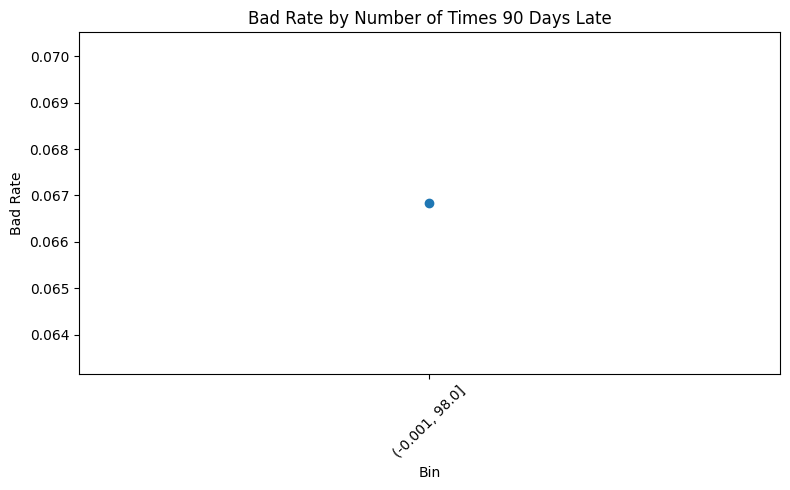

In [83]:
stats = initial_bin_stats[
    "NumberOfTimes90DaysLate"
].copy()

plot_stats = stats[
    stats["Bin"].astype(str) != "Missing"
]

plt.figure(figsize=(8, 5))

plt.plot(
    range(len(plot_stats)),
    plot_stats["Bad_Rate"],
    marker="o"
)

plt.title(
    "Bad Rate by Number of Times 90 Days Late"
)

plt.xlabel("Bin")
plt.ylabel("Bad Rate")

plt.xticks(
    range(len(plot_stats)),
    plot_stats["Bin"].astype(str),
    rotation=45
)

plt.tight_layout()
plt.show()

In [84]:
small_bin_review = []

for col in X_train.columns:
    
    stats = initial_bin_stats[col].copy()
    
    stats["Variable"] = col
    
    stats["Bin_Pct"] = (
        stats["Total_Count"]
        / stats["Total_Count"].sum()
    )
    
    small_bin_review.append(
        stats[
            [
                "Variable",
                "Bin",
                "Total_Count",
                "Bin_Pct",
                "Bad_Rate"
            ]
        ]
    )

small_bin_review = pd.concat(
    small_bin_review,
    ignore_index=True
)

display(
    small_bin_review
    .sort_values("Bin_Pct")
    .head(20)
)

,Variable,Bin,Total_Count,Bin_Pct,Bad_Rate
61,NumberOfDependents,Missing,2721,0.025914,0.041529
21,NumberOfTime30-59DaysPastDueNotWorse,"(1.0, 98.0]",5570,0.053048,0.322801
49,NumberOfOpenCreditLinesAndLoans,"(9.0, 10.0]",6771,0.064486,0.060405
56,NumberRealEstateLoansOrLines,"(2.0, 54.0]",6970,0.066381,0.086657
48,NumberOfOpenCreditLinesAndLoans,"(8.0, 9.0]",7908,0.075314,0.058928
34,MonthlyIncome,"(3000.0, 3800.0]",7919,0.075419,0.090668
44,NumberOfOpenCreditLinesAndLoans,"(3.0, 4.0]",8102,0.077162,0.064675
39,MonthlyIncome,"(7500.0, 9061.0]",8158,0.077695,0.051483
35,MonthlyIncome,"(3800.0, 4516.4]",8160,0.077714,0.081373
41,MonthlyIncome,"(11600.0, 1794060.0]",8413,0.080124,0.045525


In [86]:
display(monotonicity_df)
display(variable_bin_summary)

,Variable,Bad_Rate_Pattern
0,RevolvingUtilizationOfUnsecuredLines,Non-Monotonic
1,age,Decreasing
2,NumberOfTime30-59DaysPastDueNotWorse,Increasing
3,DebtRatio,Non-Monotonic
4,MonthlyIncome,Non-Monotonic
5,NumberOfOpenCreditLinesAndLoans,Non-Monotonic
6,NumberOfTimes90DaysLate,Increasing
7,NumberRealEstateLoansOrLines,Non-Monotonic
8,NumberOfTime60-89DaysPastDueNotWorse,Increasing
9,NumberOfDependents,Increasing


,Variable,Number_of_Bins,Minimum_Bin_Pct,Minimum_Bad_Rate,Maximum_Bad_Rate,Bad_Rate_Range,Monotonicity
0,RevolvingUtilizationOfUnsecuredLines,10,0.100000,0.014095,0.232476,0.218381,Non-Monotonic
1,age,10,0.089286,0.022236,0.111362,0.089127,Decreasing
2,NumberOfTime30-59DaysPastDueNotWorse,2,0.053048,0.052499,0.322801,0.270301,Increasing
3,DebtRatio,10,0.099971,0.048776,0.115238,0.066462,Non-Monotonic
4,MonthlyIncome,11,0.075419,0.045525,0.097454,0.051930,Non-Monotonic
5,NumberOfOpenCreditLinesAndLoans,10,0.064486,0.052845,0.107682,0.054838,Non-Monotonic
6,NumberOfTimes90DaysLate,1,1.000000,0.066838,0.066838,0.000000,Increasing
7,NumberRealEstateLoansOrLines,3,0.066381,0.056093,0.086657,0.030564,Non-Monotonic
8,NumberOfTime60-89DaysPastDueNotWorse,1,1.000000,0.066838,0.066838,0.000000,Increasing
9,NumberOfDependents,4,0.025914,0.041529,0.091609,0.050080,Increasing


## WOE & IV

In [87]:
def calculate_woe_iv(bin_stats, epsilon=1e-6):
    
    result = bin_stats.copy()
    
    # --------------------------------------------------------
    # Avoid zero distributions
    # --------------------------------------------------------
    
    good_dist = result["Good_Dist"].clip(lower=epsilon)
    bad_dist = result["Bad_Dist"].clip(lower=epsilon)
    
    # --------------------------------------------------------
    # Calculate WOE
    # --------------------------------------------------------
    
    result["WOE"] = np.log(
        good_dist / bad_dist
    )
    
    # --------------------------------------------------------
    # Calculate IV contribution
    # --------------------------------------------------------
    
    result["IV_Contribution"] = (
        (good_dist - bad_dist)
        * result["WOE"]
    )
    
    # --------------------------------------------------------
    # Total IV
    # --------------------------------------------------------
    
    total_iv = result["IV_Contribution"].sum()
    
    return result, total_iv

In [88]:
age_woe, age_iv = calculate_woe_iv(
    initial_bin_stats["age"]
)

display(age_woe)

,Bin,Total_Count,Good_Count,Bad_Count,Bad_Rate,Good_Dist,Bad_Dist,WOE,IV_Contribution
0,"(20.999, 33.0]",11943,10613,1330,0.111362,0.108316,0.189513,-0.559405,0.045422
1,"(33.0, 39.0]",10435,9437,998,0.095640,0.096314,0.142206,-0.389665,0.017883
2,"(39.0, 44.0]",11080,10142,938,0.084657,0.103509,0.133656,-0.255615,0.007706
3,"(44.0, 48.0]",10354,9513,841,0.081225,0.097089,0.119835,-0.210483,0.004788
4,"(48.0, 52.0]",10349,9549,800,0.077302,0.097457,0.113993,-0.156726,0.002592
5,"(52.0, 56.0]",9996,9342,654,0.065426,0.095344,0.093189,0.022863,0.000049
6,"(56.0, 60.0]",9375,8895,480,0.051200,0.090782,0.068396,0.283153,0.006339
7,"(60.0, 65.0]",11576,11092,484,0.041811,0.113204,0.068966,0.495589,0.021924
8,"(65.0, 72.0]",9908,9637,271,0.027352,0.098355,0.038615,0.934941,0.055853
9,"(72.0, 109.0]",9984,9762,222,0.022236,0.099631,0.031633,1.147270,0.078012


In [89]:
# first_bin = age_woe.iloc[0]

# print("Good Distribution:", first_bin["Good_Dist"])
# print("Bad Distribution:", first_bin["Bad_Dist"])
# print("WOE:", first_bin["WOE"])
# print("IV Contribution:", first_bin["IV_Contribution"])

Good Distribution: 0.10831581310853014
Bad Distribution: 0.18951268167569107
WOE: -0.5594047886241003
IV Contribution: 0.045421917097751514


In [90]:
# manual_woe = np.log(
#     first_bin["Good_Dist"] /
#     first_bin["Bad_Dist"]
# )

# manual_iv = (
#     first_bin["Good_Dist"] -
#     first_bin["Bad_Dist"]
# ) * manual_woe

# print("Manual WOE:", manual_woe)
# print("Manual IV:", manual_iv)

Manual WOE: -0.5594047886241003
Manual IV: 0.045421917097751514


In [91]:
woe_tables = {}
iv_results = []

for col in X_train.columns:
    
    woe_table, total_iv = calculate_woe_iv(
        initial_bin_stats[col]
    )
    
    woe_tables[col] = woe_table
    
    iv_results.append({
        "Variable": col,
        "IV": total_iv
    })

In [92]:
def iv_category(iv):
    
    if iv < 0.02:
        return "Very Weak"
    
    elif iv < 0.10:
        return "Weak"
    
    elif iv < 0.30:
        return "Medium"
    
    elif iv < 0.50:
        return "Strong"
    
    else:
        return "Very Strong"

In [95]:
display(
    iv_results_df.head(10)
)

NameError: name 'iv_results_df' is not defined